# Hypergraph Models (Chapter 2)
---
## Jason LaRuez, Brendan Rooney


This notebook and the accompanying python library contain the code for generating hypergraphs, processing data, loading data, and plotting results for Chapter 2 from the dissertation "Topological Tools for the Analysis of Complex Networks and Higher-Order Networks", and by extension the paper "Preferential Attachment as a Simpliciality-Enforcing Mechanism"

Disclaimer: much of code used for the final plots was created using generative AI

---
# Loading/installing relevant packages
---

In [1]:
# For use with google colab
#from google.colab import drive
#drive.mount('/content/drive', force_remount = True)
#sys.path.append('/content/drive/MyDrive/Colab Notebooks')

!pip install rbloom
from rbloom import Bloom

!pip install xgi
import xgi

!pip install dionysus==2.0.10
import dionysus as d
import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy import stats
from scipy.special import gammaln
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt # Plotting
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import os # Helpful functions, mainly for checking if a file exists

import collections # Used for obtaining degree distribution
import math
import sys
import bisect
from collections import defaultdict
from array import array
import matplotlib.patches as mpatches

from HypergraphModels import *

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         13,
    'axes.labelsize':    14,
    'axes.titlesize':    14,
    'legend.fontsize':   13,
    'xtick.labelsize':   12,
    'ytick.labelsize':   12,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'xtick.direction':   'in',
    'ytick.direction':   'in',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.linewidth':    0.4,
    'grid.alpha':        0.5,
    'grid.color':        '#aaaaaa',
    'figure.dpi':        150,
})

Mounted at /content/drive


---
# Generative Hypergraph Models: Data generation
---

## Erdos-Renyi hypergraphs

We consider two hypergraph generalizations: (i) a $K$-uniform model containing only hyperedges of fixed size $K$, and (ii) a nonuniform model in which hyperedges of all sizes $2 \leq k \leq K$ are included. In the $K$-uniform model, which is known to exhibit phase transitions analogous to those of the classical ER model, each of the $\binom{N}{K}$ possible hyperedges of size $K$ is included in the hypergraph independently with probability $p$. However, the $K$-uniform model restricts all interactions to a single fixed size, which oversimplifies the diversity of interaction sizes observed in real higher-order systems and limits the range of topological structures that can emerge. In the nonuniform model, each of the $\binom{N}{k}$ possible hyperedges of size $k$ is included independently with the same probability $p$, for every $2 \leq k \leq K$.

---

## Parallel Erdos-Renyi

In [ ]:
N = [5,10,15,20,25,30,35]; K = [3,4,5]; P = [1]; iterations = list(range(1,11)); models = ['kunif','regular']
params = [N, K, P, iterations, models]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_ErdosRenyi)(param) for param in tqdm(params))

---
## Watts-Strogatz hypergraphs

We construct a $K$-uniform ring lattice by grouping each set of $K$ neighboring vertices into hyperedges of size $K$: for $K=3$, for example, the ring consists of hyperedges $\{v_1,v_2,v_3\}$, $\{v_2,v_3,v_4\}$, $\ldots$, $\{v_N,v_1,v_2\}$. Rewiring is then performed by selecting one vertex from each hyperedge to keep and replacing the remaining $K-1$ vertices with randomly selected vertices.
---

## Parallel Watts-Strogatz

In [ ]:
N = [1000]; K = [3,4,5,6,7]; iterations = list(range(1,11)); models = ['kunif']
params = [N, K, iterations, models]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_WattsStrogatz)(param) for param in tqdm(params))

---
## Simplicial Watts-Strogatz

For a given hyperedge size parameter $K$, we begin by constructing the $K$-uniform ring lattice described above. We then include each proper subset of each maximal hyperedge independently with probability $p_{\mathrm{sub}}$, which controls the simpliciality of the initial lattice in the sense of the simpliciality measures discussed in Section 2.2.3: at $p_{\mathrm{sub}} = 0$ the initial hypergraph is $K$-uniform, and at $p_{\mathrm{sub}} = 1$ every subset of every hyperedge is included, giving a simplicial ring complex. For intermediate values of $p_{\mathrm{sub}}$, the model interpolates between these extremes, generating hypergraphs with varying degrees of higher-order structure. Rewiring is then applied as before, with each hyperedge rewired with probability $q$.

---

## Parallel Simplicial Watts-Strogatz

In [ ]:
N = [500]; K = [3,4,5,6]; P = np.linspace(0,1,21); iterations = list(range(1,101));
params = [N, K, P, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_Simplicial_WattsStrogatz)(param) for param in tqdm(params))

---
## Barabasi-Albert hypergraphs

The natural generalization of the BA model to hypergraphs replaces pairwise edges with hyperedges of fixed size $K$. At each step, a single new node is added to the hypergraph along with a hyperedge of size $K$ containing the new node and $K-1$ pre-existing nodes selected preferentially according to their hyperdegrees. Letting $deg_H(u)$ denote the hyperdegree of node $u$ (the number of hyperedges containing $u$) the probability of selecting a pre-existing node $u$ for inclusion in the new hyperedge is proportional to:
\begin{equation}
    p(u) = \frac{deg_H(u)}{\sum_{v \in V} deg_H(v)}.
\end{equation}
AWe also consider a random attachment variant in which the $K-1$ pre-existing nodes are selected uniformly at random, and a nonlinear preferential attachment variant in which the attachment probability is proportional to $deg_H(u)^\alpha$, allowing us to interpolate between random ($\alpha = 0$) and preferential ($\alpha = 1$) attachment and to study the gelation transition for $\alpha > 1$.

---

## Parallel Barabasi-Albert

In [ ]:
N = [10000]; K = [3,4,5,6,7,8,9,10,15]; P = [0]; iterations = [1,2,3,4,5,6,7,8,9,10];
params = [N, K, P, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_BarabasiAlbert)(param) for param in tqdm(params))

## Parallel Nonlinear Preferential Attachment

In [ ]:
N = [10000]; K = [3,4,5,6,7,8,9,10]; alphas = np.linspace(0,2,41); iterations = [1,2,3,4,5,6,7,8,9,10];
params = [N, K, alphas, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_HG_NL_BarabasiAlbert)(param) for param in tqdm(params))

---
# Generative Hypergraph Models: Data loading & plotting
---

## Loading Erdos-Renyi hypergraph data

In [2]:
base_path = 'Hypergraphs/ErdosRenyi/'

N          = [10, 15, 20, 25, 30, 35]
K          = [3, 4, 5]
P          = [1]
iterations = list(range(1, 11))
models     = ['kunif', 'nonuniform']

KUNIF_FIELDS   = ['Betti', 'SimplexCounts', 'Euler', 'Upper_sum', 'Lower_sum', 'SF', 'FES']
REGULAR_FIELDS = ['Betti', 'SimplexCounts', 'EdgeCounts', 'Euler', 'Upper_sum', 'Lower_sum', 'SF', 'FES']

# Main data store:
# data[model][n][k][p][field] = list of arrays, one per iteration
# CycleRank and CycleRank_minus_Betti1 are derived and stored alongside raw fields
data = { model: { n: { k: { p: { field: [] for field in (
                        KUNIF_FIELDS + ['CycleRank', 'CycleRank_minus_Betti1']
                        if model == 'kunif'
                        else REGULAR_FIELDS + ['CycleRank', 'CycleRank_minus_Betti1']
                    )} for p in P} for k in K} for n in N} for model in models}

missing   = []
corrupted = []

for model, n, k, p in product(models, N, K, P):
    fields = KUNIF_FIELDS if model == 'kunif' else REGULAR_FIELDS

    for iteration in iterations:
        filename = get_filename_ER(n, k, p, iteration, model, base_path)
        result   = load_single_er(filename)

        if result is None:
            if not os.path.isfile(filename):
                missing.append(filename)
            else:
                corrupted.append(filename)
            # Append None to preserve iteration alignment for all fields
            for field in fields + ['CycleRank', 'CycleRank_minus_Betti1']:
                data[model][n][k][p][field].append(None)
            continue

        # Store raw fields
        for field, value in zip(fields, result):
            data[model][n][k][p][field].append(value)

        # Compute and store derived cycle rank quantities
        betti         = result[fields.index('Betti')]
        simplex_counts = result[fields.index('SimplexCounts')]

        if betti is not None and simplex_counts is not None:
            cycle_rank = cyclerank_1(betti, simplex_counts)
            cycle_rank_minus_b1 = cycle_rank - betti[1].astype(float)
        else:
            cycle_rank          = None
            cycle_rank_minus_b1 = None

        data[model][n][k][p]['CycleRank'].append(cycle_rank)
        data[model][n][k][p]['CycleRank_minus_Betti1'].append(cycle_rank_minus_b1)

# Summary
total    = len(list(product(models, N, K, P))) * len(iterations)
loaded   = total - len(missing) - len(corrupted)
print(f'Loaded:    {loaded}/{total}')
print(f'Missing:   {len(missing)}')
print(f'Corrupted: {len(corrupted)}')

Loaded:    355/360
Missing:   5
Corrupted: 0


## Plotting Erdos-Renyi

/tmp/ipykernel_42778/2865144906.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  n_cmap       = cm.get_cmap('plasma', n_n)
/tmp/ipykernel_42778/2865144906.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap       = cm.get_cmap('viridis', n_k)
/tmp/ipykernel_42778/2865144906.py:35: RuntimeWarning: invalid value encountered in divide
  b[1].astype(float) / sc_col(sc, 1), np.nan),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:44: RuntimeWarning: invalid value encountered in divide
  b[2].astype(float) / s

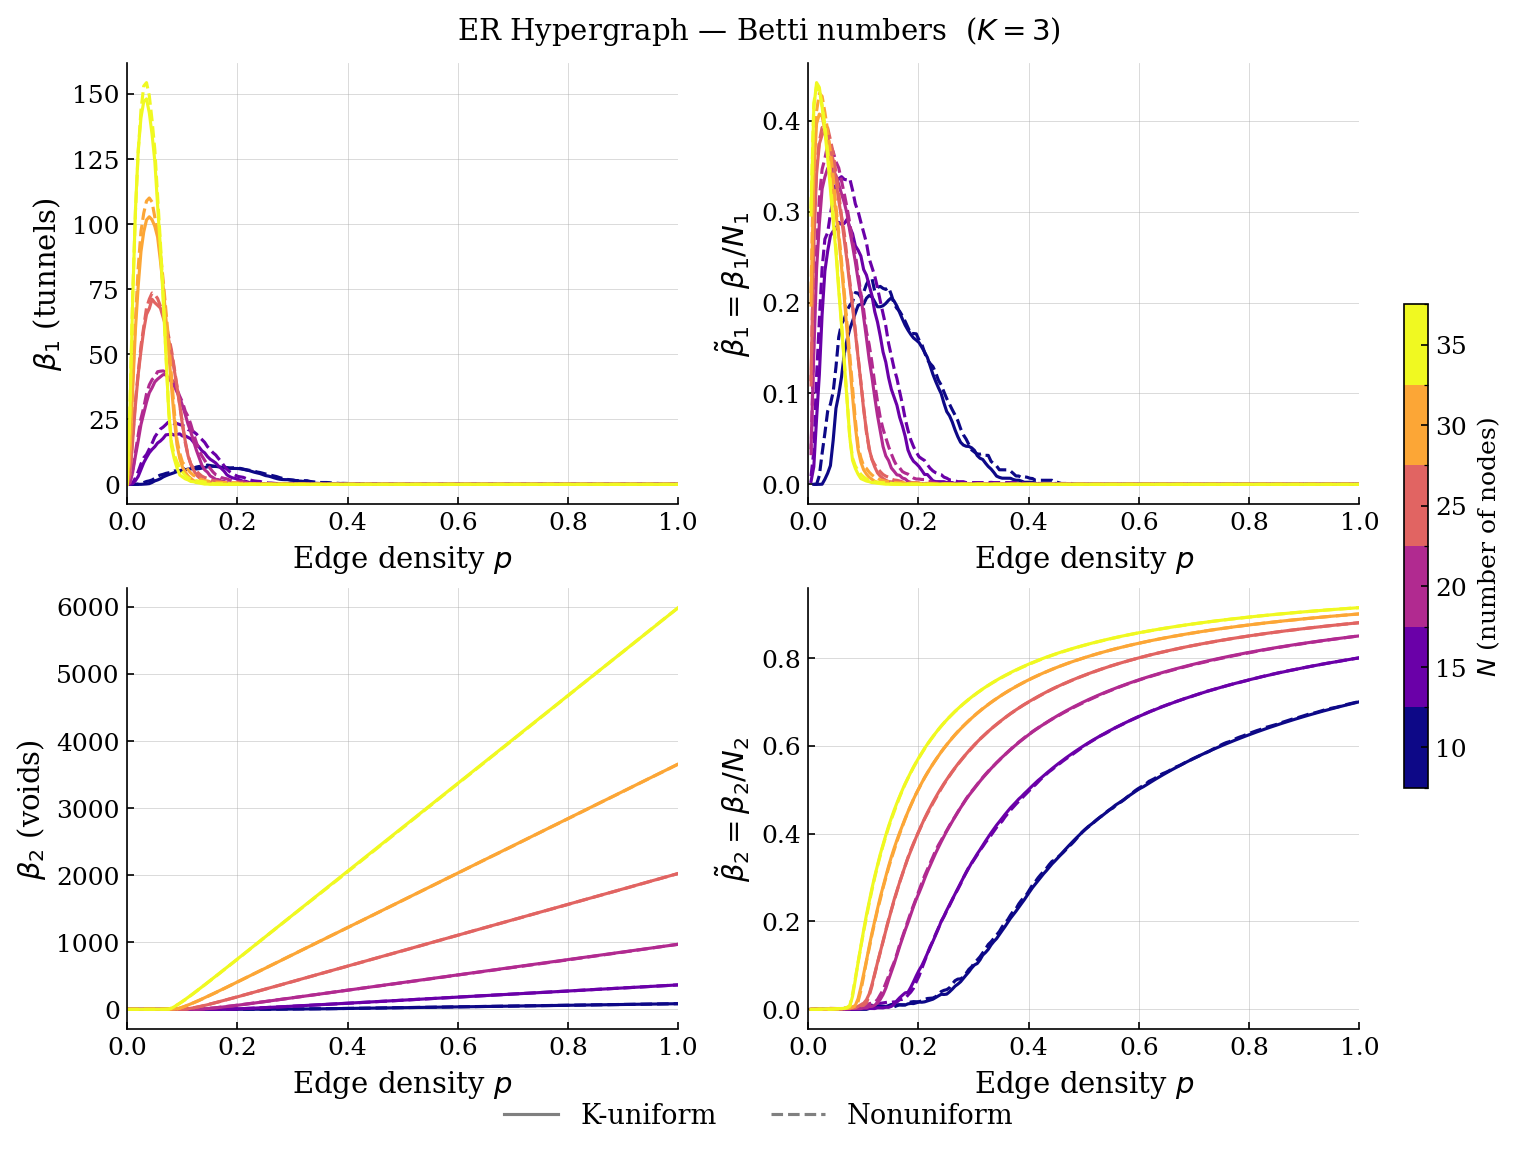

Saved: fig_ER_HG_betti_K3


/tmp/ipykernel_42778/2865144906.py:49: RuntimeWarning: invalid value encountered in divide
  np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:55: RuntimeWarning: invalid value encountered in divide
  np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0), np.nan)


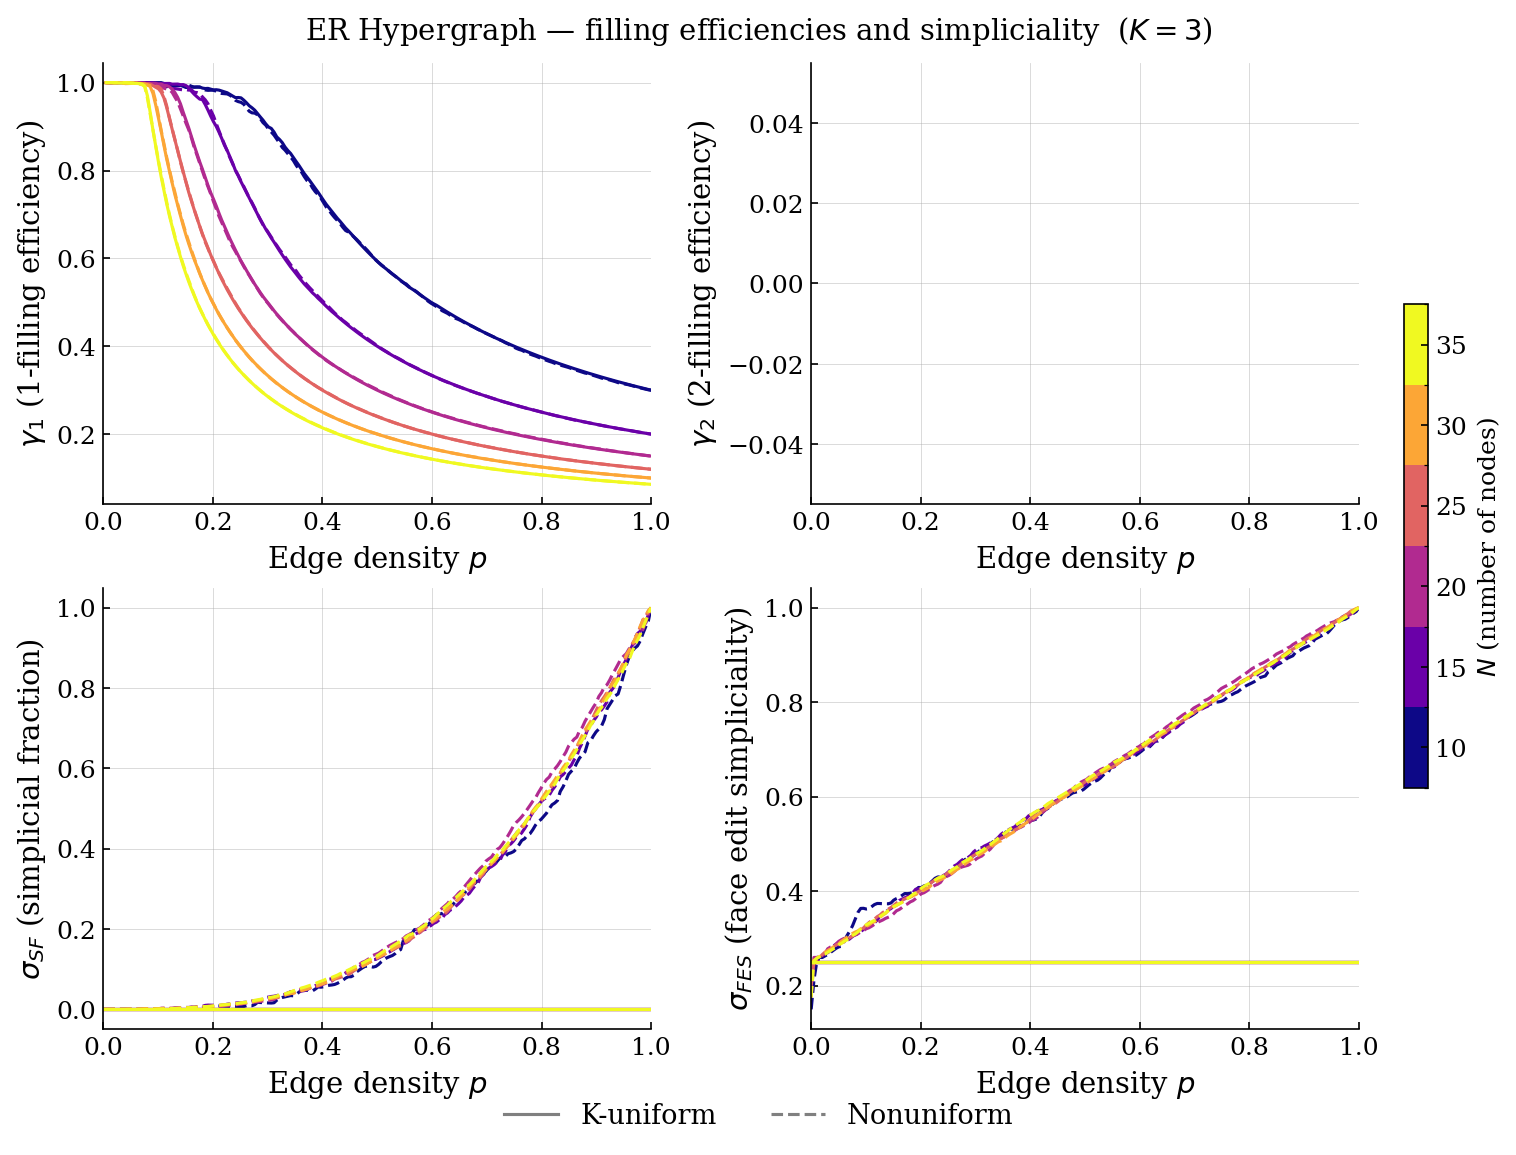

Saved: fig_ER_HG_gamma_simp_K3


/tmp/ipykernel_42778/2865144906.py:35: RuntimeWarning: invalid value encountered in divide
  b[1].astype(float) / sc_col(sc, 1), np.nan),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:44: RuntimeWarning: invalid value encountered in divide
  b[2].astype(float) / sc_col(sc, 2), np.nan),


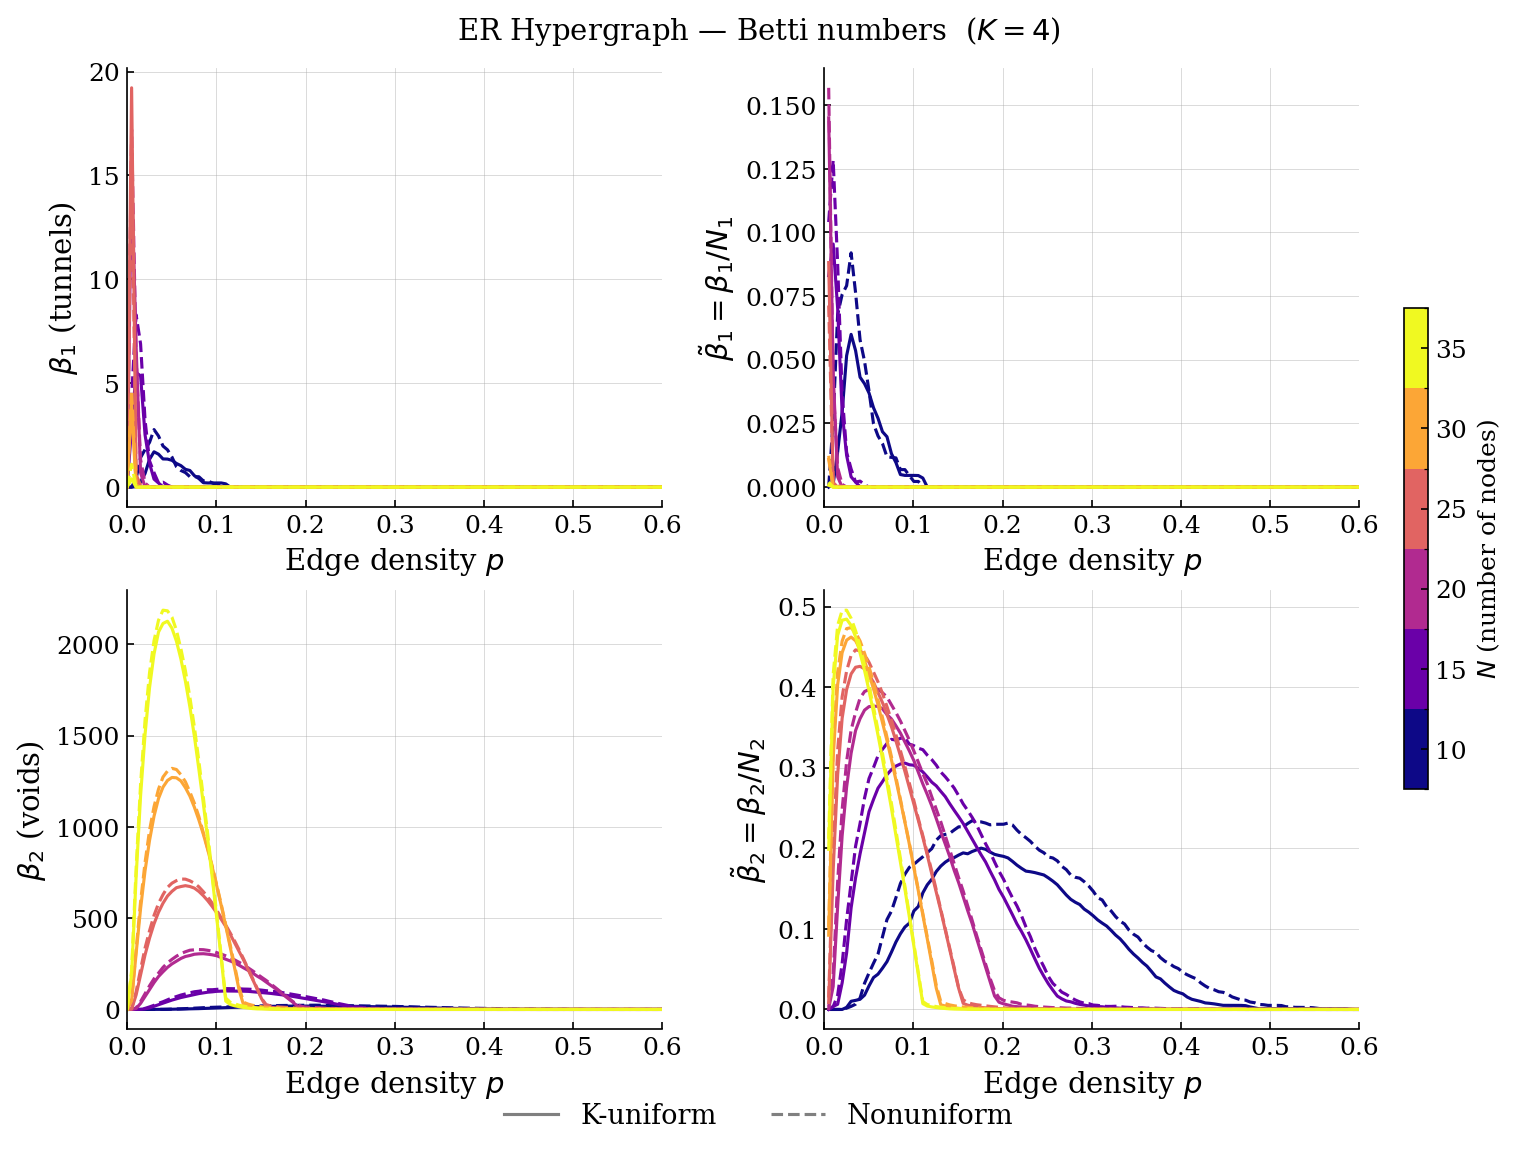

Saved: fig_ER_HG_betti_K4


/tmp/ipykernel_42778/2865144906.py:49: RuntimeWarning: invalid value encountered in divide
  np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:55: RuntimeWarning: invalid value encountered in divide
  np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0), np.nan)


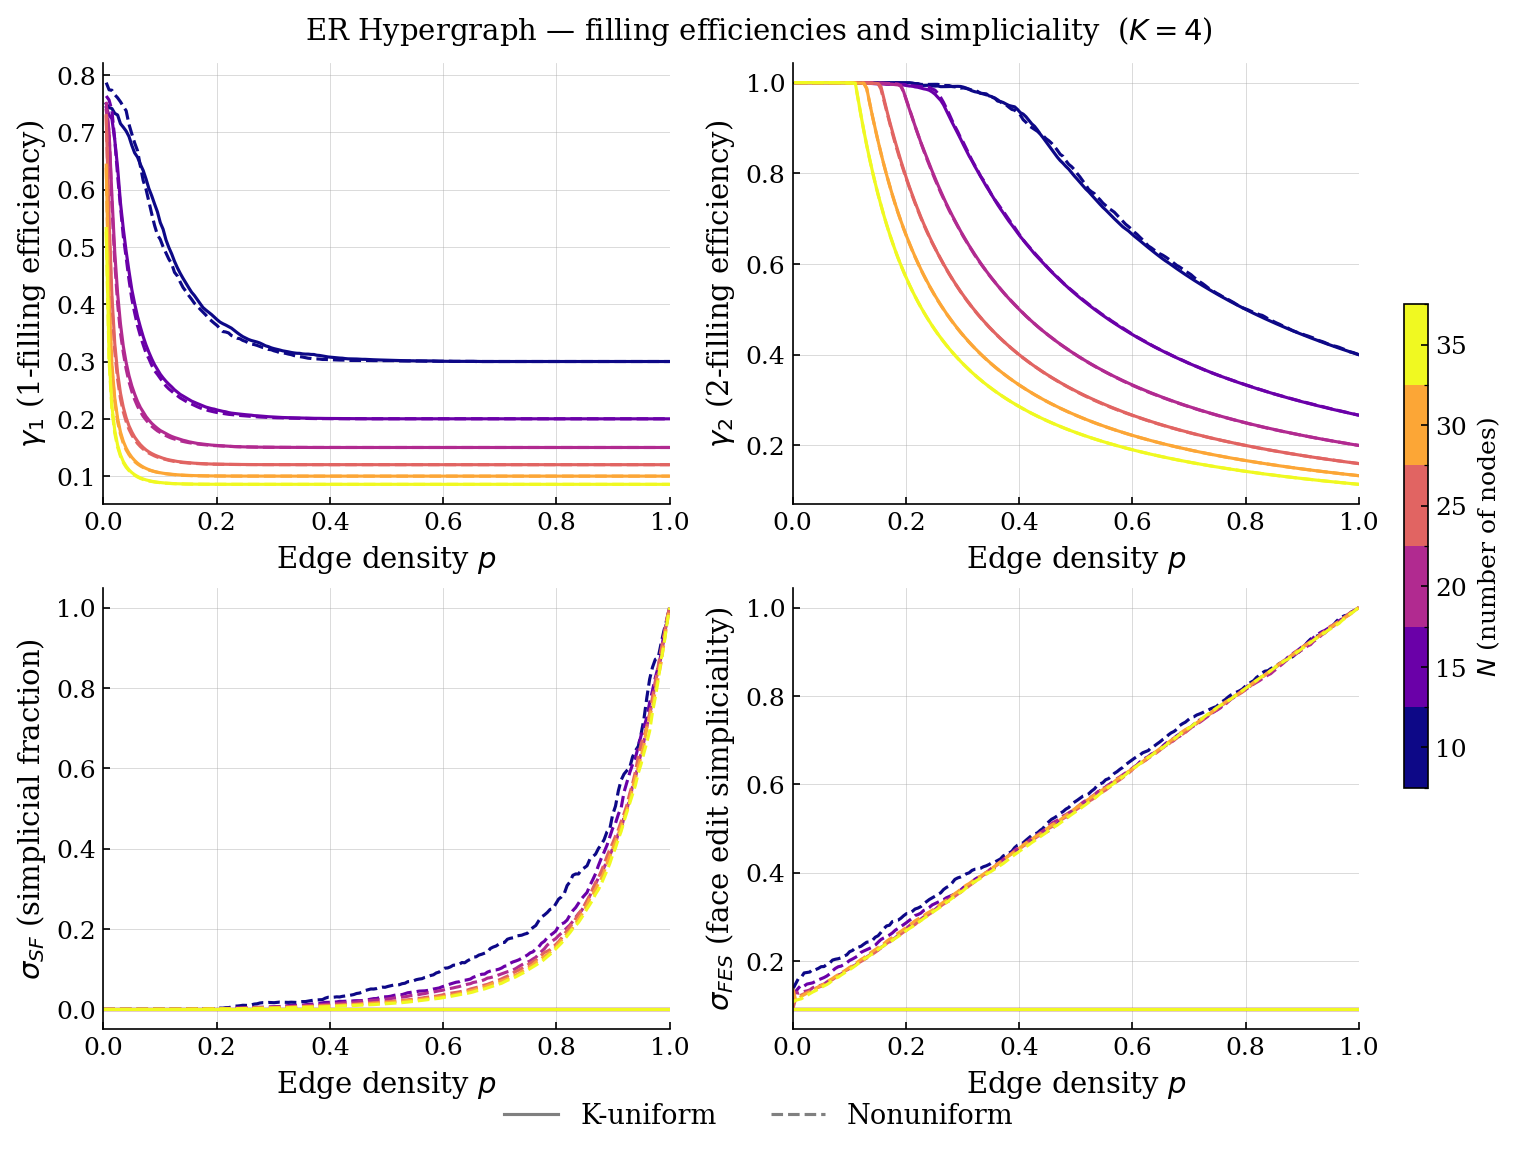

Saved: fig_ER_HG_gamma_simp_K4


/tmp/ipykernel_42778/2865144906.py:35: RuntimeWarning: invalid value encountered in divide
  b[1].astype(float) / sc_col(sc, 1), np.nan),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:44: RuntimeWarning: invalid value encountered in divide
  b[2].astype(float) / sc_col(sc, 2), np.nan),


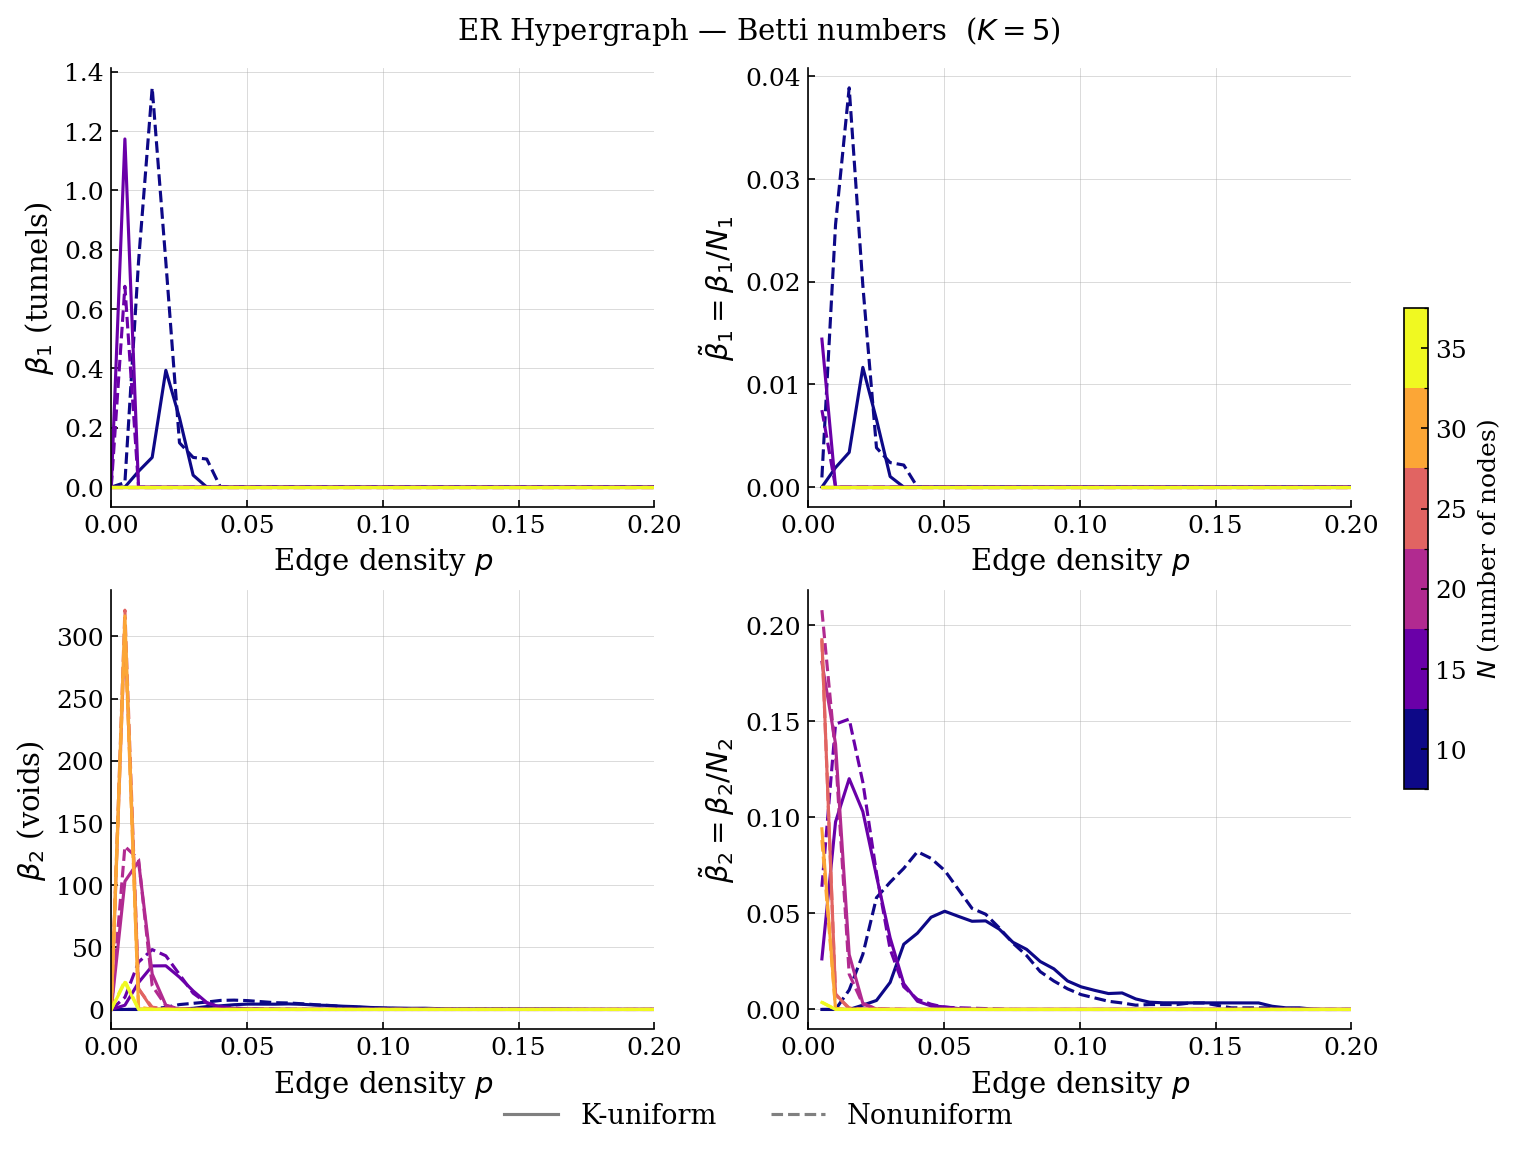

Saved: fig_ER_HG_betti_K5


/tmp/ipykernel_42778/2865144906.py:49: RuntimeWarning: invalid value encountered in divide
  np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:55: RuntimeWarning: invalid value encountered in divide
  np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0), np.nan)


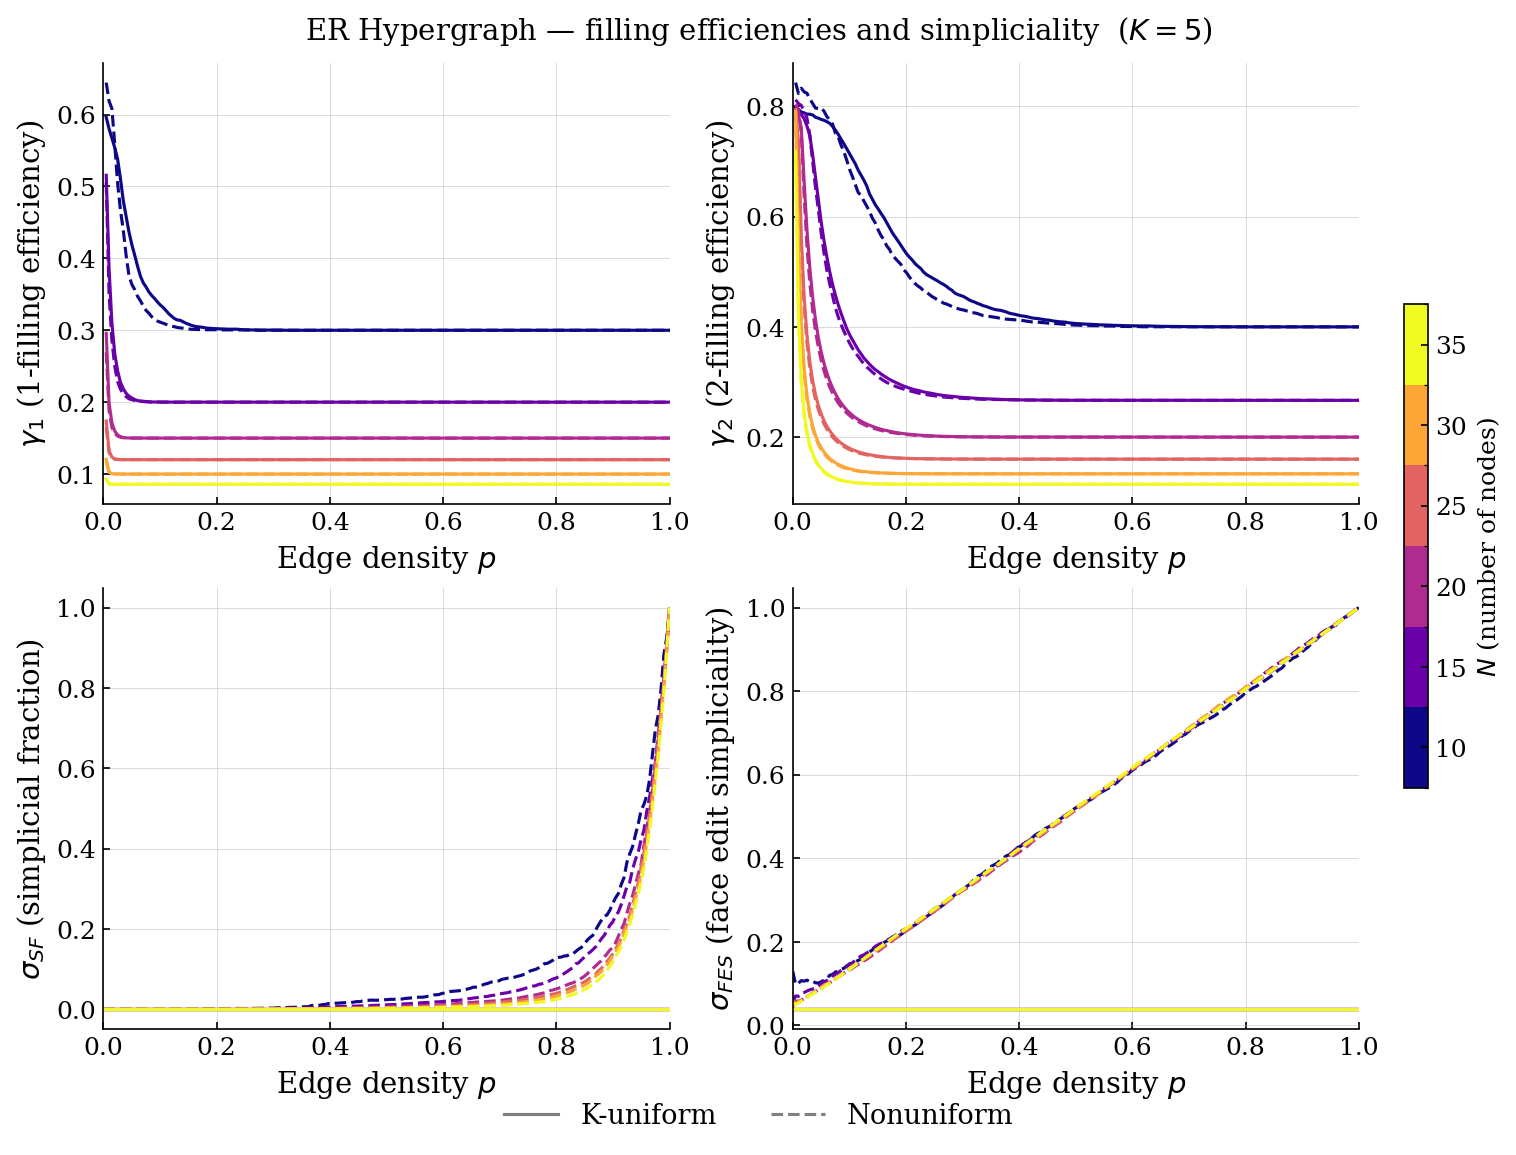

Saved: fig_ER_HG_gamma_simp_K5


/tmp/ipykernel_42778/2865144906.py:35: RuntimeWarning: invalid value encountered in divide
  b[1].astype(float) / sc_col(sc, 1), np.nan),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3158: RuntimeWarning: Mean of empty slice
  return np.nanmean(trajs, axis=0)
/tmp/ipykernel_42778/2865144906.py:44: RuntimeWarning: invalid value encountered in divide
  b[2].astype(float) / sc_col(sc, 2), np.nan),
/tmp/ipykernel_42778/2865144906.py:49: RuntimeWarning: invalid value encountered in divide
  np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
/tmp/ipykernel_42778/2865144906.py:55: RuntimeWarning: invalid value encountered in divide
  np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0), np.nan)


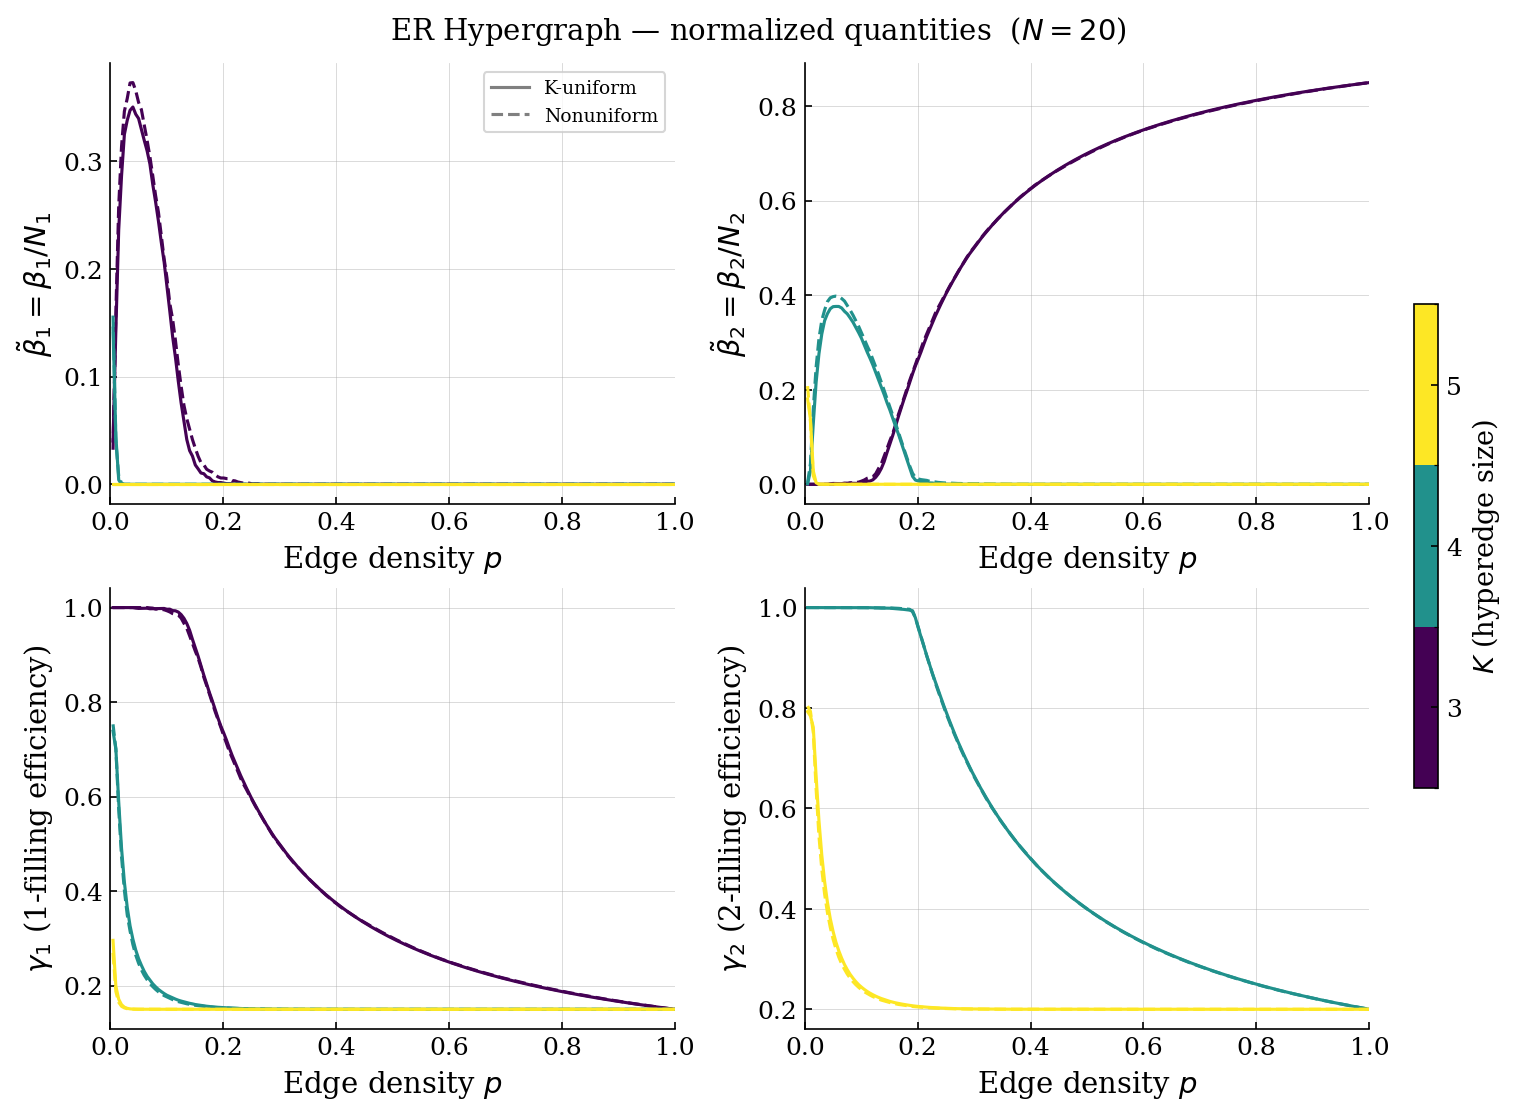

Saved: fig_ER_HG_collapse


In [3]:
p_ER     = 1
n_q       = 200
q_common  = np.linspace(0, 1, n_q)

# ── colormaps ─────────────────────────────────────────────────────────────────

# Discrete colormap over N
n_n          = len(N)
n_cmap       = cm.get_cmap('plasma', n_n)
n_colors     = {n: n_cmap(i) for i, n in enumerate(N)}
n_boundaries = np.arange(n_n + 1) - 0.5
n_norm       = mcolors.BoundaryNorm(n_boundaries, ncolors=n_n)

# Discrete colormap over K (for collapse figure)
n_k          = len(K)
k_cmap       = cm.get_cmap('viridis', n_k)
k_colors     = {k: k_cmap(i) for i, k in enumerate(K)}
k_boundaries = np.arange(n_k + 1) - 0.5
k_norm       = mcolors.BoundaryNorm(k_boundaries, ncolors=n_k)

# linestyles per model
model_ls = {'kunif': '-', 'nonuniform': '--'}

# ── field extractors: (betti, sc, cr, cr_b1, sf, fes) → 1-D array ────────────

fields_er = {
    r'$\beta_1$ (tunnels)':
        lambda b, sc, cr, cr_b1, sf, fes:
            b[1].astype(float),

    r'$\tilde{\beta}_1=\beta_1/N_1$':
        lambda b, sc, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 1) > 0,
                     b[1].astype(float) / sc_col(sc, 1), np.nan),

    r'$\beta_2$ (voids)':
        lambda b, sc, cr, cr_b1, sf, fes:
            b[2].astype(float),

    r'$\tilde{\beta}_2=\beta_2/N_2$':
        lambda b, sc, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 2) > 0,
                     b[2].astype(float) / sc_col(sc, 2), np.nan),

    r'$\gamma_1$ (1-filling efficiency)':
        lambda b, sc, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 2) > 0,
                     np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
                             0.0, 1.0), np.nan),

    r'$\gamma_2$ (2-filling efficiency)':
        lambda b, sc, cr, cr_b1, sf, fes: (
            lambda cr2b2: np.where(sc_col(sc, 3) > 0,
                                   np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0), np.nan)
        )(cyclerank_2(b, sc) - b[2].astype(float)),

    r'$\sigma_{SF}$ (simplicial fraction)':
        lambda b, sc, cr, cr_b1, sf, fes:
            np.asarray(sf, dtype=float),

    r'$\sigma_{FES}$ (face edit simpliciality)':
        lambda b, sc, cr, cr_b1, sf, fes:
            np.asarray(fes, dtype=float),
}

# ── per-K figures ─────────────────────────────────────────────────────────────

for k in K:
    # Figure 1: β1, β̃1 | β2, β̃2
    betti_xlim = (0, 0.6) if k == 4 else (0, 0.2) if k == 5 else (0, 1)
    draw_er_figure(
        data, base_path, N, k, fields_er, p_ER, q_common, n_colors, n_cmap, n_norm, n_n, model_ls,
        panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                       [r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$']],
        nrows=2, ncols=2, figsize=(10, 7),
        suptitle    = rf'ER Hypergraph — Betti numbers  ($K={k}$)',
        save_prefix = f'fig_ER_HG_betti_K{k}',
        xlim        = betti_xlim,
    )

    # Figure 2: γ1, γ2 | σ_SF, σ_FES
    draw_er_figure(
        data, base_path, N, k, fields_er, p_ER, q_common, n_colors, n_cmap, n_norm, n_n, model_ls,
        panels      = [[r'$\gamma_1$ (1-filling efficiency)',     r'$\gamma_2$ (2-filling efficiency)'],
                       [r'$\sigma_{SF}$ (simplicial fraction)',  r'$\sigma_{FES}$ (face edit simpliciality)']],
        nrows=2, ncols=2, figsize=(10, 7),
        suptitle    = rf'ER Hypergraph — filling efficiencies and simpliciality  ($K={k}$)',
        save_prefix = f'fig_ER_HG_gamma_simp_K{k}',
    )

# ── collapse figure: normalised quantities, colorbar=K, linestyle=model ───────
# One figure per normalised field to avoid overcrowding.

collapse_fields = [
    r'$\tilde{\beta}_1=\beta_1/N_1$',
    r'$\tilde{\beta}_2=\beta_2/N_2$',
    r'$\gamma_1$ (1-filling efficiency)',
    r'$\gamma_2$ (2-filling efficiency)',
]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes_flat = axes.flatten()

n_collapse = 20

for ax, label in zip(axes_flat, collapse_fields):
    field_fn = fields_er[label]
    for k in K:
        for model in models:
            mean = get_mean_trajectory_er(model, n_collapse, k, field_fn, data, p_ER, q_common)
            if mean is None:
                continue
            ax.plot(q_common, mean, color=k_colors[k],
                    ls=model_ls[model], lw=1.5)
    ax.set_ylabel(label)
    ax.set_xlabel(r'Edge density $p$')
    ax.set_xlim(0, 1)

add_discrete_cbar_k(fig, axes_flat, k_cmap, k_norm, n_k, K, shrink=0.5)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='grey', ls='-',  lw=1.5, label='K-uniform'),
    Line2D([0], [0], color='grey', ls='--', lw=1.5, label='Nonuniform'),
]
axes_flat[0].legend(handles=legend_elements, loc='best', fontsize=9)

fig.suptitle(rf'ER Hypergraph — normalized quantities  ($N={n_collapse}$)', fontsize=14, y=1.04)
fig.savefig(save_base + 'fig_ER_HG_collapse.pdf', dpi=300, bbox_inches='tight')
fig.savefig(save_base + 'fig_ER_HG_collapse.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_ER_HG_collapse')

## Loading Watts-Strogatz hypergraph data

In [4]:
base_path  = 'Hypergraphs/WattsStrogatz/'
N          = [500]
K          = [3, 4, 5, 6]
P          = np.linspace(0, 1, 21)
iterations = list(range(1, 101))
num_cores  = 8

WS_fields  = ['Betti', 'SimplexCounts', 'Euler', 'Upper_sum', 'Lower_sum', 'SF', 'FES']
all_fields = WS_fields + ['CycleRank', 'CycleRank_minus_Betti1']

# Build full parameter list
all_params = [
    (n, k, p, iteration)
    for n, k, p, iteration in product(N, K, P, iterations)
]

# Parallel load
results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_ws)(n, k, p, iteration, base_path, WS_fields)
    for n, k, p, iteration in tqdm(all_params, desc='Loading WS files')
)

# Initialise data structure
data = {
    n: {
        k: {
            round(p, 4): {field: [] for field in all_fields}
            for p in P
        }
        for k in K
    }
    for n in N
}

missing   = []
corrupted = []
loaded    = 0

for n, k, p_key, iteration, field_dict, status in results:
    if status == 'ok':
        for field in all_fields:
            data[n][k][p_key][field].append(field_dict[field])
        loaded += 1
    elif status == 'missing':
        missing.append((n, k, p_key, iteration))
        for field in all_fields:
            data[n][k][p_key][field].append(None)
    else:
        corrupted.append((n, k, p_key, iteration))
        print(f'  {status}: n={n}, k={k}, p={p_key}, iter={iteration}')
        for field in all_fields:
            data[n][k][p_key][field].append(None)

total = len(all_params)
print(f'Loaded:    {loaded}/{total}')
print(f'Missing:   {len(missing)}')
print(f'Corrupted: {len(corrupted)}')

Loading WS files:   0%|          | 0/8400 [00:00<?, ?it/s]

Loaded:    6754/8400
Missing:   1646
Corrupted: 0


## Plotting Watts-Strogatz

/tmp/ipykernel_42778/1688028746.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap       = cm.get_cmap('plasma', n_k)


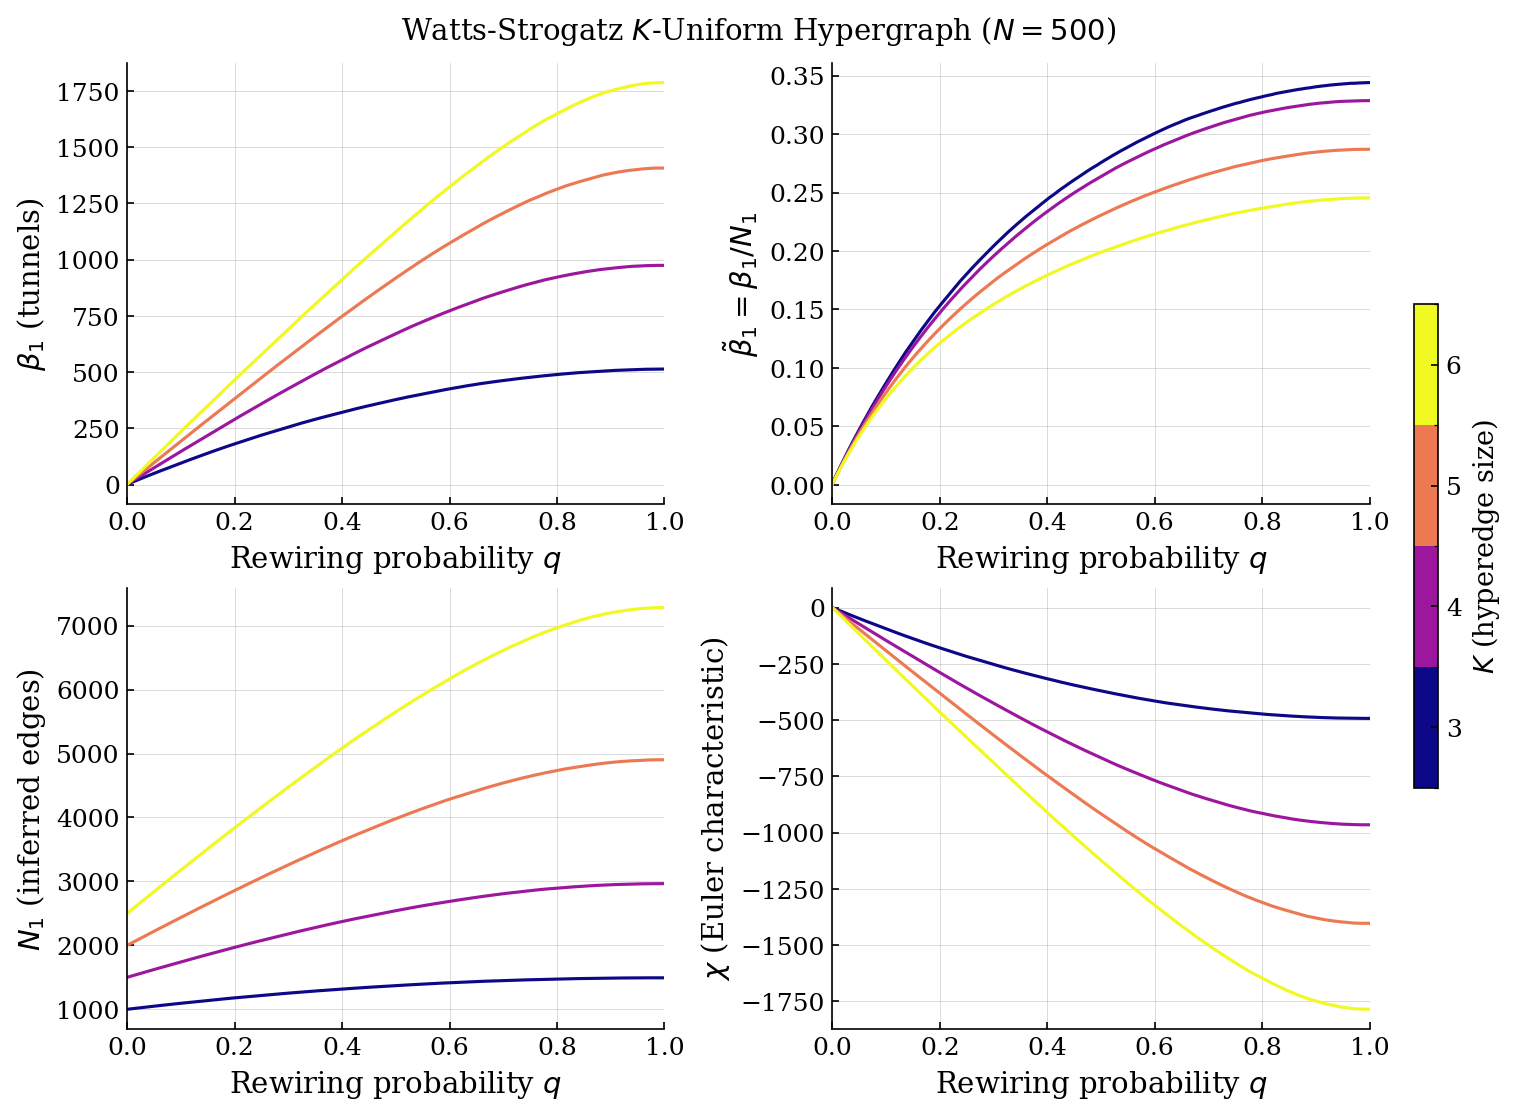

Saved: fig_WS_HG_betti


/tmp/ipykernel_42778/1688028746.py:58: RuntimeWarning: invalid value encountered in divide
  np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0),
/content/drive/MyDrive/Colab Notebooks/HypergraphModels.py:3236: RuntimeWarning: Mean of empty slice
  return q_common, np.nanmean(interp, axis=0)


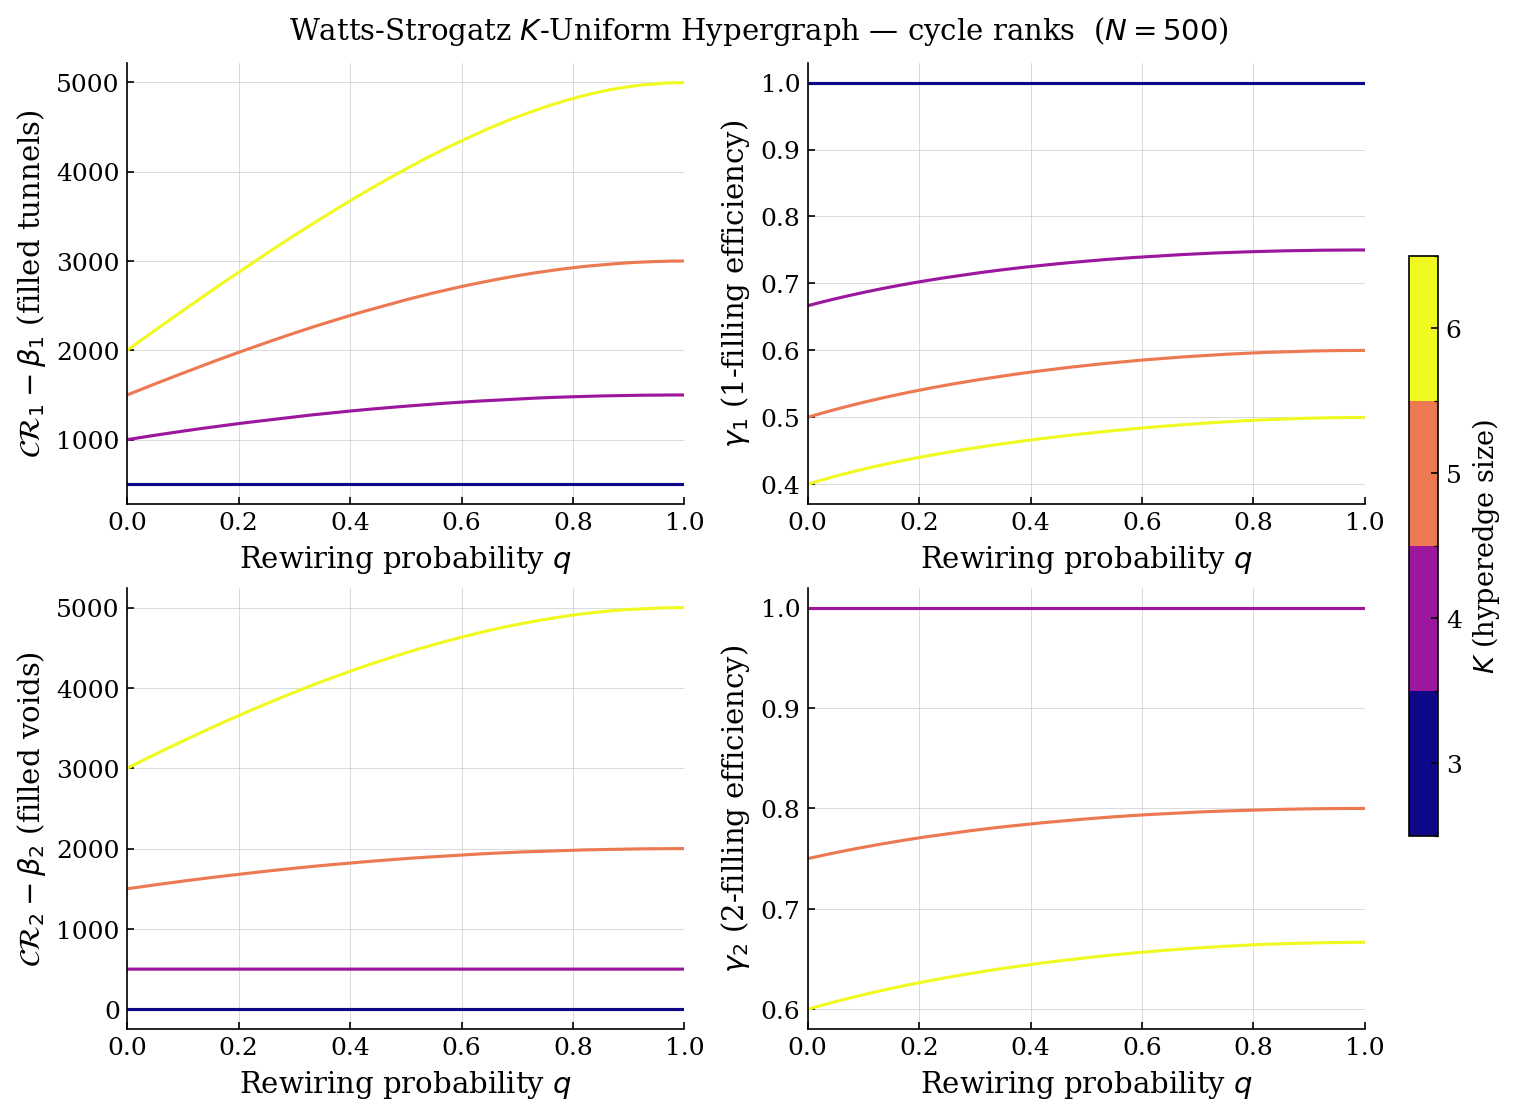

Saved: fig_WS_HG_cyclerank


In [5]:
n_plot    = 500

# ── discrete colormap over K ──────────────────────────────────────────────────

n_k          = len(K)
k_cmap       = cm.get_cmap('plasma', n_k)
k_colors     = {k: k_cmap(i) for i, k in enumerate(K)}
k_boundaries = np.arange(n_k + 1) - 0.5
k_norm       = mcolors.BoundaryNorm(k_boundaries, ncolors=n_k)

fields_ws = {
    r'$N_1$ (inferred edges)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            sc_col(sc, 1),

    r'$\chi$ (Euler characteristic)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.asarray(e, dtype=float),

    r'$\beta_1$ (tunnels)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            b[1].astype(float),

    r'$\tilde{\beta}_1=\beta_1/N_1$':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 1) > 0,
                     b[1].astype(float) / sc_col(sc, 1), np.nan),

    r'$\beta_2$ (voids)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            b[2].astype(float),

    r'$\tilde{\beta}_2=\beta_2/N_2$':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 2) > 0,
                     b[2].astype(float) / sc_col(sc, 2), np.nan),

    r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.asarray(cr_b1, dtype=float),

    r'$\gamma_1$ (1-filling efficiency)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.where(sc_col(sc, 2) > 0,
                     np.clip(np.asarray(cr_b1, dtype=float) / sc_col(sc, 2),
                             0.0, 1.0),
                     np.nan),

    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':
        lambda b, sc, e, cr, cr_b1, sf, fes: (
            lambda cr2: cr2 - b[2].astype(float)
        )(cyclerank_2(b, sc)),

    r'$\gamma_2$ (2-filling efficiency)':
        lambda b, sc, e, cr, cr_b1, sf, fes: (
            lambda cr2b2: np.where(sc_col(sc, 3) > 0,
                                   np.clip(cr2b2 / sc_col(sc, 3), 0.0, 1.0),
                                   np.nan)
        )(cyclerank_2(b, sc) - b[2].astype(float)),

    r'$\sigma_{SF}$ (simplicial fraction)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.asarray(sf, dtype=float),

    r'$\sigma_{FES}$ (face edit simpliciality)':
        lambda b, sc, e, cr, cr_b1, sf, fes:
            np.asarray(fes, dtype=float),
}

# ── Figure 1: b1, ~b1 | b2, ~b2 | N1, Euler ─────────────────────────────────

draw_ws_figure(
    data, base_path, n_plot, k, fields_ws, k_colors, k_cmap, k_norm, n_k, K,
    panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                   [r'$N_1$ (inferred edges)',      r'$\chi$ (Euler characteristic)']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = rf'Watts-Strogatz $K$-Uniform Hypergraph ($N={n_plot}$)',
    save_prefix = 'fig_WS_HG_betti',
)

# ── Figure 2: CR1-b1, gamma1 | CR2-b2, gamma2 ────────────────────────────────

draw_ws_figure(
    data, base_path, n_plot, k, fields_ws, k_colors, k_cmap, k_norm, n_k, K,
    panels      = [[r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',  r'$\gamma_1$ (1-filling efficiency)'],
                   [r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',  r'$\gamma_2$ (2-filling efficiency)']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = rf'Watts-Strogatz $K$-Uniform Hypergraph — cycle ranks  ($N={n_plot}$)',
    save_prefix = 'fig_WS_HG_cyclerank',
    cbar_shrink = 0.6,
)

## Plotting simplicial Watts-Strogatz

In [6]:
n_plot    = 500
p_keys    = sorted(data[n_plot][K[0]].keys())

# ── discrete colormap over p ──────────────────────────────────────────────────
n_p          = len(p_keys)
p_cmap       = cm.get_cmap('plasma', n_p)
p_colors     = {p: p_cmap(i) for i, p in enumerate(p_keys)}
p_boundaries = np.arange(n_p + 1) - 0.5
p_norm       = mcolors.BoundaryNorm(p_boundaries, ncolors=n_p)

# ── main loop over K ──────────────────────────────────────────────────────────
for k in K:
    # Figure 1: b1, ~b1 | b2, ~b2
    draw_simplicial_ws_figure(data, base_path, n_plot, k, fields_ws, p_cmap, p_norm, n_p, p_keys, p_colors,
        panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                       [r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$']],
        nrows=2, ncols=2, figsize=(10, 7),
        suptitle    = rf'Simplicial WS Hypergraph — Betti numbers  ($N={n_plot}$, $K={k}$)',
        save_prefix = f'fig_WS_HG_betti_K{k}',
    )

    # Figure 2: gamma1, gamma2 | SF, FES
    draw_simplicial_ws_figure(data, base_path, n_plot, k, fields_ws, p_cmap, p_norm, n_p, p_keys, p_colors,
        panels      = [[r'$\gamma_1$ (1-filling efficiency)',       r'$\gamma_2$ (2-filling efficiency)'],
                       [r'$\sigma_{SF}$ (simplicial fraction)',    r'$\sigma_{FES}$ (face edit simpliciality)']],
        nrows=2, ncols=2, figsize=(10, 7),
        suptitle    = rf'Simplicial WS Hypergraph — cycle ranks and simpliciality  ($N={n_plot}$, $K={k}$)',
        save_prefix = f'fig_WS_HG_gamma_simp_K{k}',
    )

Output hidden; open in https://colab.research.google.com to view.

## Plotting simplicial Watts-Strogatz heatmaps

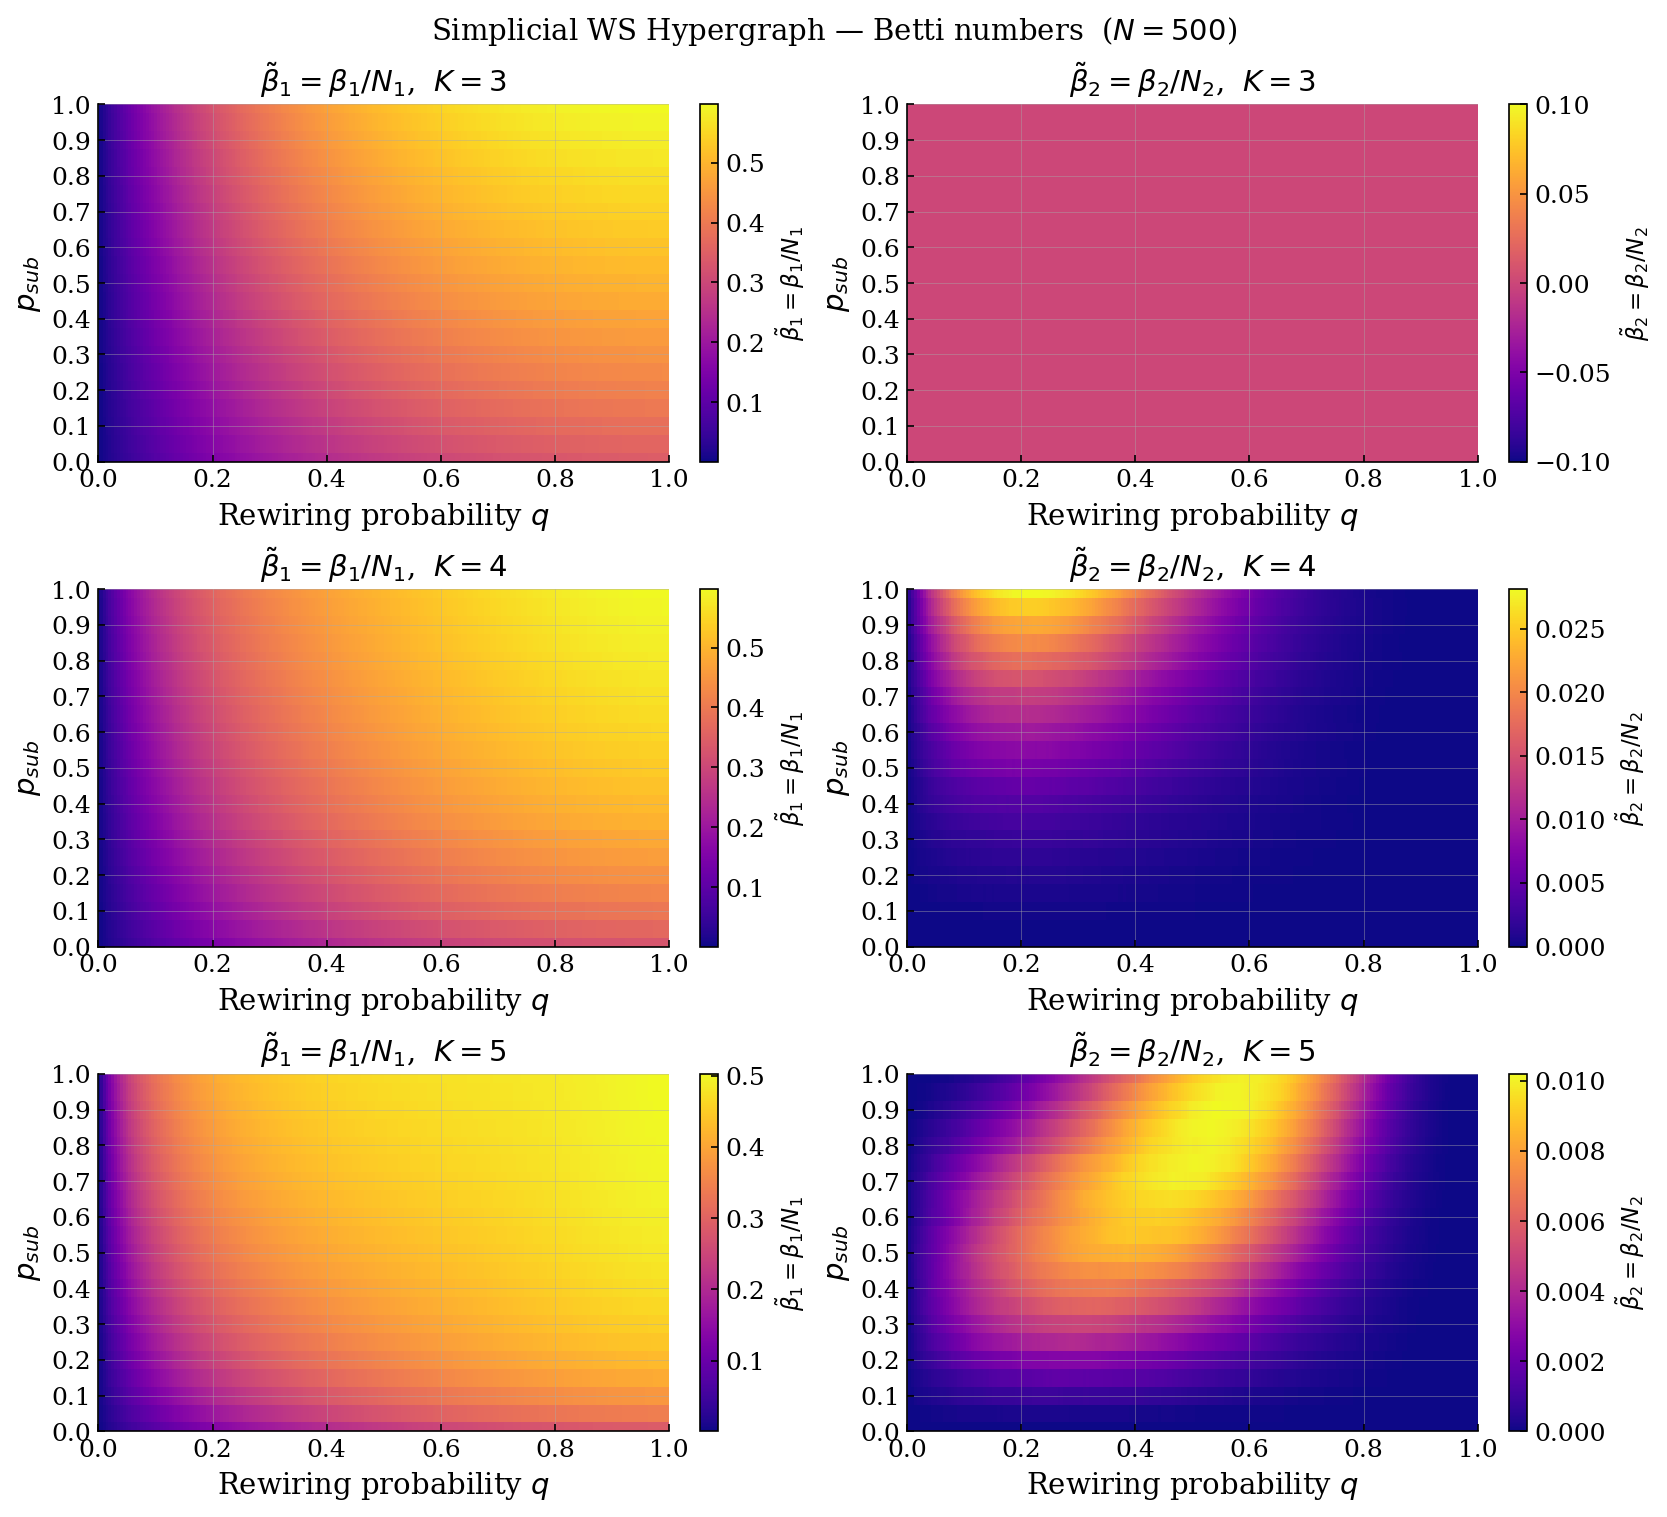

Saved: fig_WS_HG_heatmap_tildebetti


In [7]:
n_plot    = 500
p_keys    = sorted(data[n_plot][K[0]].keys())
K_plot    = [3, 4, 5]           # rows
n_q       = 200                 # resolution of common q grid
q_common  = np.linspace(0, 1, n_q)

# ── figure ────────────────────────────────────────────────────────────────────

fields    = [(tb1, r'$\tilde{\beta}_1=\beta_1/N_1$'),
             (tb2, r'$\tilde{\beta}_2=\beta_2/N_2$')]
p_arr     = np.array(p_keys)

fig, axes = plt.subplots(3, 2, figsize=(11, 10), constrained_layout=True)

for row, k in enumerate(K_plot):
    for col, (field_fn, label) in enumerate(fields):
        ax  = axes[row, col]
        mat = build_heatmap(data, n_plot, n_q, k, q_common, field_fn, p_keys)

        # vmin/vmax from data, ignoring nan
        vmin = np.nanmin(mat)
        vmax = np.nanmax(mat)

        im = ax.pcolormesh(
            q_common, p_arr, mat,
            cmap='plasma', shading='auto',
            vmin=vmin, vmax=vmax,
        )

        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label(label, fontsize=11)

        ax.set_xlabel(r'Rewiring probability $q$')
        ax.set_ylabel(r'$p_{sub}$')
        ax.set_title(rf'{label},  $K={k}$')
        ax.set_xlim(0, 1)
        ax.set_ylim(p_arr[0], p_arr[-1])
        ax.set_yticks(p_arr[::2])
        ax.set_yticklabels([f'{p:.1f}' for p in p_arr[::2]])

fig.suptitle(rf'Simplicial WS Hypergraph — Betti numbers  ($N={n_plot}$)',
             fontsize=14)
fig.savefig(base_path + 'fig_WS_HG_heatmap_tildebetti.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(base_path + 'fig_WS_HG_heatmap_tildebetti.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_WS_HG_heatmap_tildebetti')

## Loading Barabasi-Albert/Nonlinear preferential attachment hypergraph data

In [8]:
base_path  = 'Hypergraphs/BarabasiAlbert/'
N          = [10000]
K          = [3, 4, 5, 6, 7, 8, 9, 10]
alphas     = np.linspace(0, 2, 41)
iterations = list(range(1, 11))
num_cores  = 8

NLBA_fields = ['D', 'Betti', 'SimplexCounts', 'Euler']

# Build full parameter list
all_params = [
    (n, k, alpha, iteration)
    for n, k, alpha, iteration in product(N, K, alphas, iterations)
]

# Parallel load
results = Parallel(n_jobs=num_cores, backend='loky')(
    delayed(load_single_nlba)(n, k, alpha, iteration, base_path, NLBA_fields)
    for n, k, alpha, iteration in tqdm(all_params, desc='Loading NL-BA files')
)

# Initialise data structure
all_fields = NLBA_fields + ['CycleRank', 'CycleRank_minus_Betti1']

data = {
    n: { k: { round(alpha, 4): {field: [] for field in all_fields}
            for alpha in alphas } for k in K } for n in N }

missing   = []
corrupted = []
loaded    = 0

for n, k, alpha_key, iteration, field_dict, status in results:
    if status == 'ok':
        for field in all_fields:
            data[n][k][alpha_key][field].append(field_dict[field])
        loaded += 1
    elif status == 'missing':
        missing.append((n, k, alpha_key, iteration))
        for field in all_fields:
            data[n][k][alpha_key][field].append(None)
    else:
        corrupted.append((n, k, alpha_key, iteration))
        print(f'  {status}: n={n}, k={k}, alpha={alpha_key}, iter={iteration}')
        for field in all_fields:
            data[n][k][alpha_key][field].append(None)

total = len(all_params)
print(f'Loaded:    {loaded}/{total}')
print(f'Missing:   {len(missing)}')
print(f'Corrupted: {len(corrupted)}')

Loading NL-BA files:   0%|          | 0/3280 [00:00<?, ?it/s]

Loaded:    3280/3280
Missing:   0
Corrupted: 0


## Plotting NLPA

/tmp/ipykernel_42778/2806180683.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_cmap     = cm.get_cmap('plasma', n_k)


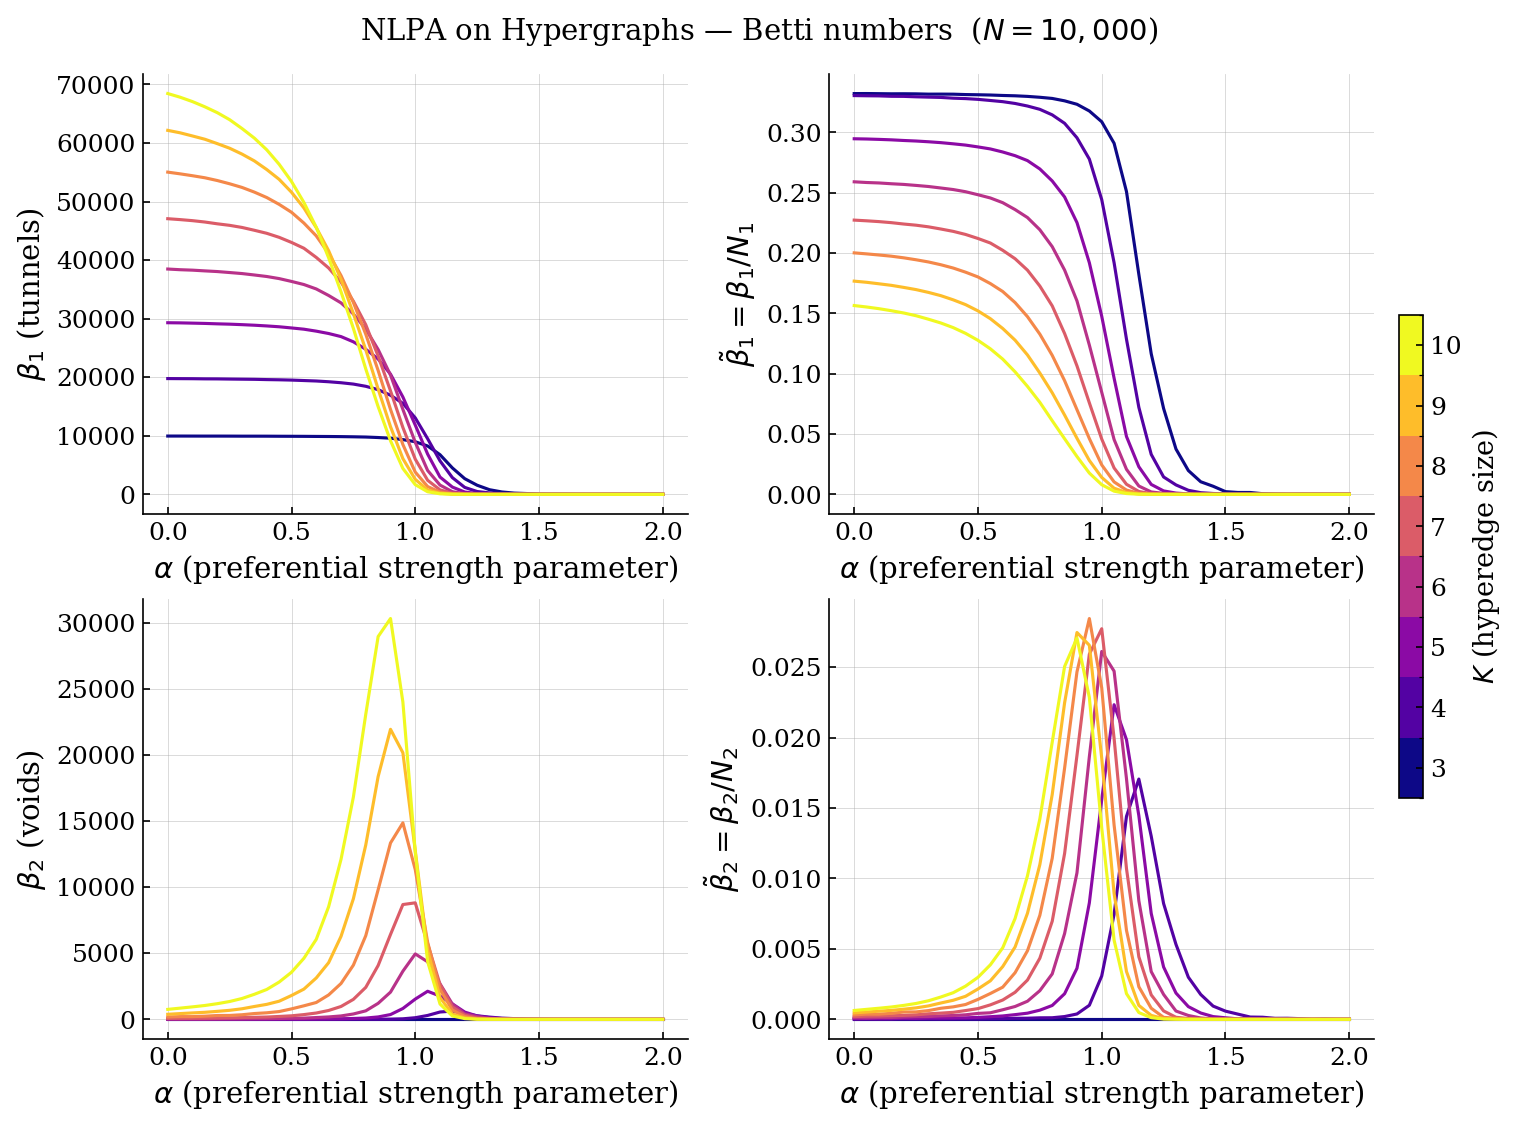

Saved: fig_NLBA_HG_betti


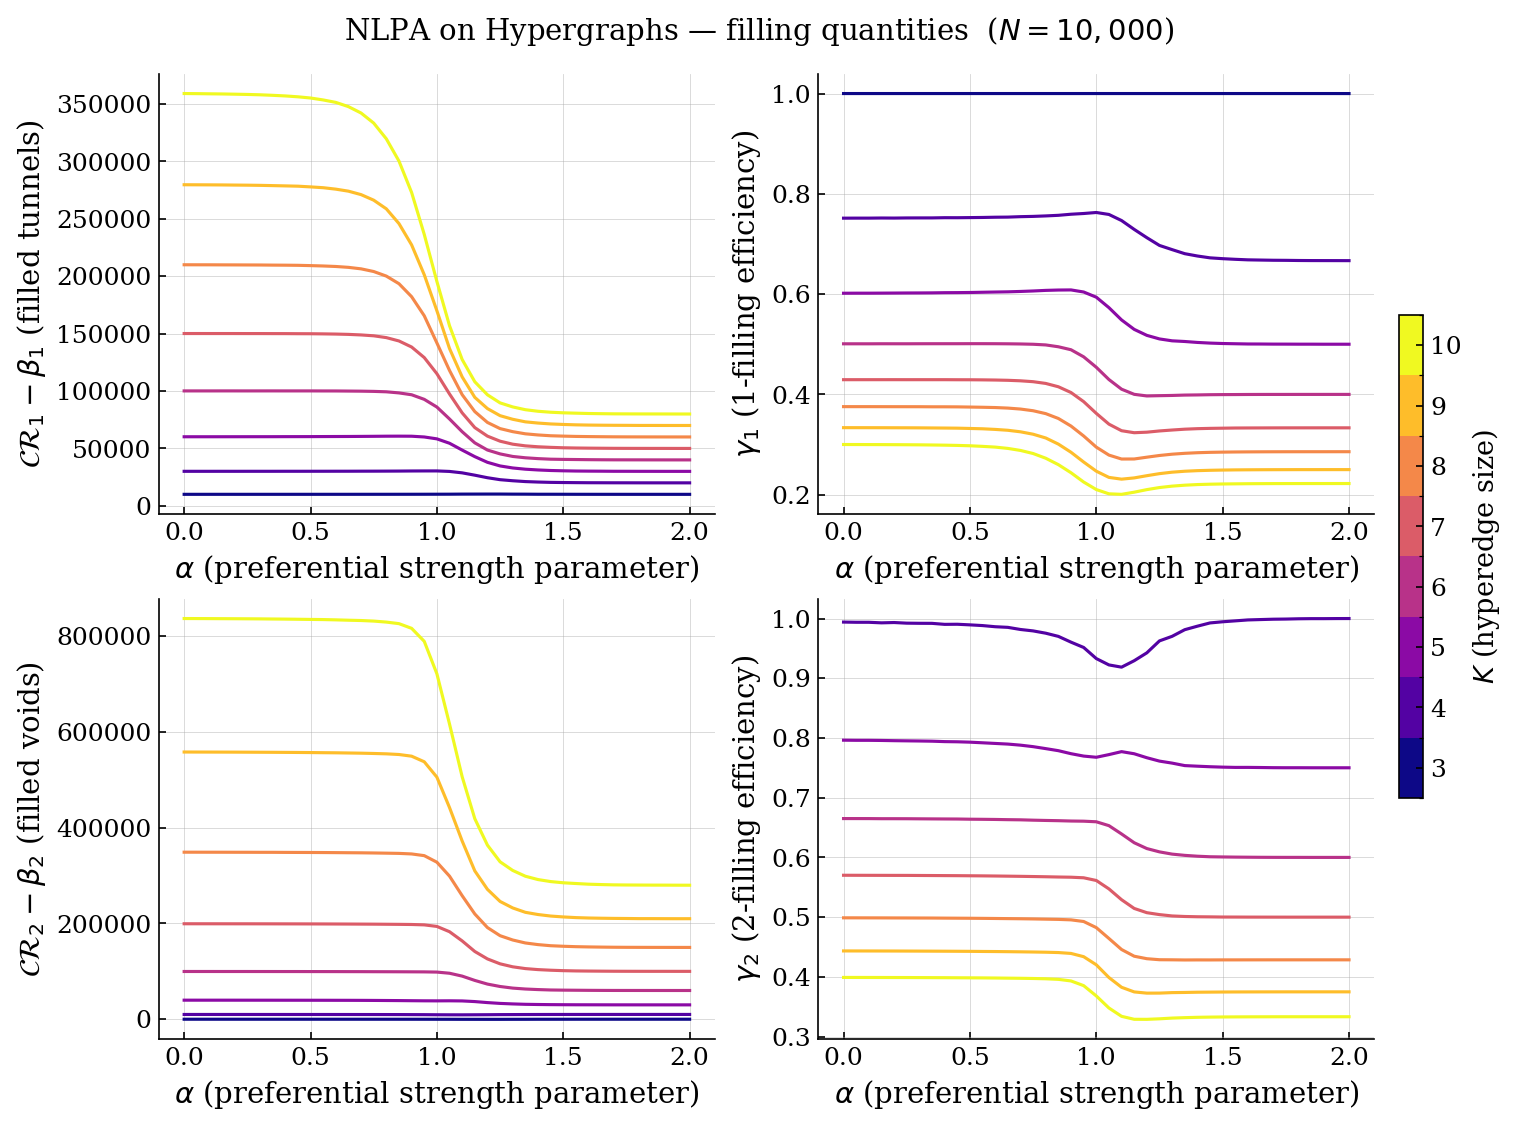

Saved: fig_NLBA_HG_cyclerank


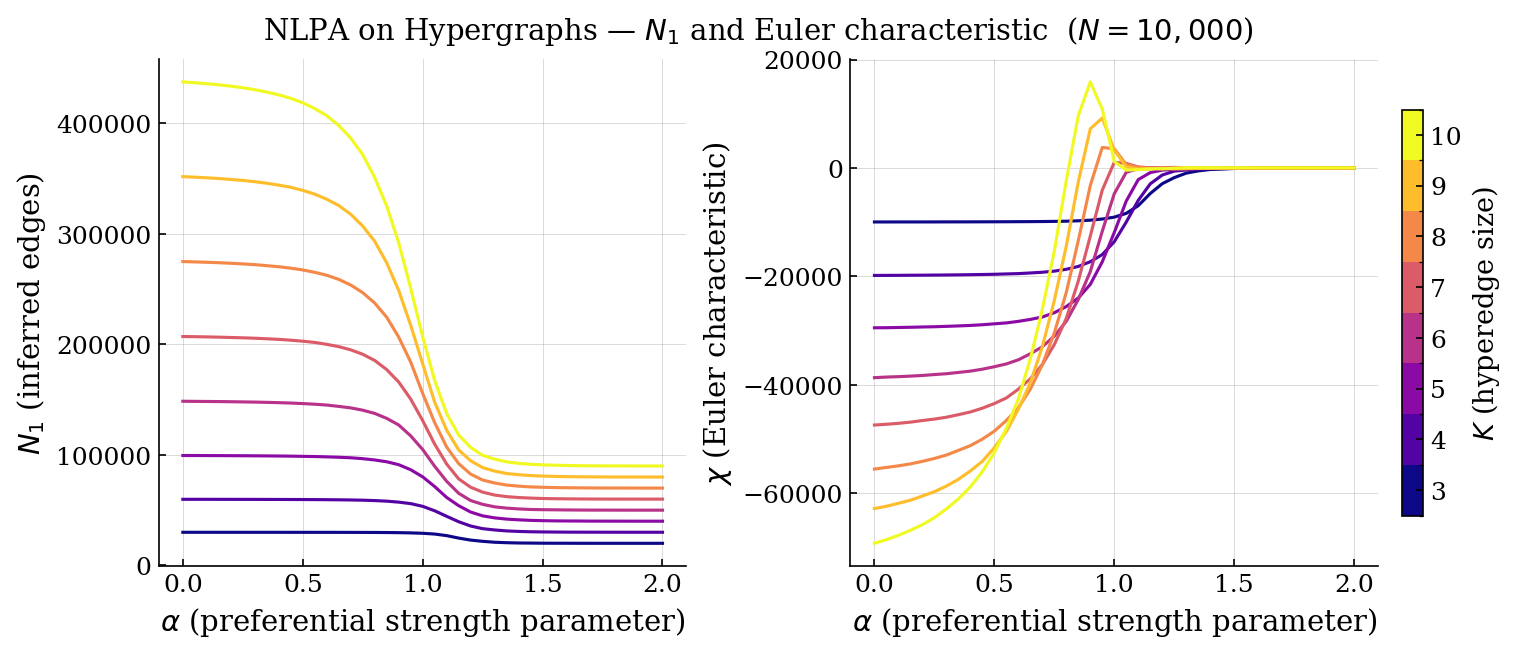

Saved: fig_NLBA_HG_N1_euler


In [9]:
n_plot     = 10000
alpha_keys = [round(a, 4) for a in alphas]
save_base  = 'Hypergraphs/BarabasiAlbert/'

# Discrete colormap over K
n_k        = len(K)
k_cmap     = cm.get_cmap('plasma', n_k)
k_colors   = {k: k_cmap(i) for i, k in enumerate(K)}
k_boundaries = np.arange(n_k + 1) - 0.5
k_norm       = mcolors.BoundaryNorm(k_boundaries, ncolors=n_k)

# ============================================================
# Terminal value extraction
# ============================================================

fields_nlba = {
    r'$\beta_1$ (tunnels)':                          lambda b,sc,e,cr,cr_b1:
        float(b[1][-1]),
    r'$\tilde{\beta}_1=\beta_1/N_1$':                  lambda b,sc,e,cr,cr_b1:
        float(b[1][-1]) / float(sc[-1, 1]) if sc[-1, 1] > 0 else 0.0,
    r'$\beta_2$ (voids)':                          lambda b,sc,e,cr,cr_b1:
        float(b[2][-1]),
    r'$\tilde{\beta}_2=\beta_2/N_2$':                  lambda b,sc,e,cr,cr_b1:
        float(b[2][-1]) / float(sc[-1, 2]) if sc[-1, 2] > 0 else 0.0,
    r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)':        lambda b,sc,e,cr,cr_b1:
        float(cr_b1[-1]),
    r'$\gamma_1$ (1-filling efficiency)':                         lambda b,sc,e,cr,cr_b1:
        np.clip(float(cr_b1[-1]) / float(sc[-1, 2]), 0.0, 1.0)
        if sc[-1, 2] > 0 else 0.0,
    r'$\mathcal{CR}_2 - \beta_2$ (filled voids)':        lambda b,sc,e,cr,cr_b1:
        cR2_terminal(b, sc) - float(b[2][-1]),
    r'$\gamma_2$ (2-filling efficiency)':                         lambda b,sc,e,cr,cr_b1:
        np.clip(
            (cR2_terminal(b, sc) - float(b[2][-1])) / float(sc[-1, 3]),
            0.0, 1.0)
        if sc[-1, 3] > 0 else 0.0,
    r'$N_1$ (inferred edges)':                              lambda b,sc,e,cr,cr_b1:
        float(sc[-1, 1]),
    r'$\chi$ (Euler characteristic)':                             lambda b,sc,e,cr,cr_b1:
        float(e[-1]) if e is not None else np.nan,
}

# ============================================================
# Figure 1: β1, β̃1 | β2, β̃2
# ============================================================
draw_nlba_figure(data, base_path, n_plot, k, k_colors, k_cmap, k_norm, n_k, K, alphas, alpha_keys, fields_nlba,
    panels      = [[r'$\beta_1$ (tunnels)',  r'$\tilde{\beta}_1=\beta_1/N_1$'],
                   [r'$\beta_2$ (voids)',  r'$\tilde{\beta}_2=\beta_2/N_2$']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = rf'NLPA on Hypergraphs — Betti numbers  ($N={n_plot:,}$)',
    save_prefix = 'fig_NLBA_HG_betti',
)

# ============================================================
# Figure 2: CR1-β1, γ1 | CR2-β2, γ2
# ============================================================
draw_nlba_figure(data, base_path, n_plot, k, k_colors, k_cmap, k_norm, n_k, K, alphas, alpha_keys, fields_nlba,
    panels      = [[r'$\mathcal{CR}_1 - \beta_1$ (filled tunnels)',  r'$\gamma_1$ (1-filling efficiency)'],
                   [r'$\mathcal{CR}_2 - \beta_2$ (filled voids)',  r'$\gamma_2$ (2-filling efficiency)']],
    nrows=2, ncols=2, figsize=(10, 7),
    suptitle    = rf'NLPA on Hypergraphs — filling quantities  ($N={n_plot:,}$)',
    save_prefix = 'fig_NLBA_HG_cyclerank',
)

# ============================================================
# Figure 3: N1, Euler  (1 row x 2 cols)
# ============================================================
draw_nlba_figure(data, base_path, n_plot, k, k_colors, k_cmap, k_norm, n_k, K, alphas, alpha_keys, fields_nlba,
    panels      = [[r'$N_1$ (inferred edges)',  r'$\chi$ (Euler characteristic)']],
    nrows=1, ncols=2, figsize=(10, 4),
    suptitle    = rf'NLPA on Hypergraphs — $N_1$ and Euler characteristic  ($N={n_plot:,}$)',
    save_prefix = 'fig_NLBA_HG_N1_euler',
    cbar_shrink = 0.8,
)

---
# Generalized Preferential Attachment on Hypergraphs
---

We generalize the preferential attachment model on hypergraphs to include random variables $Y_t$ determining the size of the hyperedge added at time $t$, and a second random variable $X_t$, drawn at each timestep alongside $Y_t$, which specifies the number of new nodes added in that step. At timestep $t$, a hyperedge of size $Y_t$ is formed containing $X_t$ newly added nodes and $Y_t - X_t$ pre-existing nodes selected preferentially, subject to the constraint $X_t \leq Y_t$. Setting $X_t \in \{0, 1\}$ as a Bernoulli draw recovers the model of Avin et al. The ratio $p = E[X_t] / E[Y_t]$ (the expected fraction of nodes in each hyperedge that are new) emerges as the single key parameter governing the stationary hyperdegree distribution

\begin{equation}
    \boxed{P(d_H) = \frac{\Gamma(d_H)\Gamma\left(\frac{1}{1-p}+1\right)}{(1-p)\Gamma\left(\frac{1}{1-p}+d_H+1\right)}}
\end{equation}

Having derived the stationary hyperdegree distribution and its CCDF analytically, we validate these results against simulations of the generalized model with $Y_t \sim \mathrm{Poisson}(5)$ and $X_t \sim \mathrm{Binomial}(Y_t, p)$ for hypergraphs with $N=$ 1,000,000 nodes, and subsequently investigate several topological properties of the model as a function of $p$ and $E[Y_t]$.

## Generating Poisson-Binomial hypergraphs

In [ ]:
# Set N to be list containing numbers of nodes to be in the network; P to be the
# terminal edge density
lam = [5]; p = [.01,.1,.2,.3,.4,.5]; N = [100000]; iteration = [1,2,3,4,5] #p = [.01,.05,.1,.2,.3,.4,.5,.6,.7,.8,.9]; N = [1000000]; iteration = [1,2,3,4,5,6,7,8,9,10]
# Given lists of parameter values, get every pair of parameter values
# I.E take the crossproduct of the sets of parameters
params = [lam, p, N, iteration]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

# Actual call to parallel function
results = Parallel(n_jobs=num_cores)(delayed(PC_PA_Poisson_Binomial_HypergraphModel)(param) for param in tqdm(params))

  0%|          | 0/30 [00:00<?, ?it/s]

## Computing CCDF, averaging over iterations

In [ ]:
# Set parameters across which to aggregate data
Lam = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]; P = [.005,.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]; N = 1000000; iterations = [1,2,3,4,5,6,7,8,9,10]

for lam in tqdm(Lam):
  for p in tqdm(P):
    result = extract_CCDF(N, lam, p, iterations)

## Loading CCDF for plot

In [10]:
Lam = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50,100]
P   = [.01,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]
N   = 1000000

all_params = [(lam, p) for lam in Lam for p in P]

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_ccdf)(N, lam, p)
    for lam, p in tqdm(all_params, desc='Loading CCDFs')
)

P_PB_HG_c    = {}
P_PB_HG_bins = {}
failed       = []

for (lam, p), ccdf, err in results:
    if ccdf is not None:
        P_PB_HG_c[(lam, p)]    = ccdf
        P_PB_HG_bins[(lam, p)] = list(range(len(ccdf)))
    else:
        failed.append(((lam, p), err))

print(f'Loaded:  {len(P_PB_HG_c)}/{len(all_params)}')
print(f'Failed:  {len(failed)}')
for key, err in failed:
    print(f'  {key}: {err}')

Loading CCDFs:   0%|          | 0/644 [00:00<?, ?it/s]

Loaded:  644/644
Failed:  0


## Plotting CCDF of Poisson-Binomial generalized hypergraph model

/tmp/ipykernel_42778/716775129.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p_cmap       = cm.get_cmap('plasma', n_p)


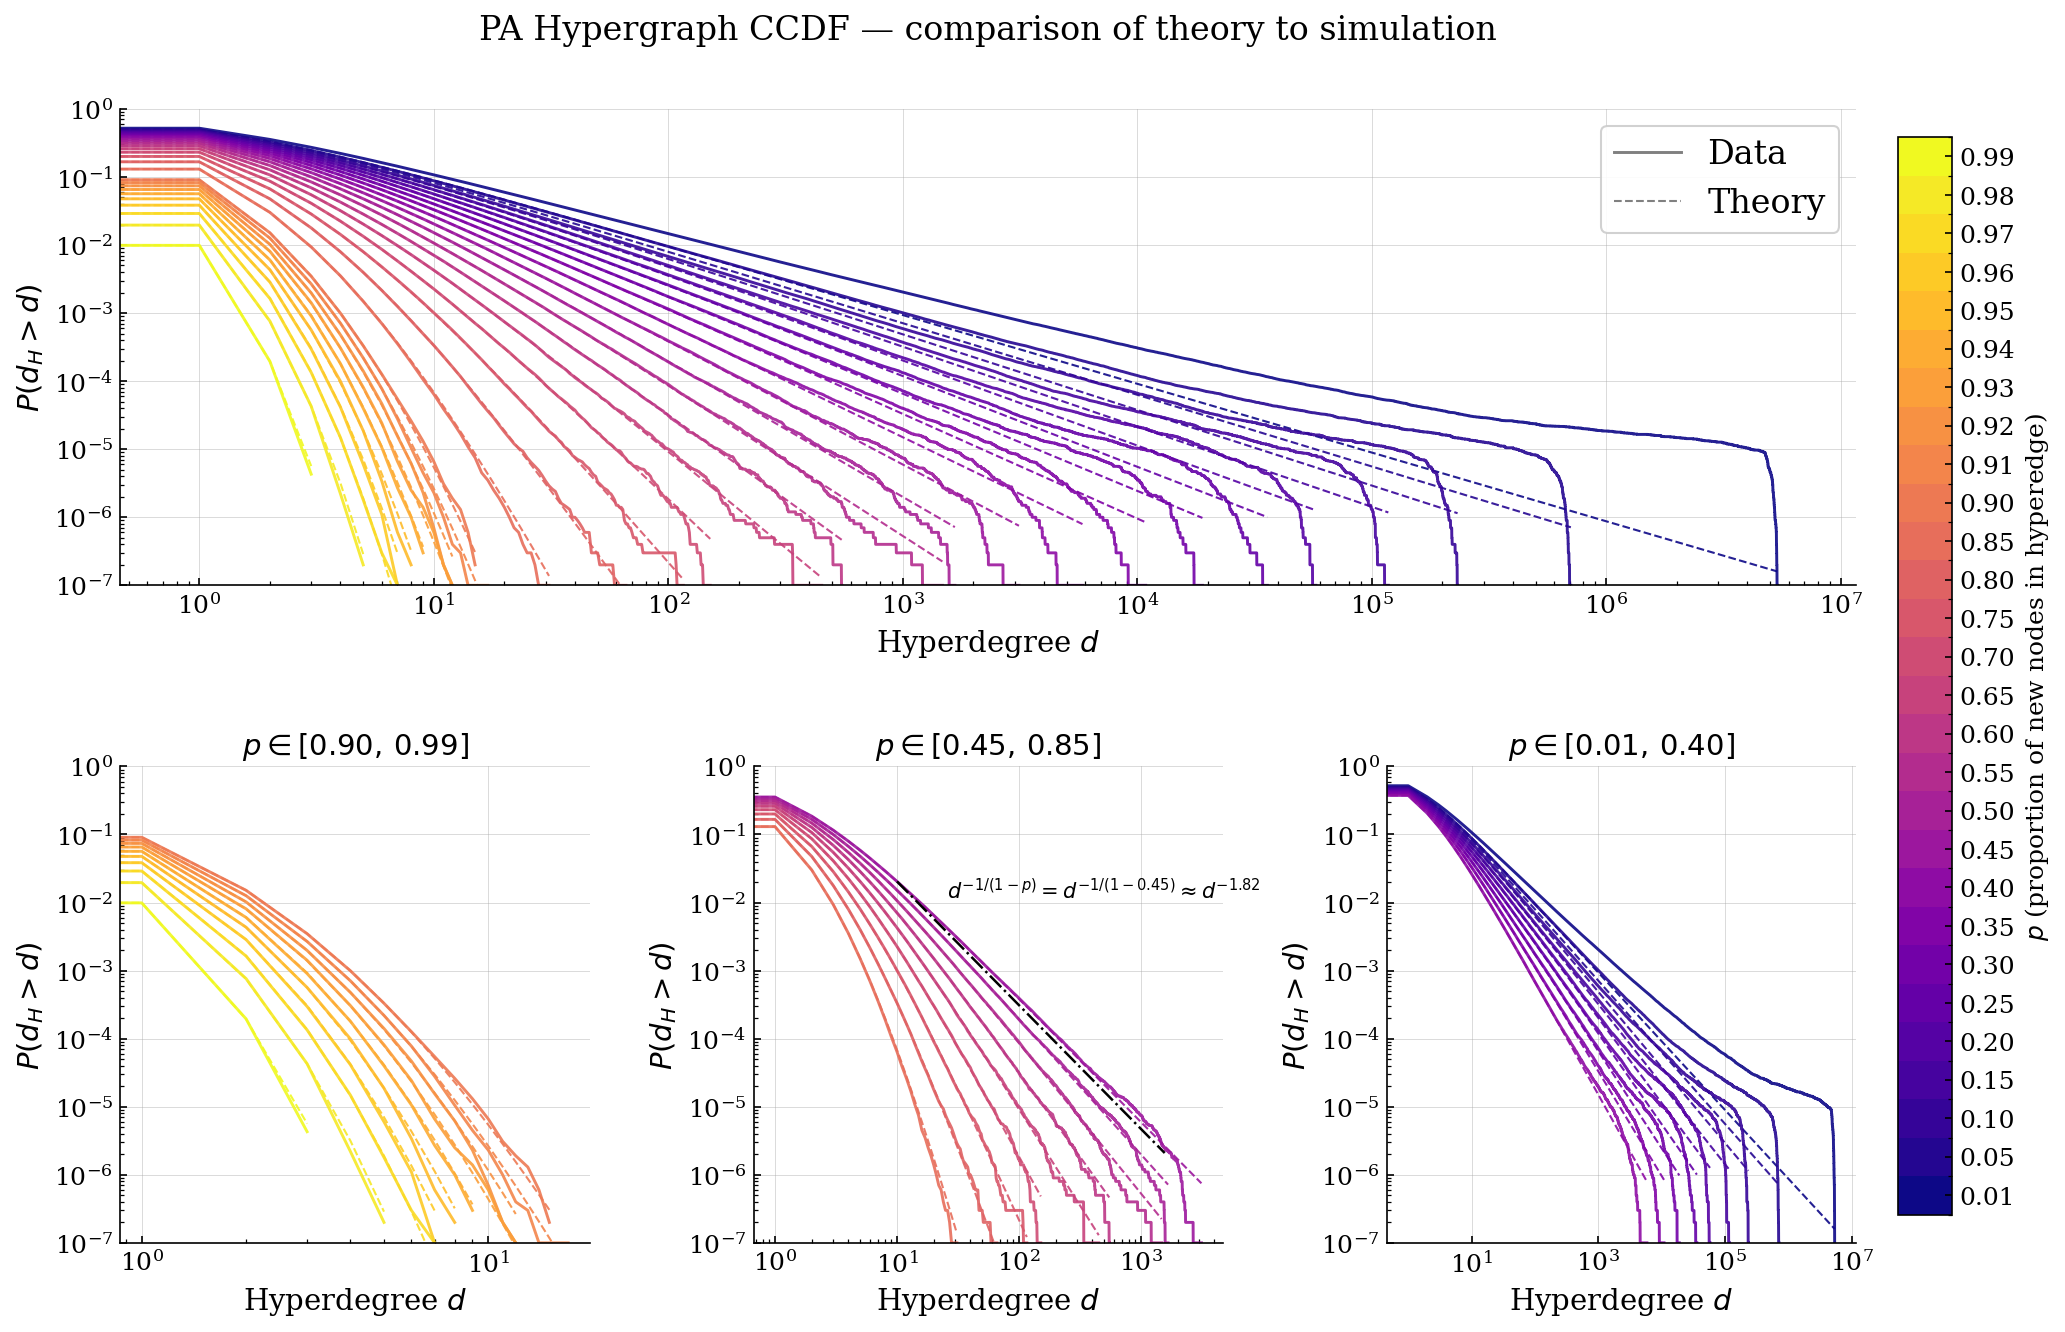

Saved: fig_PB_HG_CCDF_lam5


In [11]:
save_base = 'Hypergraphs/Processed/CCDF/'
L_plot    = [2, 5, 10, 20]

# ── split P into thirds ───────────────────────────────────────────────────────

P_sorted = sorted(P)
n_p_tot  = len(P_sorted)
t1       = n_p_tot // 3
t2       = 2 * n_p_tot // 3
P_thirds = [P_sorted[t2:], P_sorted[t1:t2], P_sorted[:t1]]
third_titles = [
    rf'$p \in [{min(P_thirds[0]):.2f},\,{max(P_thirds[0]):.2f}]$',
    rf'$p \in [{min(P_thirds[1]):.2f},\,{max(P_thirds[1]):.2f}]$',
    rf'$p \in [{min(P_thirds[2]):.2f},\,{max(P_thirds[2]):.2f}]$',
]

# ── discrete colormap over all P ─────────────────────────────────────────────

n_p          = len(P_sorted)
p_cmap       = cm.get_cmap('plasma', n_p)
p_colors     = {p: p_cmap(i) for i, p in enumerate(P_sorted)}
p_boundaries = np.arange(n_p + 1) - 0.5
p_norm       = mcolors.BoundaryNorm(p_boundaries, ncolors=n_p)

# ── main loop ─────────────────────────────────────────────────────────────────

for lam in L_plot[1:2]:
    # GridSpec: 2 rows, 3 cols. Top row spans all 3 cols; bottom row has 3 panels.
    fig = plt.figure(figsize=(17, 9))
    gs  = gridspec.GridSpec(
        2, 3,
        figure=fig,
        hspace=0.38, wspace=0.35,
        left=0.06, right=0.88, top=0.91, bottom=0.07,
    )

    ax_top    = fig.add_subplot(gs[0, :])          # full-width top panel
    ax_bot    = [fig.add_subplot(gs[1, c]) for c in range(3)]

    # ── top panel: all P ─────────────────────────────────────────────────────
    draw_panel(ax_top, lam, P_sorted, p_colors, P_PB_HG_c, P_PB_HG_bins)

    # ── bottom panels: thirds ─────────────────────────────────────────────────
    p_ref = 0.45
    for ax, p_subset, title in zip(ax_bot, P_thirds, third_titles):
        draw_panel(ax, lam, p_subset, p_colors, P_PB_HG_c, P_PB_HG_bins)
        ax.set_title(title, pad=6)

    # reference slope on mid panel, anchored to p=0.45 curve
    add_slope_line(ax_bot[1], lam, P_PB_HG_c, P_PB_HG_bins, p_ref=p_ref, x_anchor=10.0)

    # ── shared colorbar across all axes ──────────────────────────────────────
    all_axes = [ax_top] + ax_bot
    add_shared_cbar(fig, all_axes, n_p, p_cmap, p_norm, P_sorted)

    # ── legend on top panel ───────────────────────────────────────────────────
    legend_elements = [
        Line2D([0], [0], color='grey', ls='-',  lw=1.4, label='Data'),
        Line2D([0], [0], color='grey', ls='--', lw=1.0, label='Theory'),
    ]
    ax_top.legend(handles=legend_elements, loc='upper right',
                  fontsize=16, framealpha=0.9)

    fig.suptitle(
        rf'PA Hypergraph CCDF — comparison of theory to simulation',
        fontsize=16, x=0.4, ha='center',
    )

    fig.savefig(save_base + f'fig_PB_HG_CCDF_lam{lam}.pdf',
                dpi=300, bbox_inches='tight')
    fig.savefig(save_base + f'fig_PB_HG_CCDF_lam{lam}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: fig_PB_HG_CCDF_lam{lam}')

## Computing simplex counts to calculate the Euler characteristic

In [ ]:
# Set parameters across which to aggregate data
Lam = [2,3,4,5];
P = [.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]; N = [1000000]; iterations = [1]

params = [Lam, P, N, iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

results = Parallel(n_jobs=num_cores)(delayed(PC_Simplices_Euler)(param) for param in tqdm(params))

## Loading Euler characteristics

In [12]:
Lam        = [2, 3, 4, 5]
P          = [.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]
iterations = [1]
N          = 1000000

all_params = [(lam, p, it) for lam in Lam for p in P for it in iterations]

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_euler)(N, lam, p, it)
    for lam, p, it in tqdm(all_params, desc='Loading Euler characteristics')
)

EulerChar = {}
failed    = []

for (lam, p, it), euler, err in results:
    if euler is not None:
        EulerChar[(lam, p, it)] = euler
    else:
        failed.append(((lam, p, it), err))

print(f'Loaded:  {len(EulerChar)}/{len(all_params)}')
print(f'Failed:  {len(failed)}')
for key, err in failed:
    print(f'  {key}: {err}')

Loading Euler characteristics:   0%|          | 0/116 [00:00<?, ?it/s]

Loaded:  116/116
Failed:  0


## Plotting Euler characteristics

/tmp/ipykernel_42778/1428961110.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  p_cmap       = cm.get_cmap('plasma', n_p)
/tmp/ipykernel_42778/1428961110.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  lam_cmap   = cm.get_cmap('plasma', n_lam)


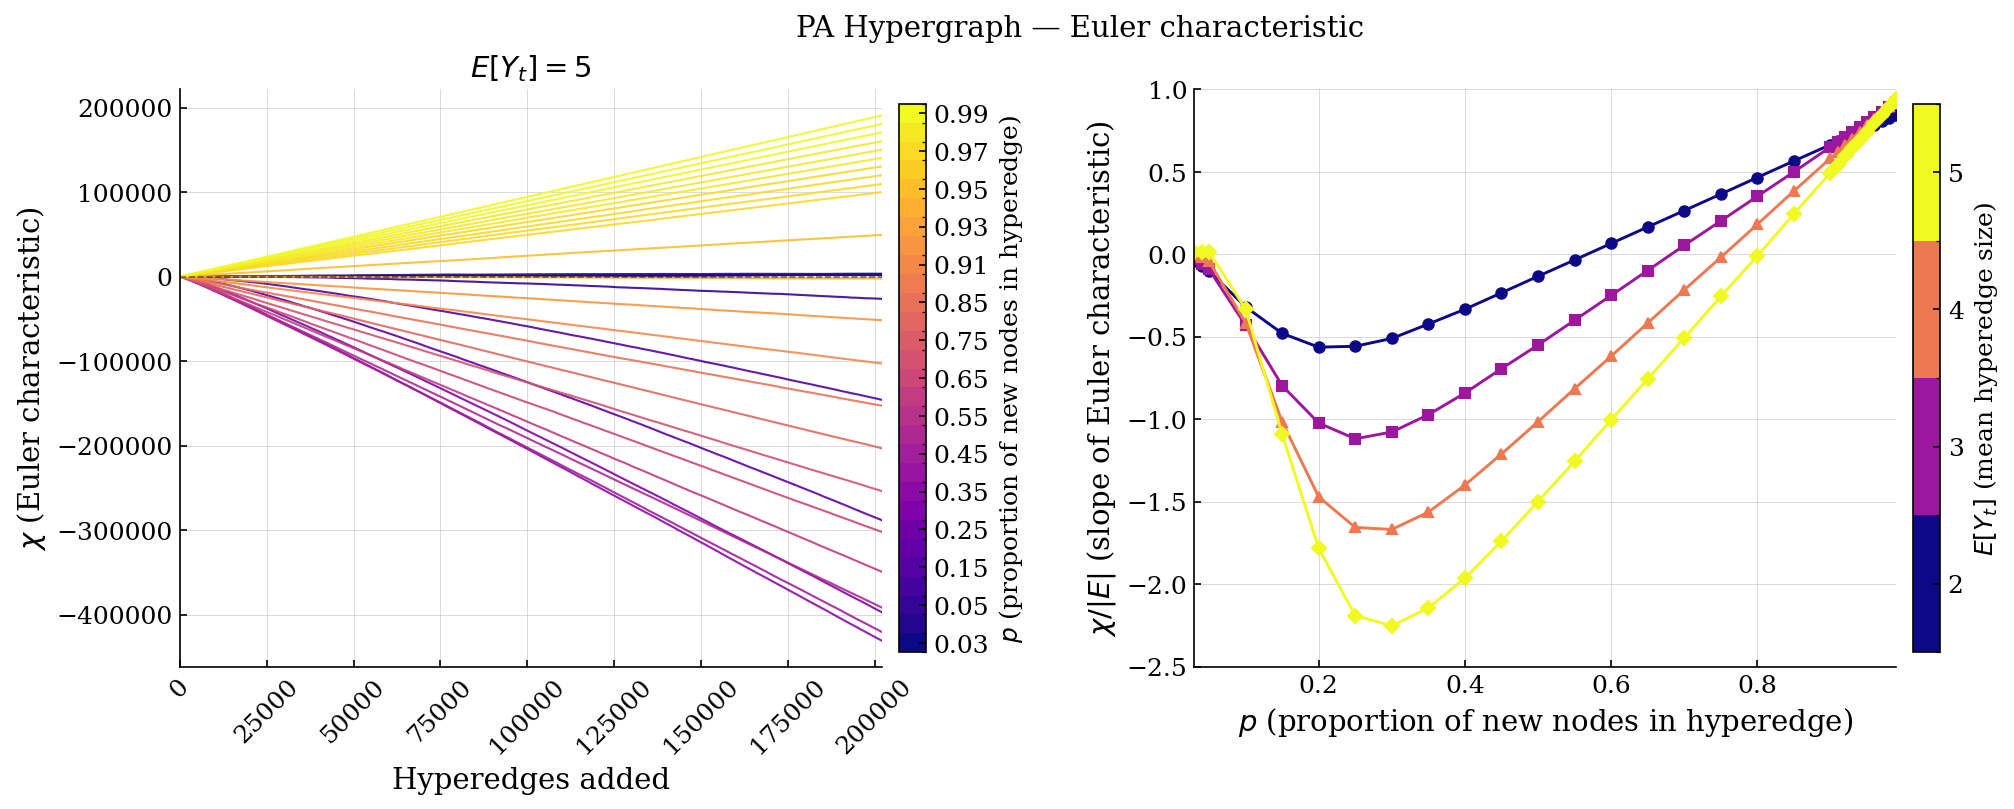

In [13]:
n_p          = len(P)
p_cmap       = cm.get_cmap('plasma', n_p)
p_colors     = {p: p_cmap(i) for i, p in enumerate(P)}
p_boundaries = np.arange(n_p + 1) - 0.5
p_norm       = mcolors.BoundaryNorm(p_boundaries, ncolors=n_p)
n_lam      = len(Lam)
lam_cmap   = cm.get_cmap('plasma', n_lam)
lam_colors = {lam: lam_cmap(i) for i, lam in enumerate(Lam)}
lam_markers = {lam: m for lam, m in zip(Lam, ['o', 's', '^', 'D'])}
lam_boundaries = np.arange(n_lam + 1) - 0.5
lam_norm   = mcolors.BoundaryNorm(lam_boundaries, ncolors=n_lam)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lam      = Lam[3]
ref_len  = len(EulerChar[(lam, P[-1], 1)])
x_axis   = np.arange(ref_len)

# ── left panel: Euler characteristic trajectories, colored by p ───────────────

for p in P:
    y = EulerChar[(lam, p, 1)][:ref_len]
    axes[0].plot(x_axis, y, color=p_cmap(p), lw=1.0, alpha=0.9)

axes[0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
axes[0].set_xlabel(r'Hyperedges added')
axes[0].set_ylabel(r'$\chi$ (Euler characteristic)')
axes[0].set_xlim(0, ref_len)
axes[0].set_title(rf'$E[Y_t] = {lam}$', pad=6)
axes[0].tick_params(axis='x', labelrotation=45)


sm_p = cm.ScalarMappable(cmap=p_cmap, norm=p_norm)
sm_p.set_array([])
cbar_p = fig.colorbar(sm_p, ax=axes[0], pad=0.02, shrink=0.95,
                      ticks=np.arange(0, n_p, 2))
cbar_p.set_ticklabels([f'{P[i]:.2f}' for i in range(0, n_p, 2)])
cbar_p.set_label(r'$p$ (proportion of new nodes in hyperedge)', fontsize=12)

# ── right panel: Euler characteristic slopes, colored by lam ─────────────────

for lam_i in Lam:
    euler_slopes = [
        EulerChar[(lam_i, p, 1)][-1] / len(EulerChar[(lam_i, p, 1)])
        for p in P
    ]
    axes[1].plot(P, euler_slopes,
                 color=lam_colors[lam_i],
                 marker=lam_markers[lam_i],
                 markersize=5,
                 lw=1.4,
                 label=rf'$E[Y_t] = {lam_i}$')

axes[1].set_xlabel(r'$p$ (proportion of new nodes in hyperedge)')
axes[1].set_ylabel(r'$\chi / |E|$ (slope of Euler characteristic)')
axes[1].set_xlim(P[0], P[-1])
axes[1].set_ylim(-2.5, 1.0)

sm_lam = cm.ScalarMappable(cmap=lam_cmap, norm=lam_norm)
sm_lam.set_array([])
cbar_lam = fig.colorbar(sm_lam, ax=axes[1], pad=0.02, shrink=0.95,
                        ticks=np.arange(n_lam))
cbar_lam.set_ticklabels([str(lam_i) for lam_i in Lam])
cbar_lam.set_label(r'$E[Y_t]$ (mean hyperedge size)', fontsize=12)

fig.suptitle(rf'PA Hypergraph — Euler characteristic',
             fontsize=14)

save_base_euler = 'Hypergraphs/Processed/Simplices_Euler/'
fig.savefig(save_base_euler + 'fig_PA_PB_HG_Euler_combined.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(save_base_euler + 'fig_PA_PB_HG_Euler_combined.png',
            dpi=300, bbox_inches='tight')
plt.show()

## Computing simplicial fraction

In [ ]:
# Set parameters across which to aggregate data
#Lam = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]; P = [.005,.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]; N = 1000000; iterations = [1,2,3,4,5,6,7,8,9,10]

Lam = [2,3,4,5,6,7,8,9,10];
P = [.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]; N = 1000000; iterations = [1,2,3,4,5,6,7,8,9,10]

params = [Lam, P, [N], iterations]
params = [p for p in product(*params)]

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

results = Parallel(n_jobs=num_cores)(delayed(PC_SimplicialFraction)(param) for param in tqdm(params))

## Loading simplicial fractions

In [14]:
Lam        = [2,3,4,5,6,7,8,9,10]
P          = [.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]
iterations = [1,2,3,4,5,6,7,8,9,10]
N          = 1000000

all_params = [(lam, p, it) for lam in Lam for p in P for it in iterations]

results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_sf)(N, lam, p, it)
    for lam, p, it in tqdm(all_params, desc='Loading SF data')
)

SF      = {}
Lengths = {}
failed  = []

for (lam, p, it), sf, lengths, err in results:
    if sf is not None:
        SF[(lam, p, it)]      = sf
        Lengths[(lam, p, it)] = lengths
    else:
        failed.append(((lam, p, it), err))

print(f'Loaded:  {len(SF)}/{len(all_params)}')
print(f'Failed:  {len(failed)}')
for key, err in failed:
    print(f'  {key}: {err}')

Loading SF data:   0%|          | 0/2790 [00:00<?, ?it/s]

Loaded:  2790/2790
Failed:  0


## Plot simplicial fractions

/tmp/ipykernel_42778/4196496128.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  lam_cmap       = cm.get_cmap('plasma', n_lam)


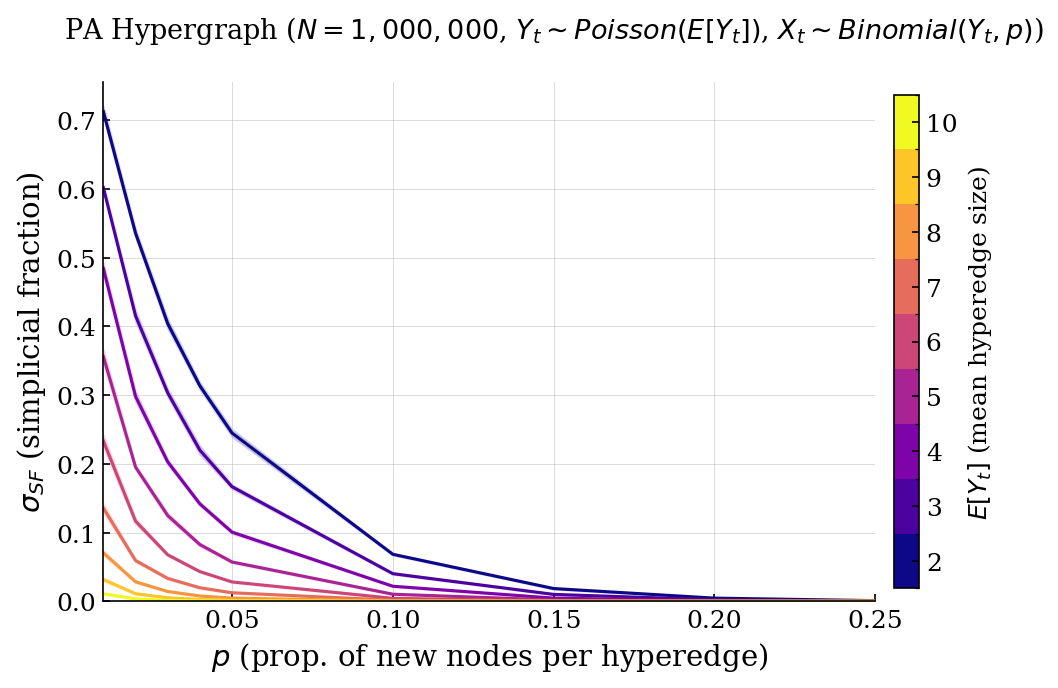

In [15]:
# ── parameters (must match those used during loading) ────────────────────────

Lam        = [2, 3, 4, 5, 6, 7, 8, 9, 10]
P          = [.01,.02,.03,.04,.05,.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.91,.92,.93,.94,.95,.96,.97,.98,.99]
iterations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
N          = 1000000
P_plot     = P[:9]   # restrict to low-p regime [0.01, 0.20]

# ── discrete colormap over Lam ────────────────────────────────────────────────

n_lam          = len(Lam)
lam_cmap       = cm.get_cmap('plasma', n_lam)
lam_colors     = {lam: lam_cmap(i) for i, lam in enumerate(Lam)}
lam_boundaries = np.arange(n_lam + 1) - 0.5
lam_norm       = mcolors.BoundaryNorm(lam_boundaries, ncolors=n_lam)

# ── figure ────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4.5))

for lam in Lam:
    sf_values = np.array(
        [SF[(lam, p, it)] for p in P_plot for it in iterations]
    ).reshape(len(P_plot), len(iterations))

    mean = sf_values.mean(axis=1)
    std  = sf_values.std(axis=1)

    ax.plot(P_plot, mean, color=lam_colors[lam], lw=1.5)
    ax.fill_between(P_plot,
                    mean - std, mean + std,
                    color=lam_colors[lam], alpha=0.15)

ax.set_xlabel(r'$p$ (prop. of new nodes per hyperedge)')
ax.set_ylabel(r'$\sigma_{SF}$ (simplicial fraction)')
ax.set_xlim(P_plot[0], P_plot[-1])
ax.set_ylim(0, None)

sm = cm.ScalarMappable(cmap=lam_cmap, norm=lam_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.95,
                    ticks=np.arange(n_lam))
cbar.set_ticklabels([str(lam) for lam in Lam])
cbar.set_label(r'$E[Y_t]$ (mean hyperedge size)', fontsize=12)

fig.suptitle(rf'PA Hypergraph ($N = {N:,}$, $Y_t\sim Poisson(E[Y_t])$, $X_t\sim Binomial(Y_t,p)$)',
             fontsize=13)

save_base_sf = 'Hypergraphs/Processed/Simpliciality/SimplicialFraction/'
fig.savefig(save_base_sf + 'fig_PA_PB_HG_SF.pdf', dpi=300, bbox_inches='tight')
fig.savefig(save_base_sf + 'fig_PA_PB_HG_SF.png', dpi=300, bbox_inches='tight')
plt.show()

## Computing local simplicial fractions

In [ ]:
lam = 5; N = 100000; P = [.5,.4,.3,.2,.1]; iterations = [1]
for p in tqdm(P):
  for iteration in tqdm(iterations):
    processed_filename = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/Simpliciality/LocalSimplicialFraction/PA_Poisson_Binomial_HypergraphModel_LSF_'+str(lam)+'_'+str(p).replace('.','_')+'_'+str(N)+'_'+str(iteration)+'.pkl'
    if os.path.isfile(processed_filename):
      continue
    filename = '/content/drive/My Drive/Colab Notebooks/Hypergraphs/PA_Poisson_Binomial_HypergraphModel/PA_Poisson_Binomial_HypergraphModel_'+str(lam)+'_'+str(p).replace('.','_')+'_'+str(N)+'_'+str(iteration)+'.pkl'
    result = PC_Get_Simpliciality_LSF(filename, processed_filename, minDim = 2, maxDim = np.inf)

## Loading local simplicial fractions

In [16]:
# Set parameters across which to load the degree distribution
lam = 5; N = 100000; P = [.2,.1]; iterations = [1,2,3,4,5]
# Initialize dictionaries to store CCDFs
LSF = {}; Lengths = {};
for p in tqdm(P):
  for iteration in iterations:
    filename = 'Hypergraphs/Processed/Simpliciality/LocalSimplicialFraction/PA_Poisson_Binomial_HypergraphModel_LSF_'+str(lam)+'_'+str(p).replace('.','_')+'_'+str(N)+'_'+str(iteration)+'.pkl'
    with gzip.open(filename, 'rb') as f:
      LSF[(lam,p,iteration)], _ = pickle.load(f)

  0%|          | 0/2 [00:00<?, ?it/s]

## Plotting local simplicial fractions

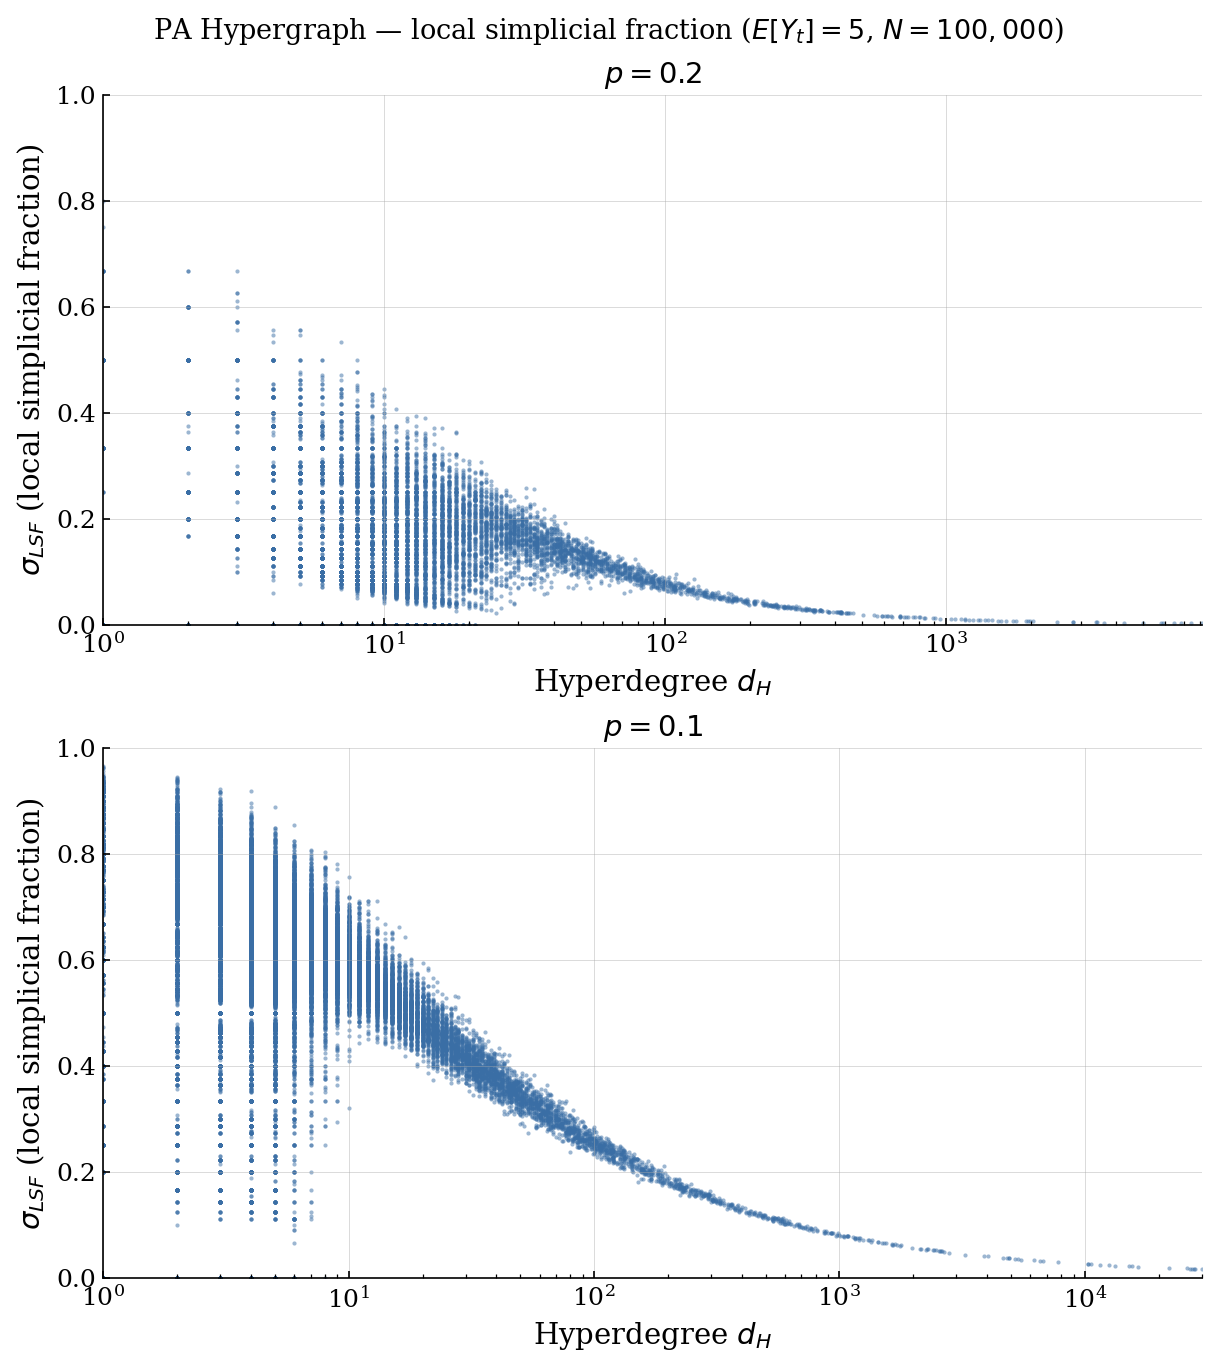

In [17]:
save_base_lsf = 'Hypergraphs/Processed/Simpliciality/LocalSimplicialFraction/'

fig, axes = plt.subplots(2, 1, figsize=(8, 9), constrained_layout=True)

for ax, p in zip(axes, P):
    entries = LSF[(lam, p, iterations[0])]
    degrees = np.array([e[1] for e in entries], dtype=float)
    lsf     = np.array([e[0] for e in entries], dtype=float)

    ax.scatter(degrees, lsf,
               s=4, color='#3a6ea5', alpha=0.5, linewidths=0,
               rasterized=True)

    ax.set_xscale('log')
    ax.set_xlim(degrees.min(), degrees.max())
    ax.set_ylim(0, 1)
    ax.set_xlabel(r'Hyperdegree $d_H$')
    ax.set_ylabel(r'$\sigma_{LSF}$ (local simplicial fraction)')
    ax.set_title(rf'$p = {p}$', pad=6)

fig.suptitle(
    rf'PA Hypergraph — local simplicial fraction ($E[Y_t]={lam}$, $N={N:,}$)',
    fontsize=13,
)

fig.savefig(save_base_lsf + f'fig_PA_PB_HG_LSF_lam{lam}.pdf',
            dpi=300, bbox_inches='tight')
fig.savefig(save_base_lsf + f'fig_PA_PB_HG_LSF_lam{lam}.png',
            dpi=300, bbox_inches='tight')
plt.show()

---
# XGI-DATA Repository Data
---

## Extracting $X_t$'s and $Y_t$'s from data sets

In [ ]:
names = ['congress-bills', 'email-Enron', 'email-EU',
         'contact-high-school', 'contact-primary-school', 'hospital-lyon', 'malawi-village',
         'science-gallery']

# Get number of cpus that can be used
num_cores = multiprocessing.cpu_count()

results = Parallel(n_jobs=num_cores)(delayed(process_dataset)(name) for name in tqdm(names))

## Plotting $X_t$ and $Y_t$ distributions

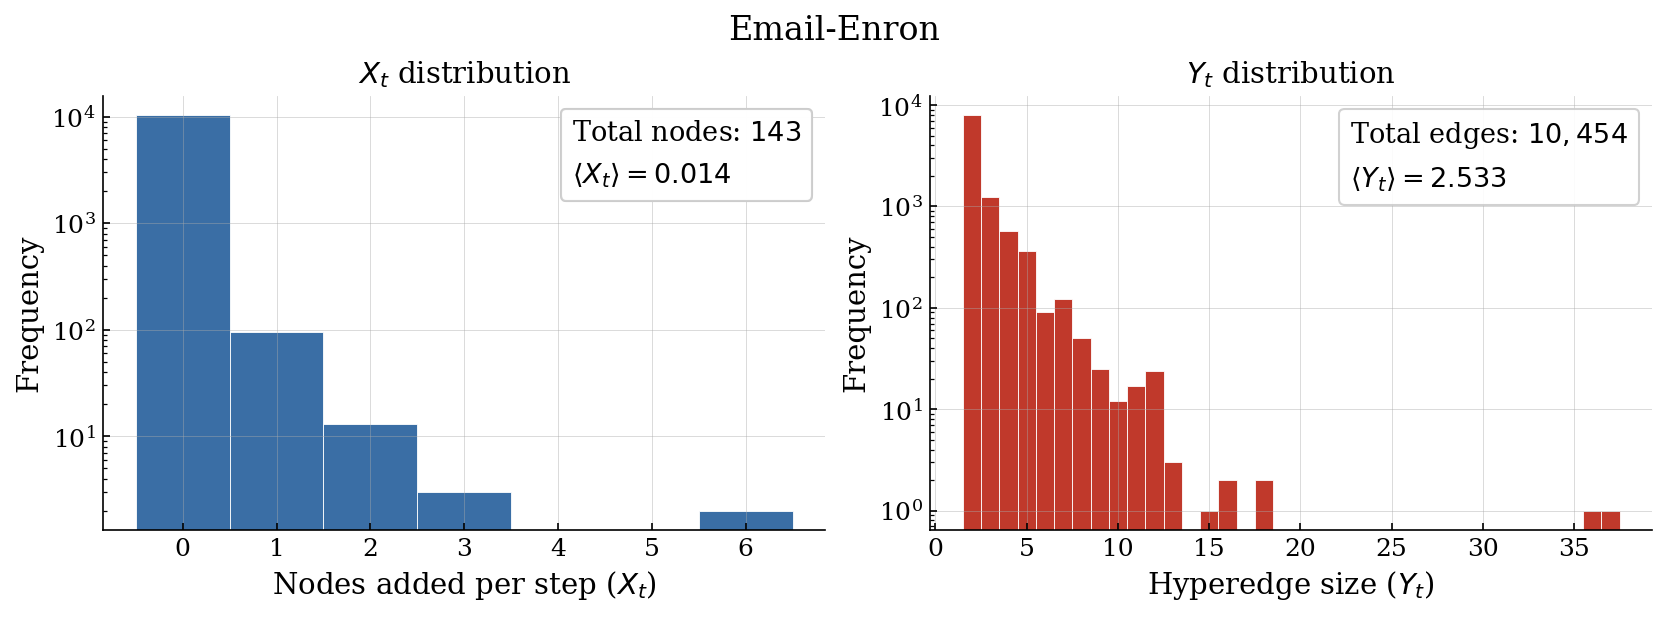

Saved: email-Enron


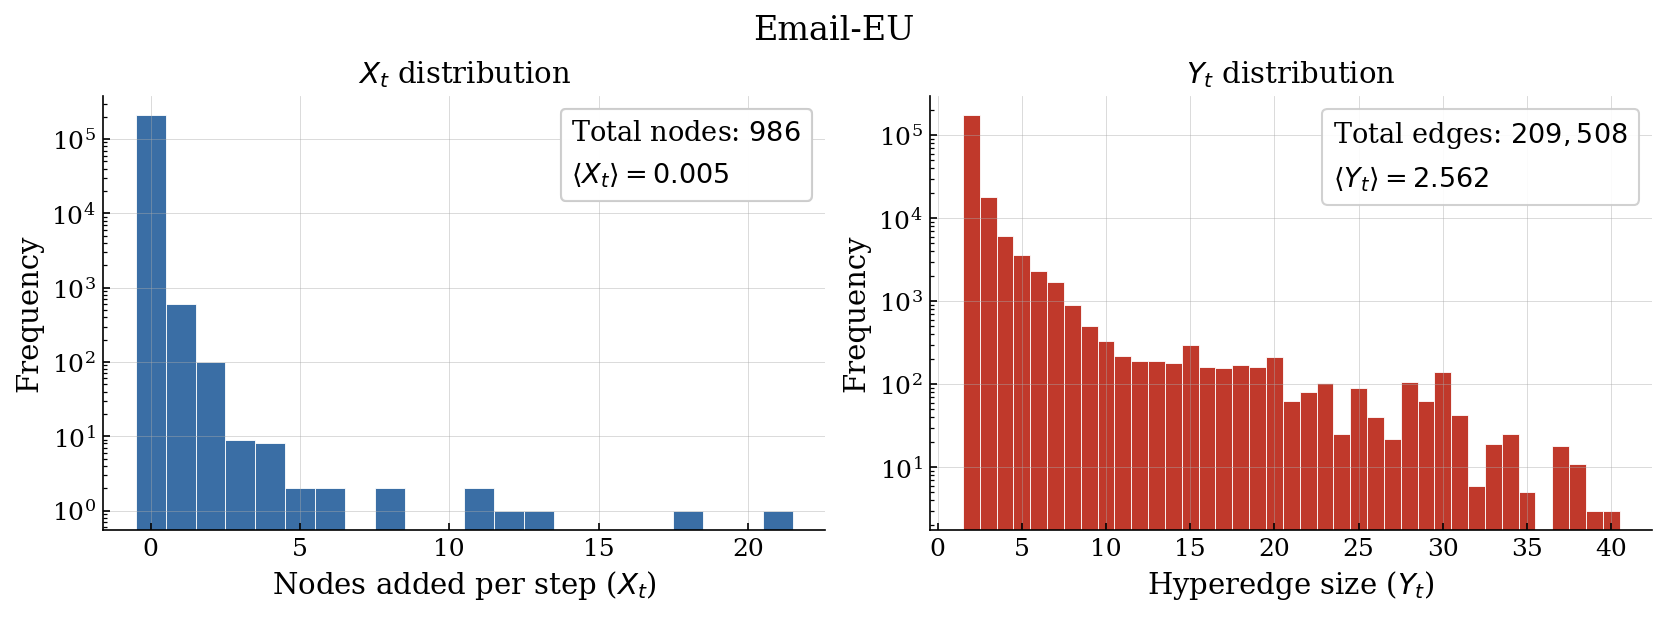

Saved: email-EU


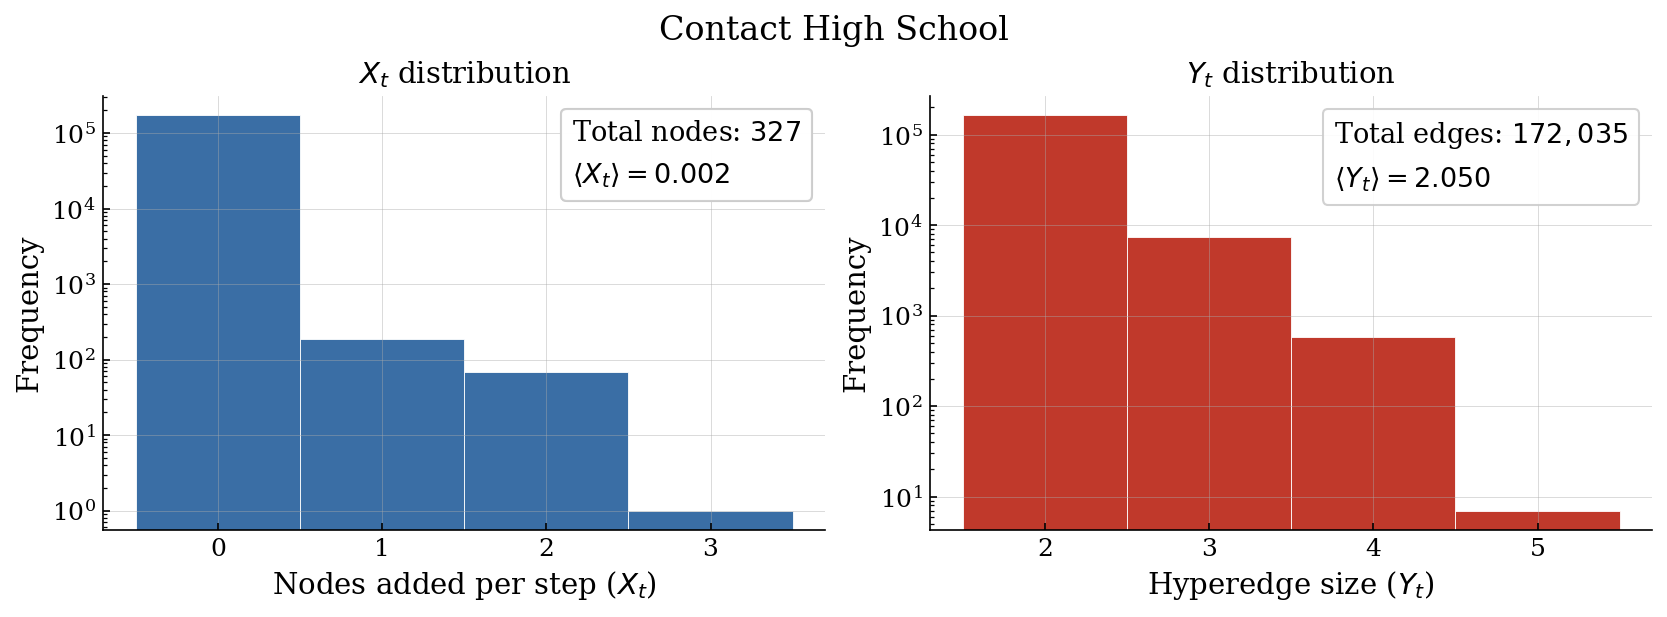

Saved: contact-high-school


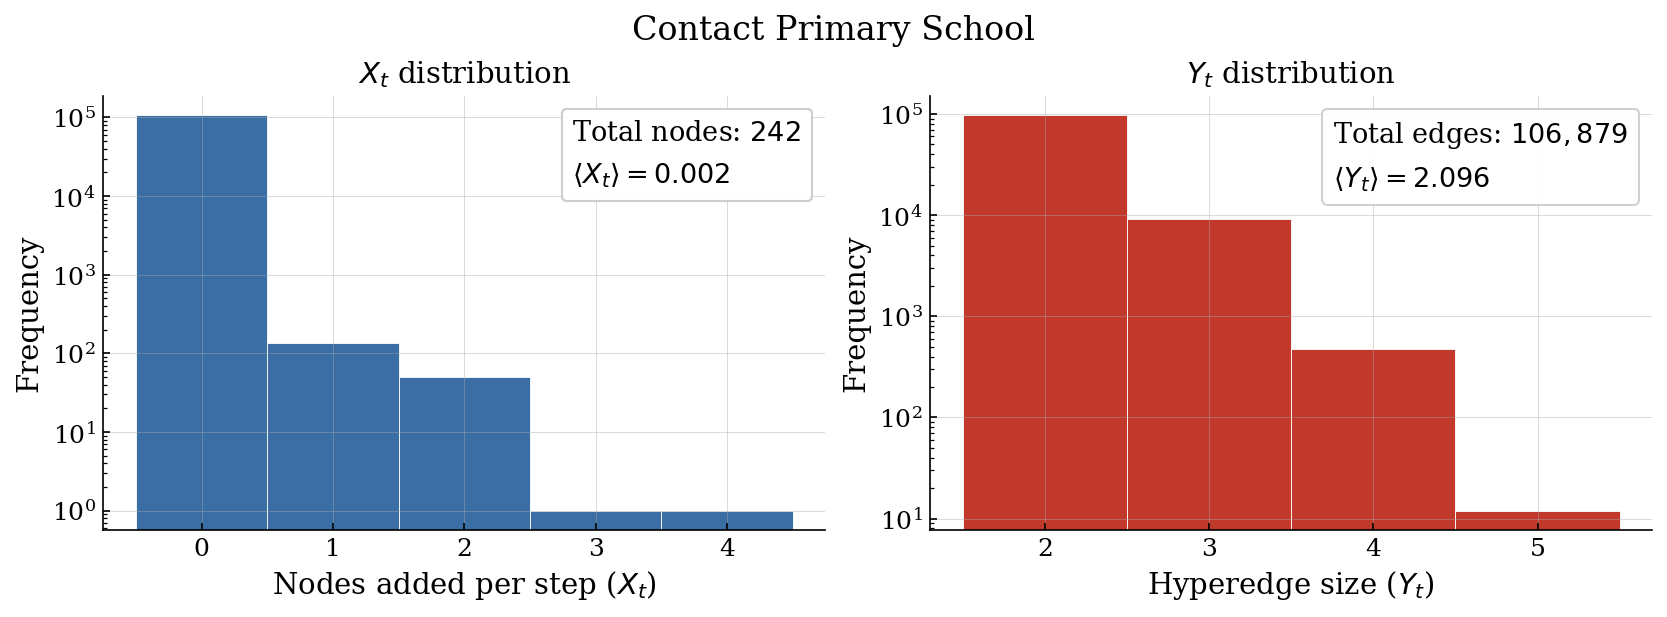

Saved: contact-primary-school


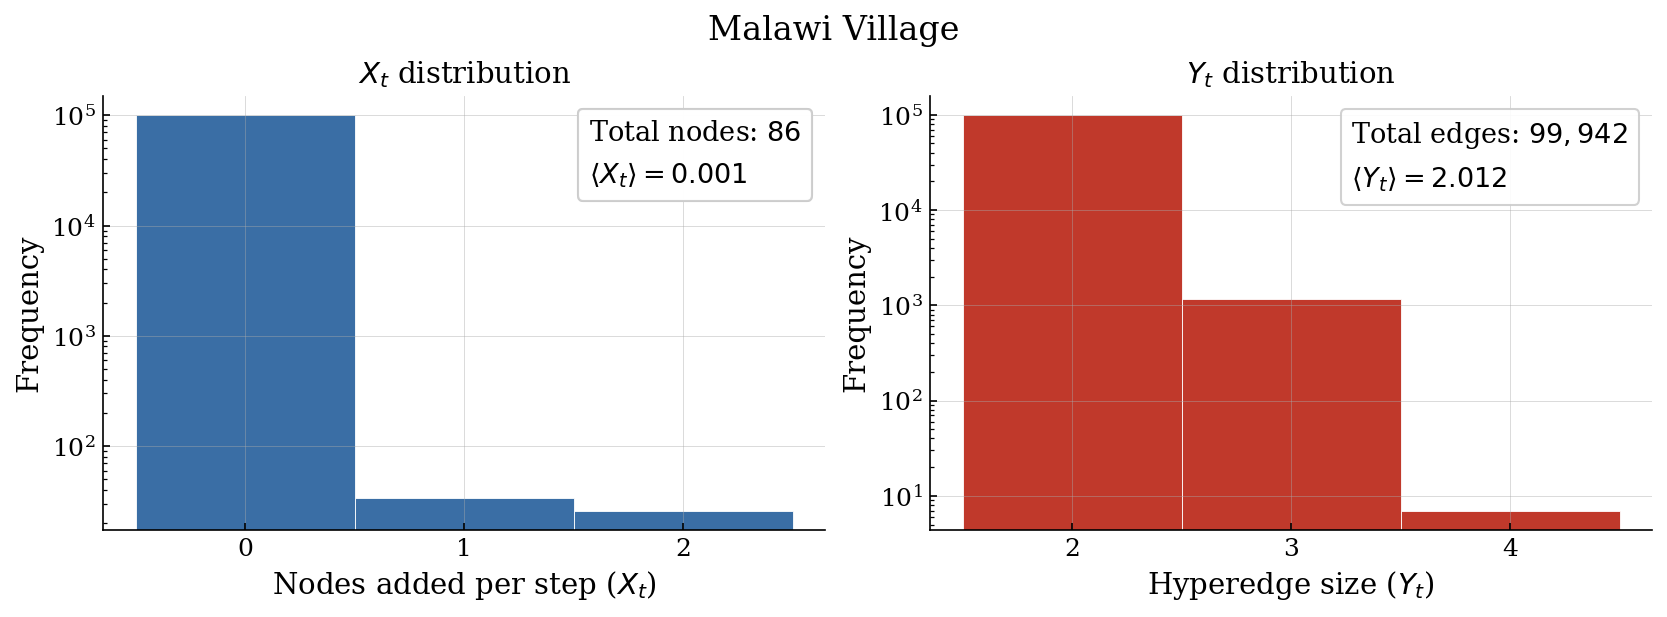

Saved: malawi-village


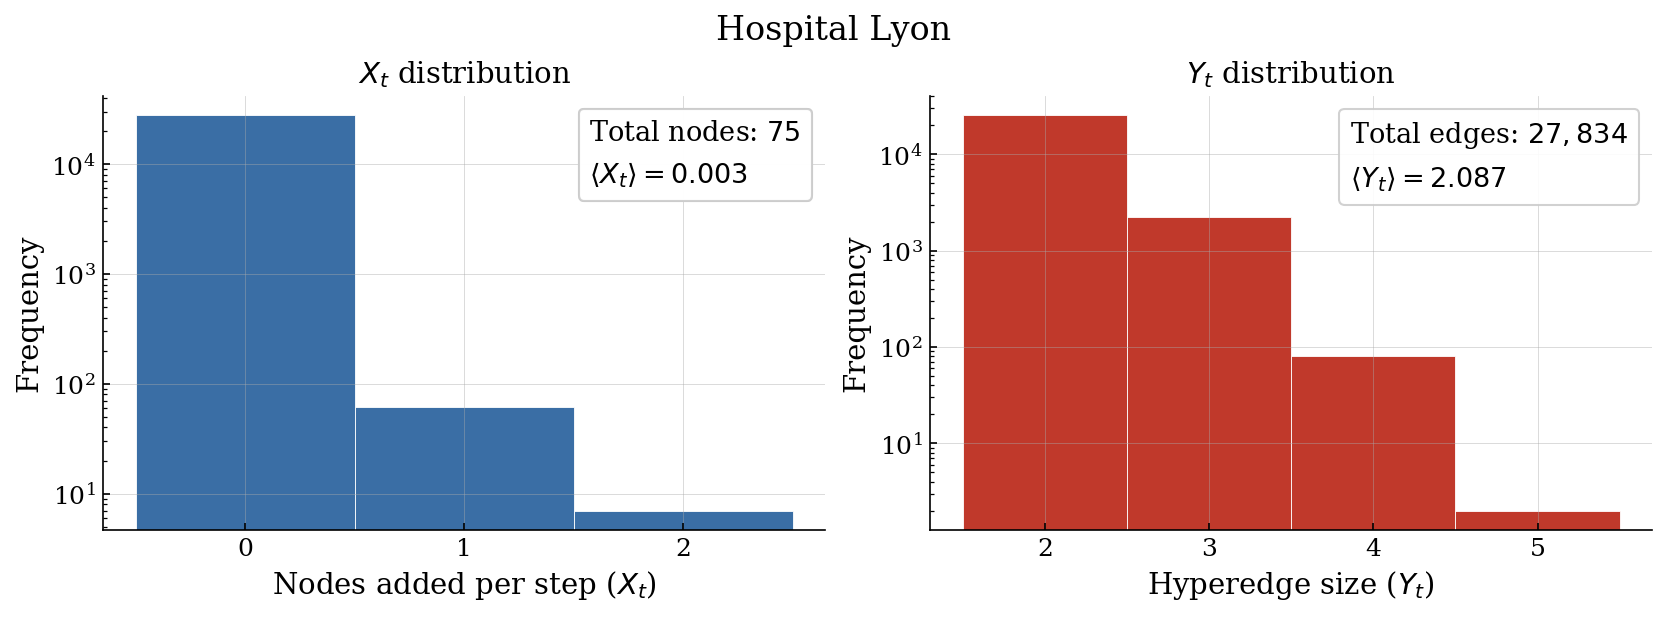

Saved: hospital-lyon


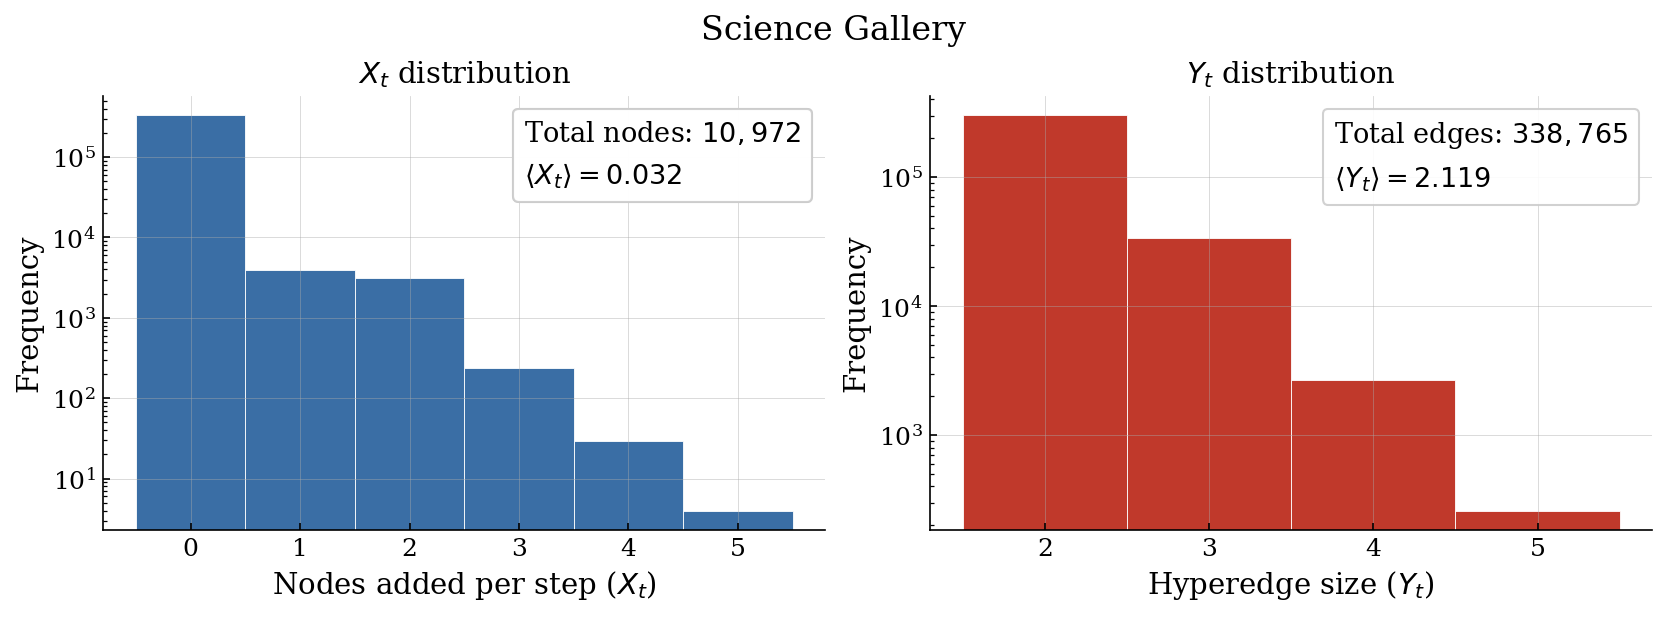

Saved: science-gallery


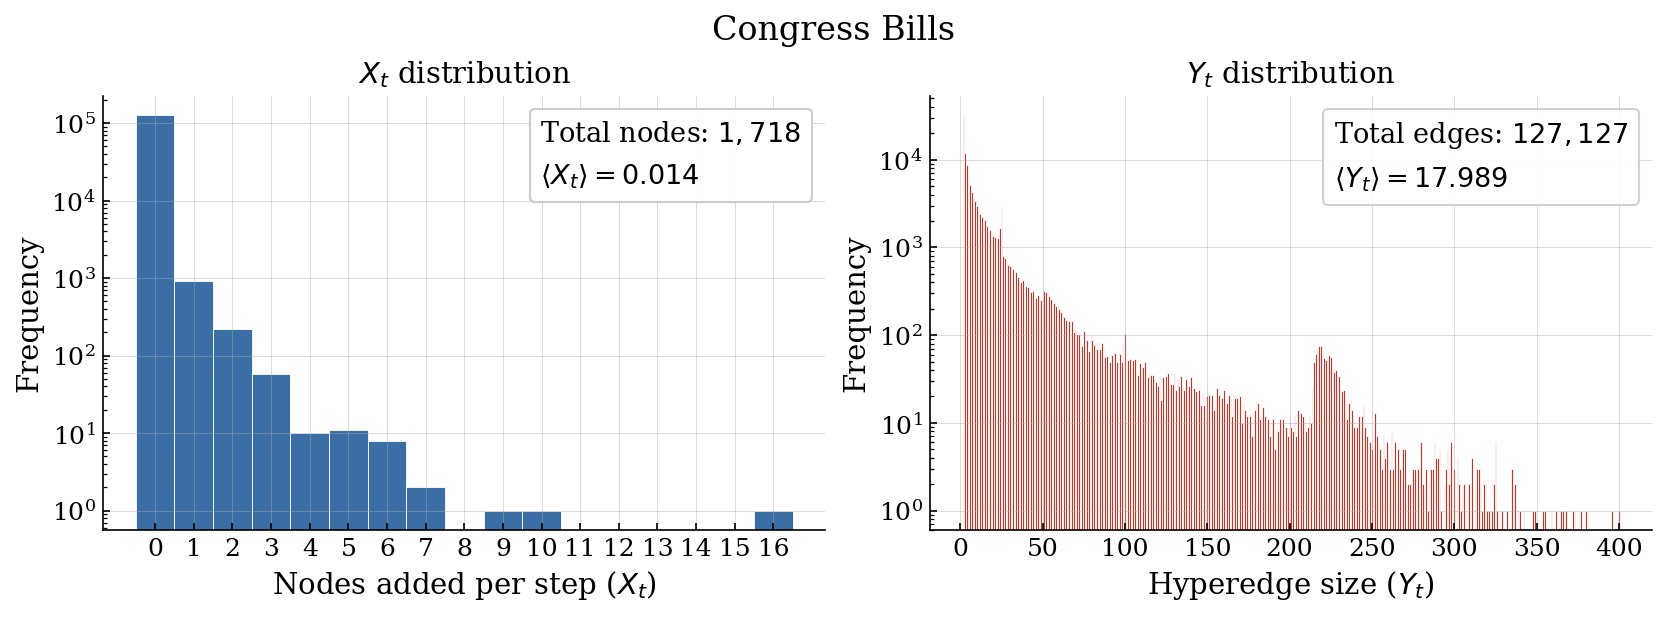

Saved: congress-bills


In [18]:
names     = ['email-Enron', 'email-EU', 'contact-high-school', 'contact-primary-school',
             'malawi-village', 'hospital-lyon', 'science-gallery','congress-bills']
clean_names = ['Email-Enron', 'Email-EU', 'Contact High School', 'Contact Primary School',
               'Malawi Village', 'Hospital Lyon', 'Science Gallery', 'Congress Bills']
load_base = 'Hypergraphs/Processed/XtYt_FromData/'
save_base = 'Hypergraphs/Processed/XtYt_FromData/Figures/'

xt_color = '#3a6ea5'
yt_color = '#c0392b'

for i, name in enumerate(names):
    # ── load ──────────────────────────────────────────────────────────────────
    with gzip.open(load_base + f'{name}.pkl', 'rb') as f:
        extracted_info = pickle.load(f)

    Xt = np.array([e['isolated_nodes'] for e in extracted_info], dtype=int)
    Yt = np.array([e['edge_size']      for e in extracted_info], dtype=int)

    # ── statistics ────────────────────────────────────────────────────────────
    n_nodes     = int(Xt.sum())
    mean_xt     = Xt.mean()
    n_edges     = len(Yt)
    mean_yt     = Yt.mean()

    # ── figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
    clean_name = name.replace('-', ' ').title()
    fig.suptitle(clean_names[i], fontsize=16)

    # ── left panel: Xt ────────────────────────────────────────────────────────
    ax = axes[0]
    bins_xt = np.arange(Xt.min() - 0.5, Xt.max() + 1.5, 1)
    ax.hist(Xt, bins=bins_xt, color=xt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Nodes added per step ($X_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$X_t$ distribution')
    if Xt.max() < 20:
      ax.set_xticks(np.arange(Xt.min(), Xt.max() + 1, 1))

    xt_legend = ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total nodes: ${n_nodes:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle X_t \rangle = {mean_xt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )
    ax.add_artist(xt_legend)

    # ── right panel: Yt ───────────────────────────────────────────────────────
    ax = axes[1]
    bins_yt = np.arange(Yt.min() - 0.5, Yt.max() + 1.5, 1)
    ax.hist(Yt, bins=bins_yt, color=yt_color, edgecolor='white', linewidth=0.4)
    ax.set_yscale('log')
    ax.set_xlabel(r'Hyperedge size ($Y_t$)')
    ax.set_ylabel('Frequency')
    ax.set_title(r'$Y_t$ distribution')
    if Yt.max() < 20:
      ax.set_xticks(np.arange(Yt.min(), Yt.max() + 1, 1))

    ax.legend(
        handles=[
            mpatches.Patch(color='none',
                           label=rf'Total edges: ${n_edges:,}$'),
            mpatches.Patch(color='none',
                           label=rf'$\langle Y_t \rangle = {mean_yt:.3f}$'),
        ],
        loc='upper right', framealpha=0.9, handlelength=0, handletextpad=0,
    )

    # ── save ──────────────────────────────────────────────────────────────────
    plt.show()
    print(f'Saved: {name}')

## Generating preferential attachment hypergraphs from data distributions

In [ ]:
names = ['email-Enron','email-EU',
         'contact-high-school','contact-primary-school','hospital-lyon','malawi-village',
         'science-gallery','SFHH-conference','hypertext-conference','InVS13','InVS15',
         'tags-ask-ubuntu','tags-math-sx',
         'coauth-MAG-history', 'coauth-MAG-geology','threads-ask-ubuntu','threads-math-sx'] #'congress-bills','coauth-dblp',

steps = list(range(1,101))

params = [names, steps]
params = [p for p in product(*params)]

num_cores = 8
results = Parallel(n_jobs=num_cores)(delayed(PC_PA_From_Data)(param) for param in tqdm(params))

## Generating random attachment hypergraphs from data distributions

In [ ]:
names = ['email-Enron','email-EU',
         'contact-high-school','contact-primary-school','hospital-lyon','malawi-village',
         'science-gallery','SFHH-conference','hypertext-conference','InVS13','InVS15',
         'tags-ask-ubuntu','tags-math-sx',
         'coauth-MAG-history', 'coauth-MAG-geology','threads-ask-ubuntu','threads-math-sx'] #'congress-bills','coauth-dblp',

steps = list(range(1,101))

params = [names, steps]
params = [p for p in product(*params)]

num_cores = 8
results = Parallel(n_jobs=num_cores)(delayed(PC_RA_From_Data)(param) for param in tqdm(params))

## Generating NLPA hypergraphs from data distributions

In [ ]:
names = ['hospital-lyon','email-EU', 'email-Enron'
         'contact-high-school','contact-primary-school','hospital-lyon','malawi-village',
         'science-gallery']
steps = range(1,6); alphas = np.linspace(0.2,3,15)

params = [names, alphas, steps]
params = [p for p in product(*params)]

num_cores = 8
results = Parallel(n_jobs=num_cores)(delayed(PC_Nonlinear_PA_From_Data)(param) for param in tqdm(params))

## Loading simplicial fractions for PA, RA and NLPA hypergraphs constructed from data distributions

In [19]:
names  = ['email-Enron', 'contact-high-school', 'contact-primary-school',
          'hospital-lyon', 'malawi-village', 'email-EU', 'science-gallery','congress-bills']
steps  = list(range(1, 21))
alphas = list(np.linspace(0.1, 2, 20))

base_path = 'Hypergraphs/Processed/Simpliciality/SimplicialFraction/'

# ── section 1a: original SF (one file per name) ───────────────────────────────

print('Loading original SF...')
orig_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_original)(name, base_path) for name in names
)

original_SF = {}
for name, val, err in orig_results:
    if val is not None:
        original_SF[name] = val
    else:
        print(f'  original [{name}]: {err}')

# ── section 1b: fromdata SF (name × step) ────────────────────────────────────

print('Loading fromdata SF...')
fromdata_params  = [(name, step) for name in names for step in steps]
fromdata_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_fromdata)(name, step, base_path)
    for name, step in tqdm(fromdata_params, desc='fromdata SF')
)

# assemble into {name: [val_step1, val_step2, ...]} preserving step order
fromdata_SF = {name: [None] * len(steps) for name in names}
for name, step, val, err in fromdata_results:
    if val is not None:
        fromdata_SF[name][steps.index(step)] = val
    else:
        print(f'  fromdata [{name}, step={step}]: {err}')

# ── section 1c: nonlinear SF (name × alpha × step) ───────────────────────────

print('Loading nonlinear SF...')
nonlinear_params  = [(name, alpha, step)
                     for name in names for alpha in alphas for step in steps]
nonlinear_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_nonlinear)(name, alpha, step, base_path)
    for name, alpha, step in tqdm(nonlinear_params, desc='nonlinear SF')
)

# assemble into {(name, alpha): [val_step1, ...]} preserving step order
nonlinear_SF = {(name, alpha): [None] * len(steps)
                for name in names for alpha in alphas}
for name, alpha, step, val, err in nonlinear_results:
    if val is not None:
        nonlinear_SF[(name, alpha)][steps.index(step)] = val
    else:
        pass   # missing nonlinear files are expected; suppress noise

# strip None entries (missing steps) from nonlinear lists
nonlinear_SF = {k: [v for v in lst if v is not None]
                for k, lst in nonlinear_SF.items()}

# ── section 2: RA + shuffled SF (name × step) ────────────────────────────────

print('Loading RA and shuffled SF...')
ra_params  = [(name, step) for name in names for step in steps]
ra_results = Parallel(n_jobs=-1, backend='loky')(
    delayed(load_ra_and_shuffled)(name, step, base_path)
    for name, step in tqdm(ra_params, desc='RA + shuffled SF')
)

RA_fromdata_SF          = {name: [None] * len(steps) for name in names}
random_shuffled_SF      = {name: [None] * len(steps) for name in names}
proportional_shuffled_SF = {name: [None] * len(steps) for name in names}
hyperdegree_shuffled_SF  = {name: [None] * len(steps) for name in names}
layer_shuffled_SF        = {name: [None] * len(steps) for name in names}

for name, step, ra, rand, prop, hypd, layer, err in ra_results:
    idx = steps.index(step)
    if err is None:
        RA_fromdata_SF[name][idx]           = ra
        random_shuffled_SF[name][idx]       = rand
        proportional_shuffled_SF[name][idx] = prop
        hyperdegree_shuffled_SF[name][idx]  = hypd
        layer_shuffled_SF[name][idx]        = layer
    else:
        print(f'  RA/shuffled [{name}, step={step}]: {err}')

# ── summary ───────────────────────────────────────────────────────────────────

print(f'\noriginal_SF:           {len(original_SF)}/{len(names)} names')
print(f'fromdata_SF:           {sum(v is not None for lst in fromdata_SF.values() for v in lst)}/{len(names)*len(steps)} files')
print(f'nonlinear_SF:          {sum(len(v) for v in nonlinear_SF.values())} files across {len(names)*len(alphas)} (name, alpha) pairs')
print(f'RA_fromdata_SF:        {sum(v is not None for lst in RA_fromdata_SF.values() for v in lst)}/{len(names)*len(steps)} files')
print(f'random_shuffled_SF:    {sum(v is not None for lst in random_shuffled_SF.values() for v in lst)}/{len(names)*len(steps)} files')

Loading original SF...
Loading fromdata SF...


fromdata SF:   0%|          | 0/160 [00:00<?, ?it/s]

  fromdata [email-EU, step=2]: [Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/Hypergraphs/Processed/Simpliciality/SimplicialFraction/email-EU_2.pkl'
Loading nonlinear SF...


nonlinear SF:   0%|          | 0/3200 [00:00<?, ?it/s]

Loading RA and shuffled SF...


RA + shuffled SF:   0%|          | 0/160 [00:00<?, ?it/s]


original_SF:           8/8 names
fromdata_SF:           159/160 files
nonlinear_SF:          3014 files across 160 (name, alpha) pairs
RA_fromdata_SF:        160/160 files
random_shuffled_SF:    160/160 files


## Plotting simplicial fractions as a function of preferential strength parameter $\alpha$

/tmp/ipykernel_42778/2598263234.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  nl_cmap        = cm.get_cmap('plasma', n_nl)


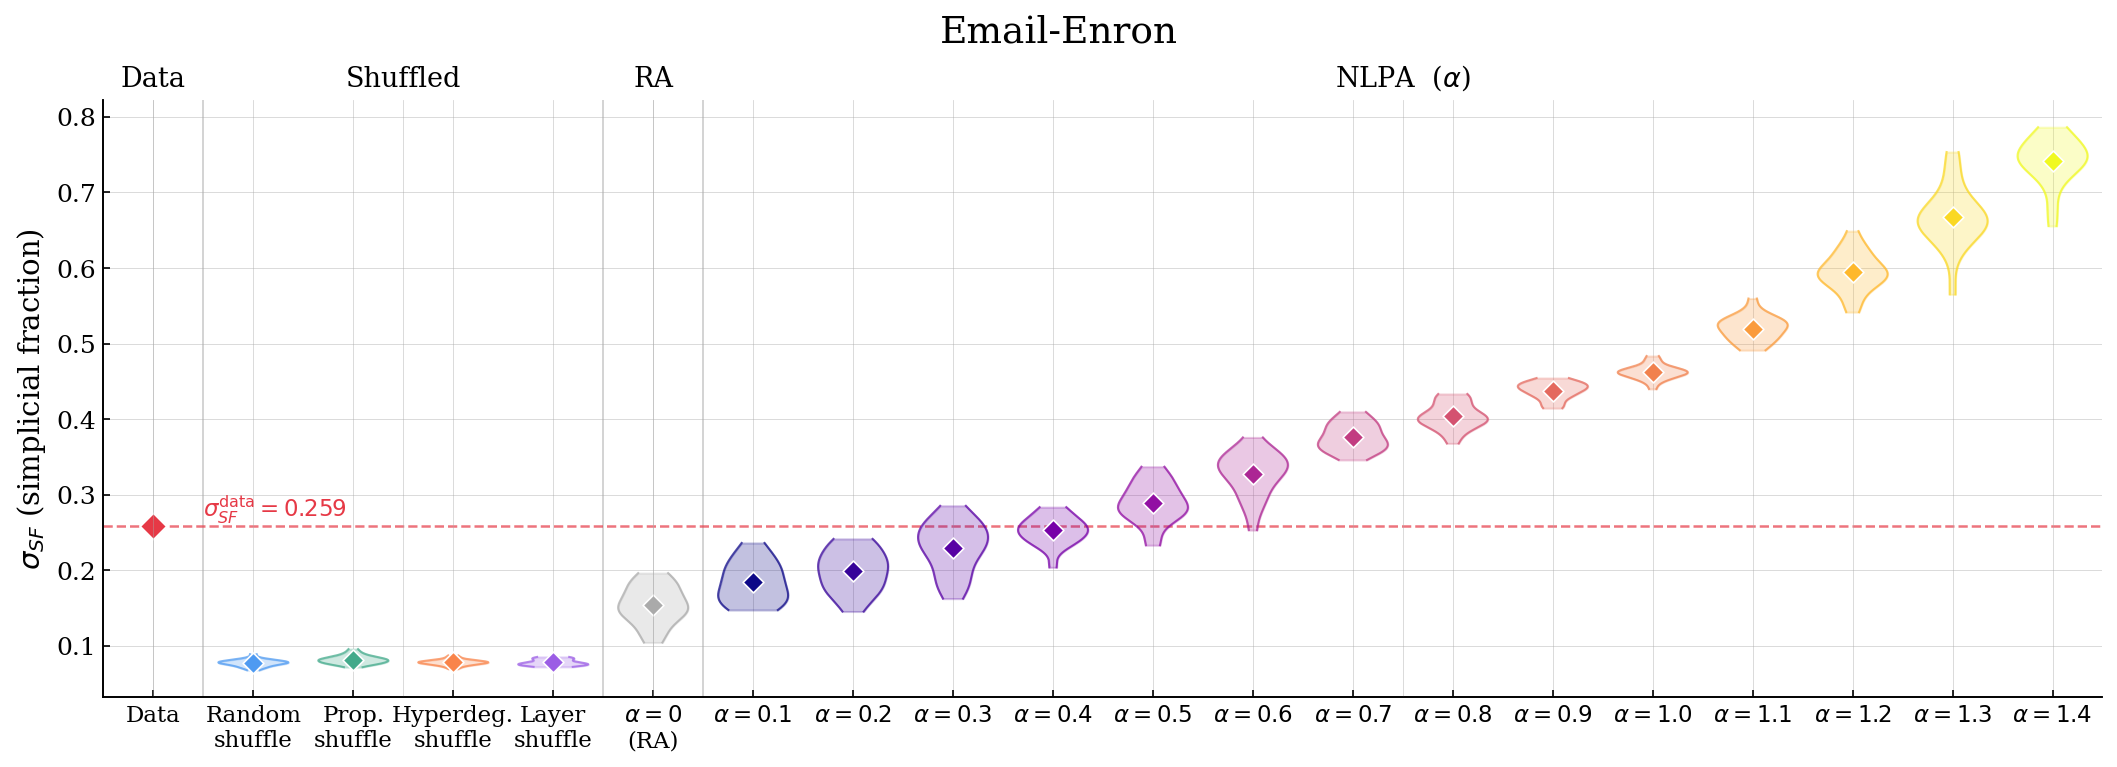

Saved: email-Enron


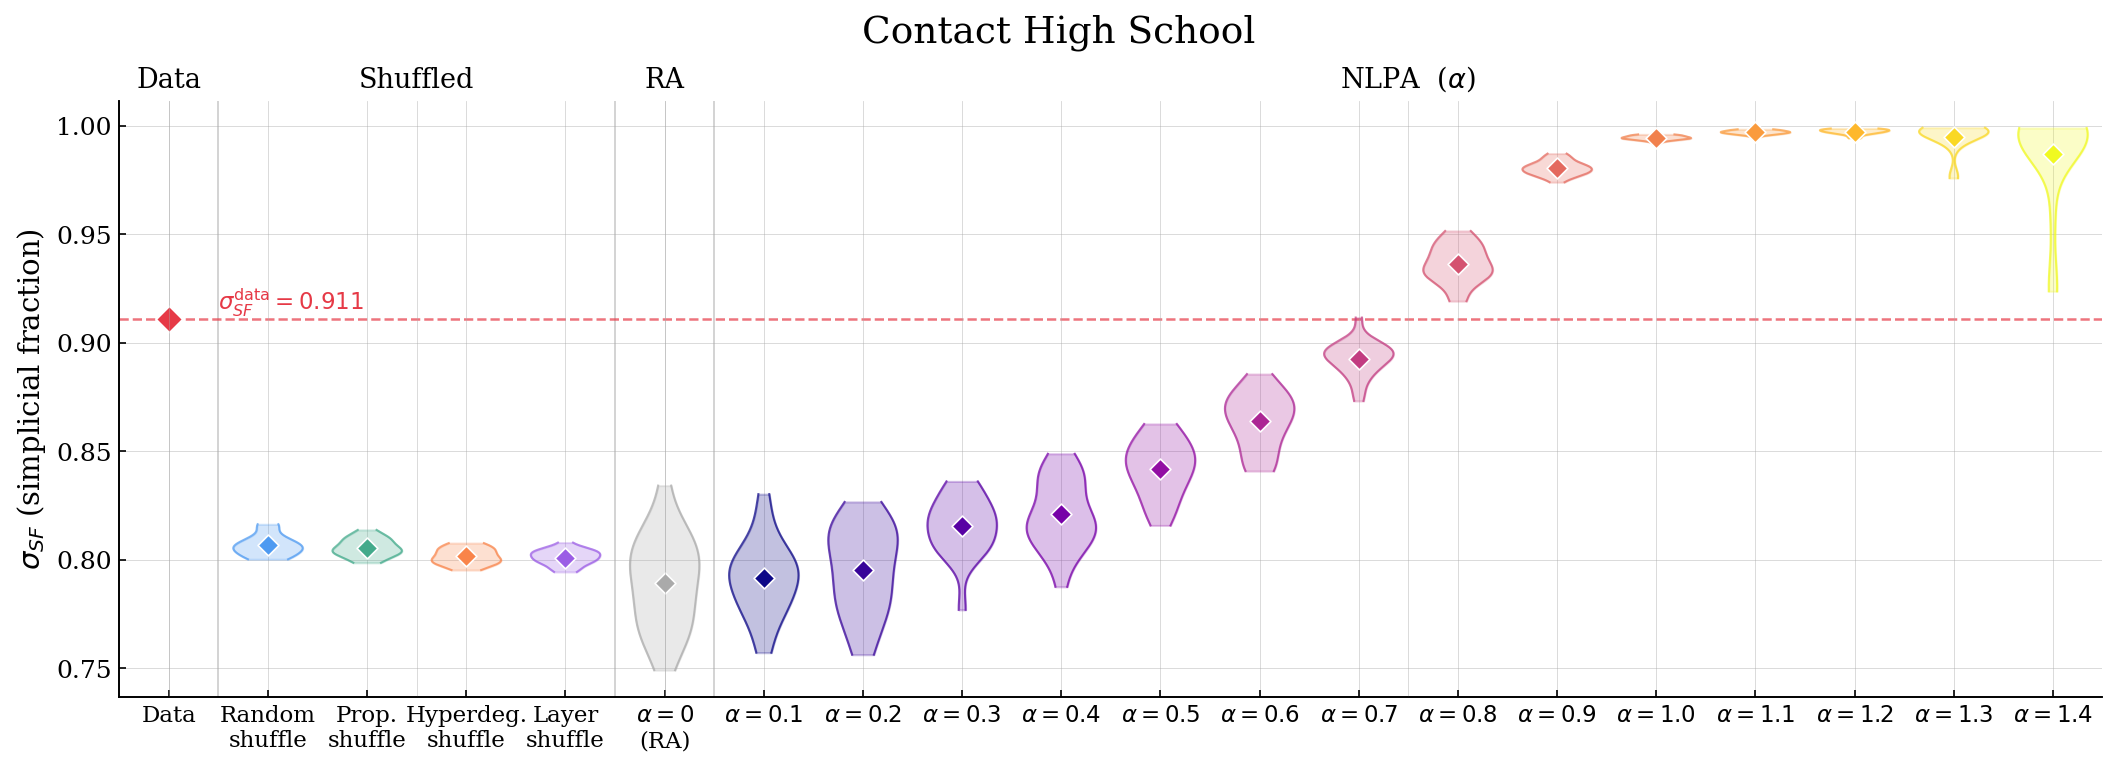

Saved: contact-high-school


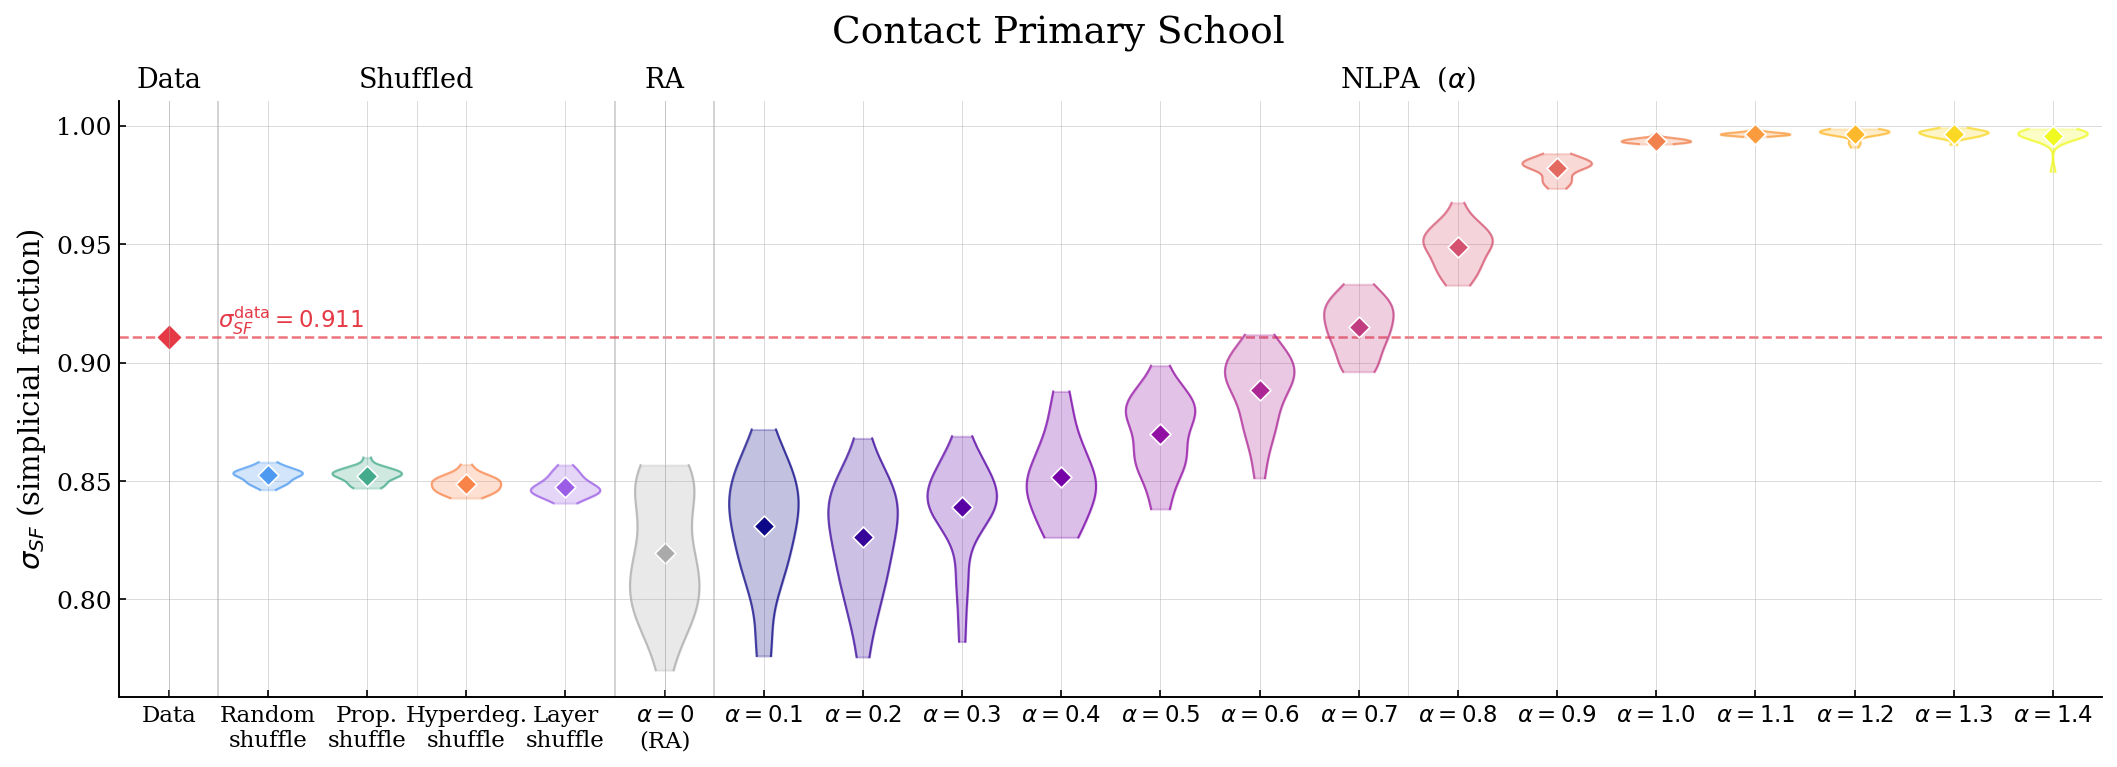

Saved: contact-primary-school


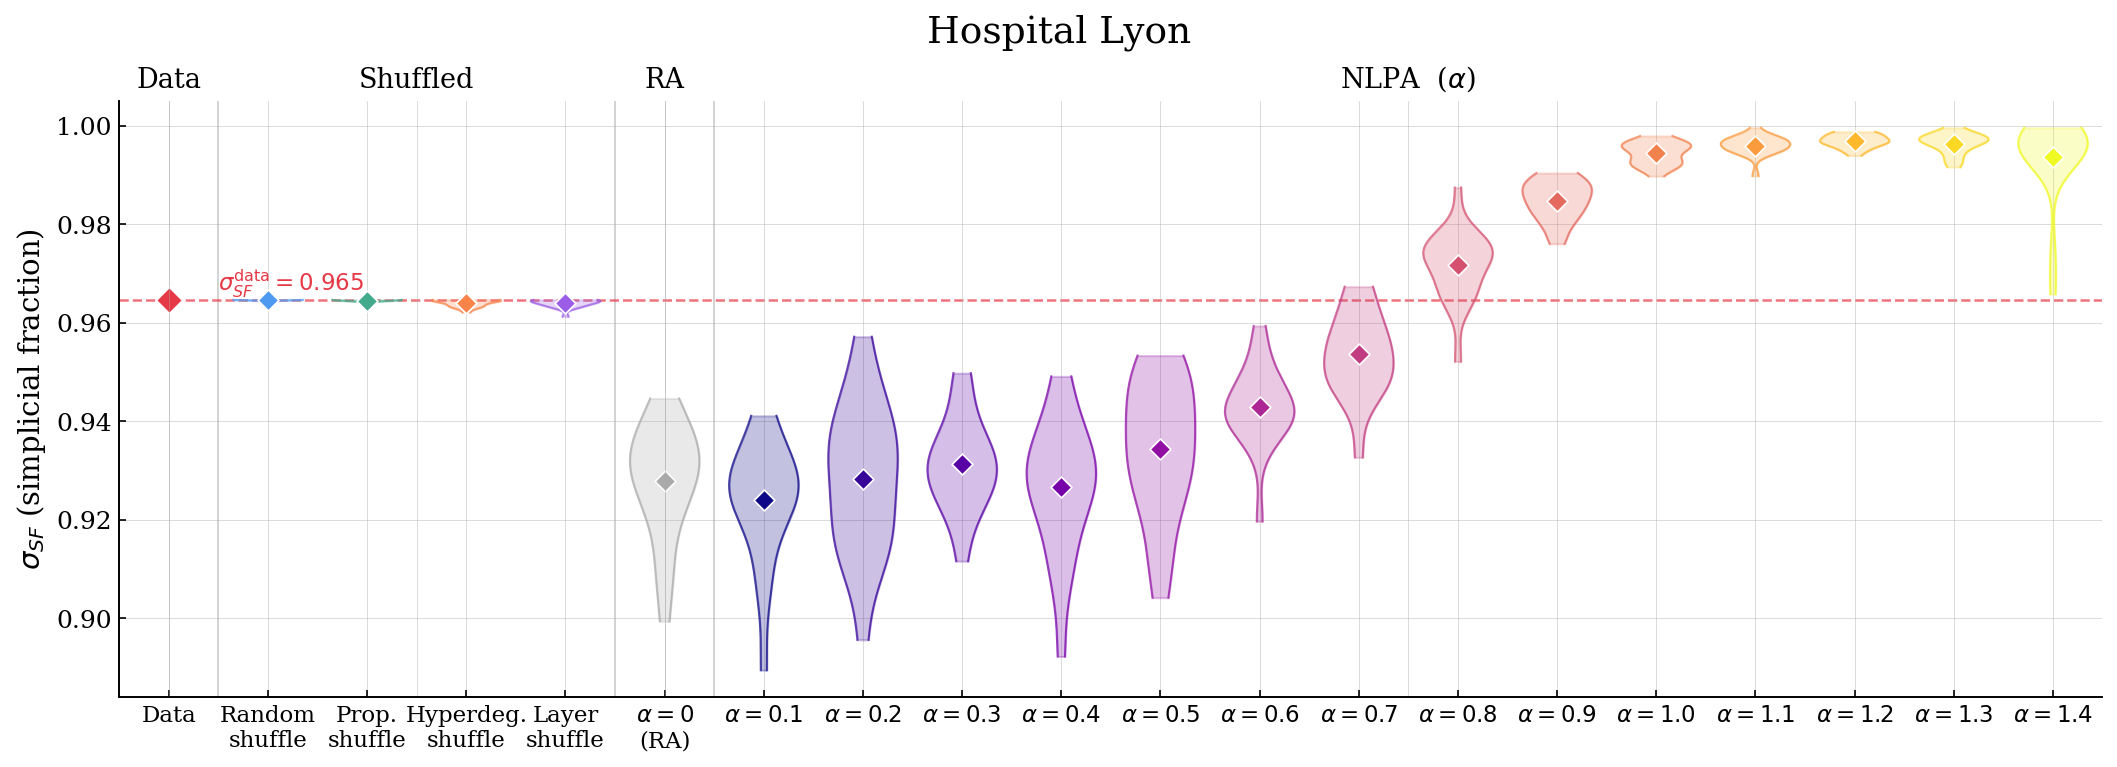

Saved: hospital-lyon


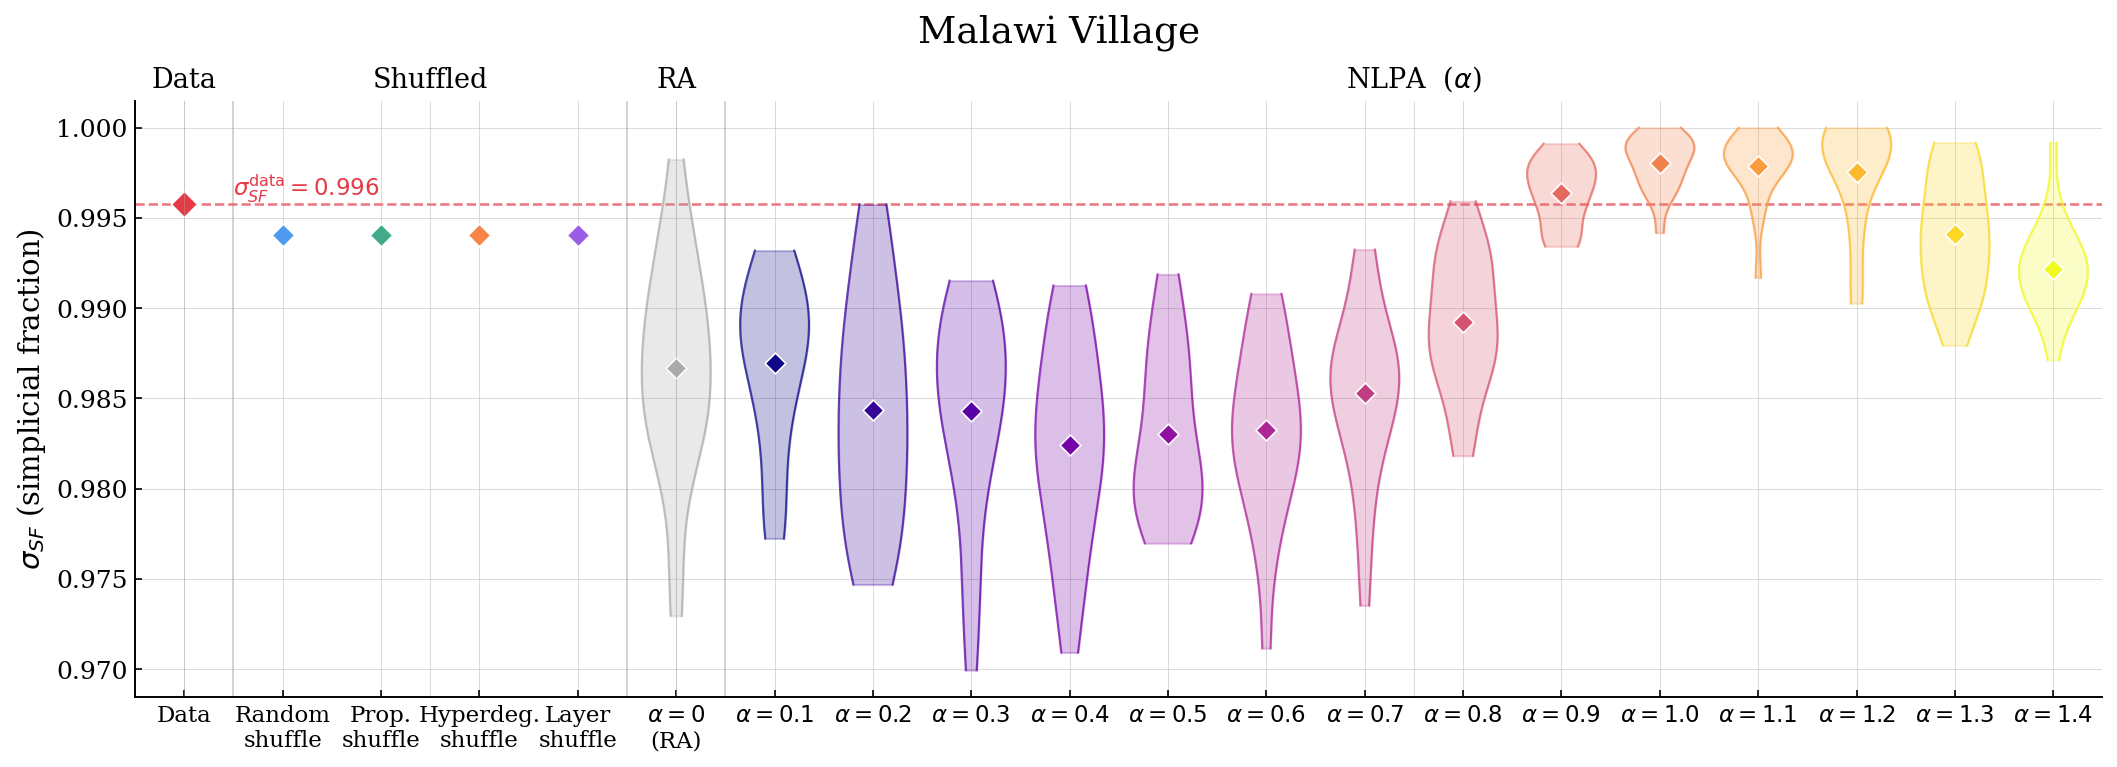

Saved: malawi-village


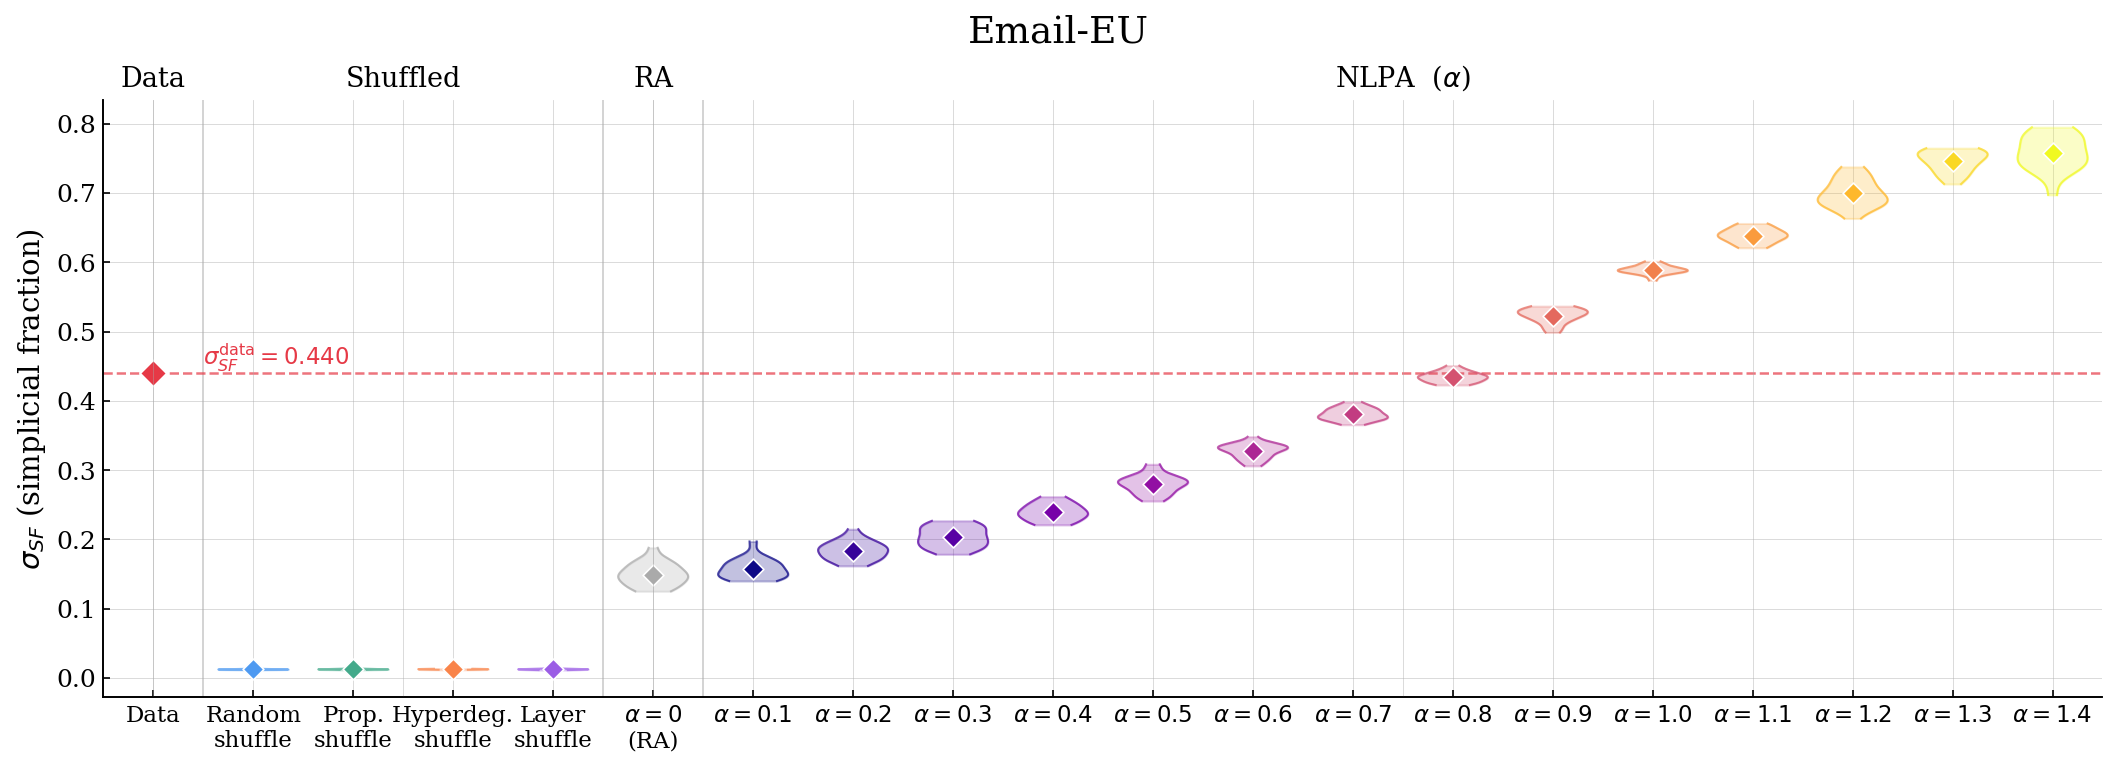

Saved: email-EU


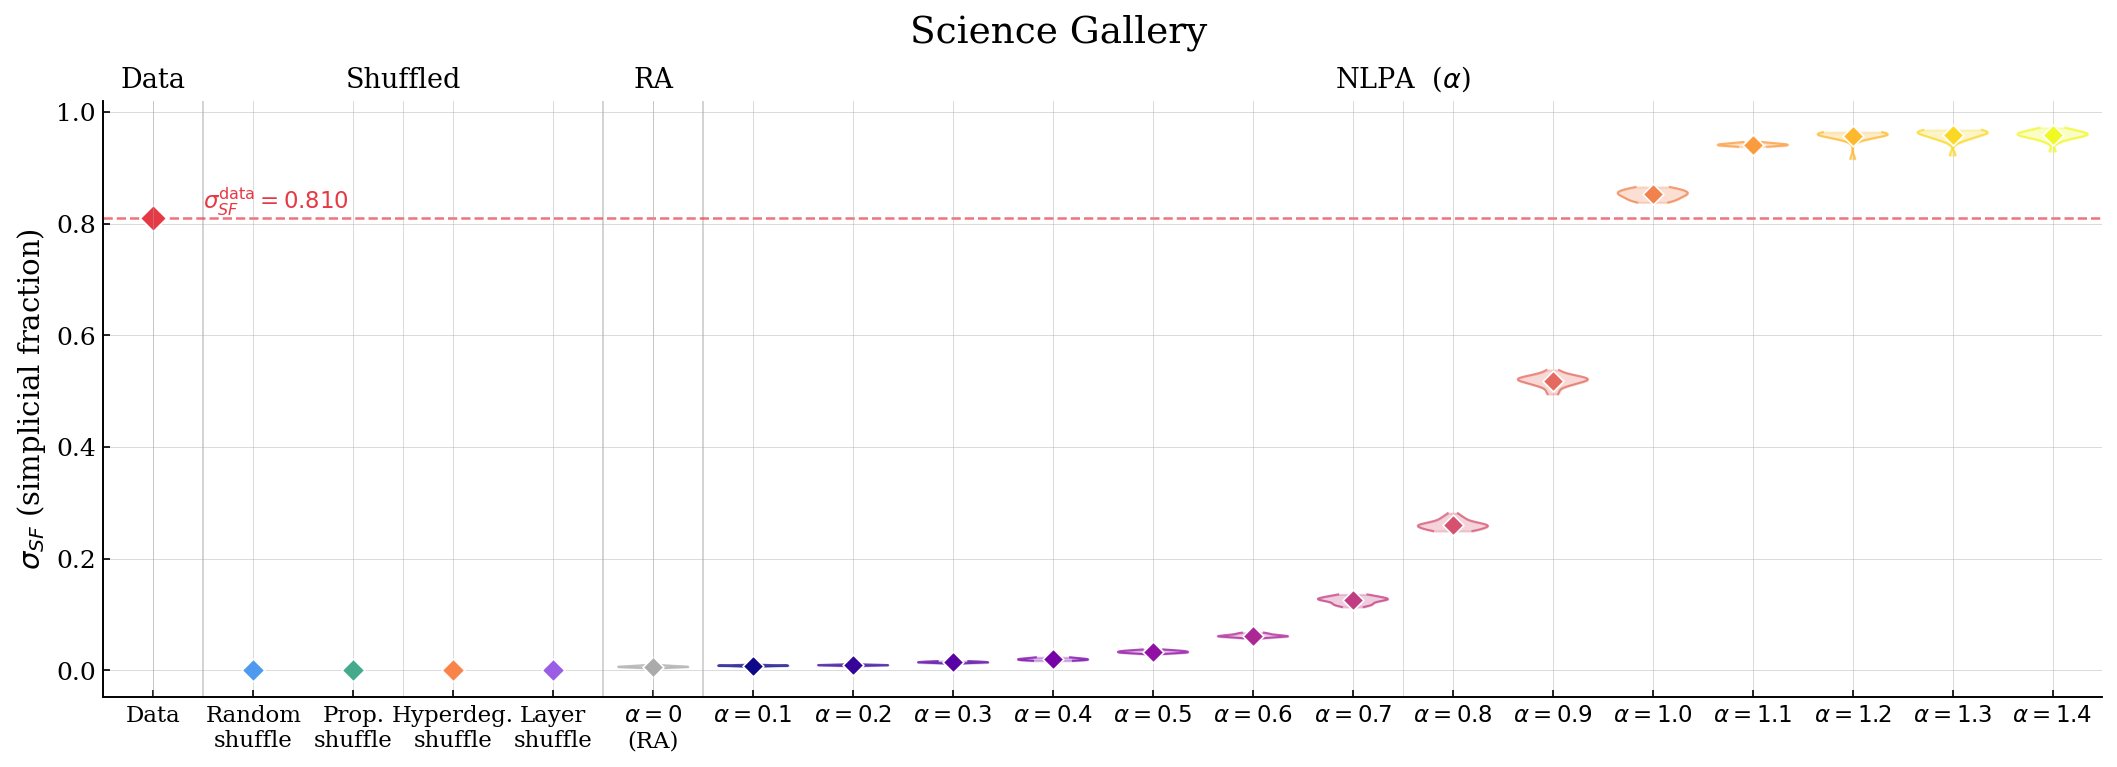

Saved: science-gallery


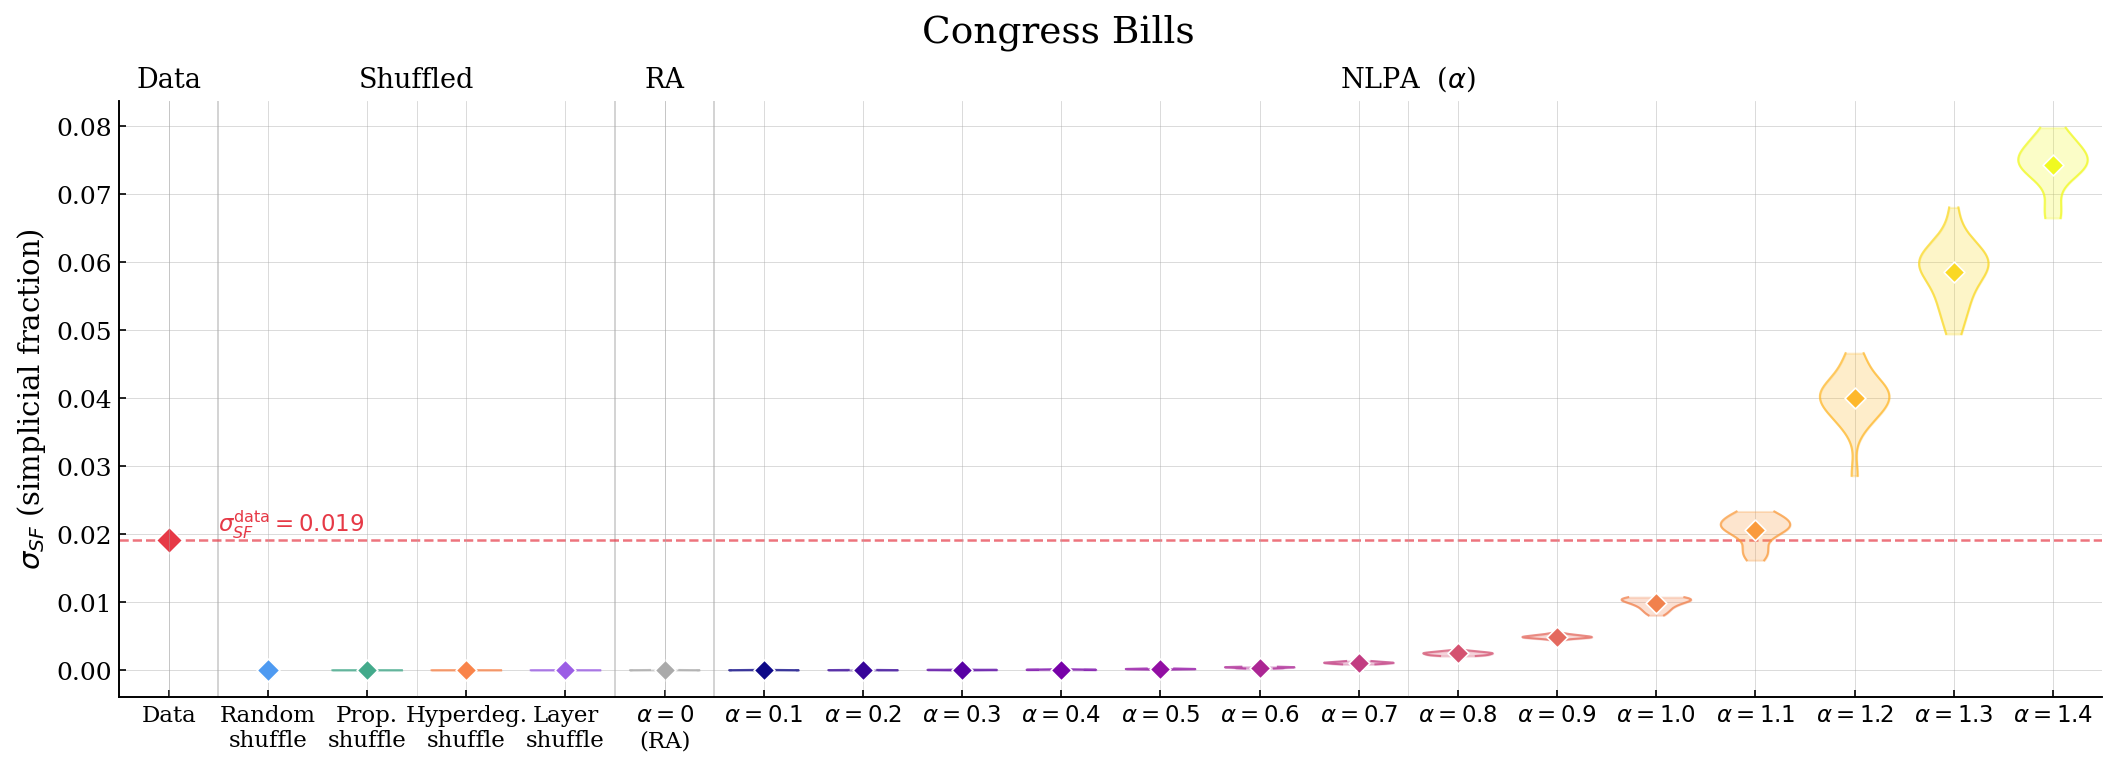

Saved: congress-bills


In [20]:
# ── x-axis layout ─────────────────────────────────────────────────────────────
#   0         : Original data
#   1,2,3,4   : Shuffled (random, proportional, hyperdegree, layer)
#   5         : RA (alpha = 0)
#   6 .. end  : NLPA alphas in order

alphas = list(np.linspace(0.1, 1.4, 14))
n_nl    = len(alphas)
X_ORIG  = 0
X_SHUF  = [1, 2, 3, 4]
X_RA    = 5
X_NL    = list(range(6, 6 + n_nl))
N_TOTAL = 6 + n_nl
names = ['email-Enron', 'contact-high-school', 'contact-primary-school',
          'hospital-lyon', 'malawi-village', 'email-EU', 'science-gallery','congress-bills']
cleaned_names = ['Email-Enron', 'Contact High School', 'Contact Primary School',
          'Hospital Lyon', 'Malawi Village', 'Email-EU', 'Science Gallery','Congress Bills']
shuf_labels = ['Random\nshuffle', 'Prop.\nshuffle',
               'Hyperdeg.\nshuffle', 'Layer\nshuffle']

# ── colours ───────────────────────────────────────────────────────────────────

original_color = '#E63946'
shuf_colors    = ['#4e9af1', '#43aa8b', '#f9844a', '#9b5de5']
ra_color       = '#aaaaaa'
nl_cmap        = cm.get_cmap('plasma', n_nl)
nl_colors      = [nl_cmap(i) for i in range(n_nl)]

# ── tick positions and labels ─────────────────────────────────────────────────

def make_xticks():
    positions = [X_ORIG] + X_SHUF + [X_RA] + X_NL
    labels    = (
        ['Data'] +
        shuf_labels +
        [r'$\alpha=0$' + '\n(RA)'] +
        [rf'$\alpha={a:.1f}$' for a in alphas]
    )
    return positions, labels

# ── per-name figures ──────────────────────────────────────────────────────────

for i, name in enumerate(names):
    fig, ax = plt.subplots(figsize=(14, 5), constrained_layout=True)

    orig_val = original_SF.get(name, None)

    # ── horizontal reference line with right-edge label ───────────────────────
    if orig_val is not None:
        ax.axhline(orig_val, color=original_color, lw=1.2, ls='--',
                   alpha=0.7, zorder=1)
        ax.text(X_ORIG + 0.5, orig_val,
        rf'$\sigma_{{SF}}^{{\mathrm{{data}}}} = {orig_val:.3f}$',
        color=original_color, fontsize=11, va='bottom', ha='left',
        zorder=6)

    # ── original data point ───────────────────────────────────────────────────
    if orig_val is not None:
        ax.scatter(X_ORIG, orig_val, color=original_color, s=80,
                   marker='D', edgecolors='white', linewidths=0.8, zorder=5)

    # ── shuffled ──────────────────────────────────────────────────────────────
    shuf_dicts = [random_shuffled_SF, proportional_shuffled_SF,
                  hyperdegree_shuffled_SF, layer_shuffled_SF]
    for x, sdict, color in zip(X_SHUF, shuf_dicts, shuf_colors):
        violin(ax, x, sdict.get(name, []), color)

    # ── RA (alpha = 0) ────────────────────────────────────────────────────────
    violin(ax, X_RA, RA_fromdata_SF.get(name, []), ra_color)

    # ── NLPA (all alphas) ─────────────────────────────────────────────────────
    for x, alpha, color in zip(X_NL, alphas, nl_colors):
        violin(ax, x, nonlinear_SF.get((name, alpha), []), color)

    # ── vertical group separators ─────────────────────────────────────────────
    for sep in [0.5, 4.5, 5.5]:
        ax.axvline(sep, color='#cccccc', lw=0.8, ls='-', zorder=0)

    # ── axes formatting ───────────────────────────────────────────────────────
    tick_pos, tick_lab = make_xticks()
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lab, fontsize=11, rotation=0, ha='center')
    ax.set_xlim(-0.5, N_TOTAL - 0.5)
    ax.set_ylabel(r'$\sigma_{SF}$ (simplicial fraction)')

    # group labels on top axis
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([X_ORIG, np.mean(X_SHUF), X_RA, np.mean(X_NL)])
    ax2.set_xticklabels(['Data', 'Shuffled', 'RA', r'NLPA  ($\alpha$)'],
                        fontsize=13)
    ax2.tick_params(length=0)
    ax2.spines['top'].set_visible(False)

    clean = cleaned_names[i]#name.replace('-', ' ').title()
    fig.suptitle(rf'{clean}', fontsize=18)

    fig.savefig(base_path + f'fig_SF_comparison_{name}.pdf',
                dpi=300, bbox_inches='tight')
    fig.savefig(base_path + f'fig_SF_comparison_{name}.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {name}')